#Import Libraries & Data

In [1]:
#import libraries
import pandas as pd
import pandas_gbq
import pydata_google_auth
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

import matplotlib.style as style
style.available
style.use('fivethirtyeight')

##Authenticate

In [2]:
import pandas_gbq
import pydata_google_auth

SCOPES = [
    'https://www.googleapis.com/auth/cloud-platform',
    'https://www.googleapis.com/auth/drive',
]

# get credentials
credentials = pydata_google_auth.get_user_credentials(
    SCOPES,
    auth_local_webserver=False)

In [3]:
# GBQ
sql = """
select *
# from `ffn-dw-bigquery-prd.Dexter.v_aal_early_pay_default`
from `ffam-data-platform-loan-ops.report_views.v_aal_early_pay_default`
where extract(year from loan_vintage_month) >= 2026
"""

# run query
df = pandas_gbq.read_gbq(sql
                         ,project_id='ffn-dw-bigquery-prd'
                         ,credentials=credentials
                         ,dialect='standard'
                        )

Downloading: 100%|██████████|


In [4]:
df.head()

,loan_id,loan_product,loan_consultant_name,loan_detail_1_debt_relief_firm,loan_vintage_month,loan_vintage_quarter,loan_investor,loan_contributing_investor,loan_adr_retail_vs_wholesale,loan_application_NDI_ratio,...,count_dpd_30,days_elapsed_origination_to_dq,days_elapsed_origination_to_dq_30,avg_monthly_draft,cplus_estimated_monthly_payment_amount,monthly_loan_payment_amount,fdr_vs_aal_payment_variance,fdr_vs_aal_payment_variance_percent_change,fdr_vs_aal_payment_variance_percentile,loan_1st_pay_default_return_code
0,CP01671423,AAL,Serena Chiago,FREEDOM DEBT RELIEF,2026-07-01,20263,123-APERTURE2002CPT,None,Retail,0.14,...,0,<NA>,<NA>,524.333333,556.75,556.750000,32.42,0.061831,0.0,None
1,CP01633256,AAL,Ricardo Perez,FREEDOM DEBT RELIEF,2026-04-01,20262,115-YS ACV20251,None,Retail,0.54,...,0,<NA>,<NA>,187.540984,216.67,216.670000,29.13,0.155326,1.0,None
2,CP01877470,AAL,Justin Svendsen,FREEDOM DEBT RELIEF,2026-06-01,20262,80-CFTRUST,None,Retail,0.01,...,0,<NA>,<NA>,221.000000,316.20,316.200000,95.20,0.430769,4.0,None
3,CP01809465,AAL,Justin Svendsen,FREEDOM DEBT RELIEF,2026-06-01,20262,108-WLTR,None,Retail,0.48,...,0,29,<NA>,184.166667,183.00,177.395433,-1.17,-0.006353,0.0,None
4,CP0991167,AAL,Jason Tellekson,FREEDOM DEBT RELIEF,2026-04-01,20262,108-WLTR,None,Retail,0.15,...,0,10,<NA>,572.000000,680.33,680.330000,108.33,0.189388,1.0,None


In [5]:
# Get high-level statistics of the DataFrame
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
loan_application_NDI_ratio,18698.0,0.286242,0.155124,0.0,0.18,0.28,0.38,0.72
loan_application_PTI_ratio,18698.0,0.097145,0.051966,0.0,0.06,0.09,0.12,0.3
loan_origination_loan_amount,18698.0,17601.649564,11750.435314,1596.68,9367.08,14244.27,22246.0925,78099.8
loan_origination_interest_rate,18698.0,0.24717,0.013355,0.239,0.239,0.239,0.269,0.269
loan_origination_term_in_months,18698.0,49.192748,13.010356,23.0,41.0,52.0,58.0,72.0
loan_origination_ach_active_flag,18698.0,0.980105,0.139644,0.0,1.0,1.0,1.0,1.0
loan_prepaid_flag,18698.0,0.036474,0.187473,0.0,0.0,0.0,0.0,1.0
loan_chargeoff_flag,18698.0,0.004065,0.063626,0.0,0.0,0.0,0.0,1.0
loan_no_payment_straight_to_chargeoff_flag,18698.0,0.000856,0.029241,0.0,0.0,0.0,0.0,1.0
loan_contractual_chargeoff_flag,18698.0,0.003797,0.061506,0.0,0.0,0.0,0.0,1.0


In [6]:
display(df.mode().T)

,0,1
loan_id,CP01574598,CP01772410
loan_product,AAL,NaN
loan_consultant_name,Derick Land,NaN
loan_detail_1_debt_relief_firm,FREEDOM DEBT RELIEF,NaN
loan_vintage_month,2026-07-01,NaT
...,...,...
monthly_loan_payment_amount,433.33,NaN
fdr_vs_aal_payment_variance,0.0,NaN
fdr_vs_aal_payment_variance_percent_change,0.0,NaN
fdr_vs_aal_payment_variance_percentile,0.0,NaN


In [7]:
# Calculate and display null counts per column
null_counts = df.isnull().sum()
print("Null counts per column:")
display(null_counts)

Null counts per column:


,0
loan_id,0
loan_product,0
loan_consultant_name,0
loan_detail_1_debt_relief_firm,0
loan_vintage_month,0
...,...
monthly_loan_payment_amount,0
fdr_vs_aal_payment_variance,0
fdr_vs_aal_payment_variance_percent_change,39
fdr_vs_aal_payment_variance_percentile,39


#Feature Engineering
##Identify Important features impacting `flag_1st_pay_default`

### Subtask:
Load the data, preprocess it, perform feature selection, train a classification model, and identify the most important features influencing `flag_1st_pay_default`.

**Reasoning**:
To identify the most important features, I will perform the following steps:
1. Load the data from BigQuery.
2. Handle missing values by dropping columns with all nulls and then imputing the remaining ones.
3. Encode categorical features.
4. Select features using a method like SelectKBest.
5. Train a classification model (e.g., RandomForestClassifier) on the preprocessed and selected data.
6. Extract and display the feature importances from the trained model.

Constant columns before feature selection: ['loan_product', 'loan_application_loan_use', 'loan_fraud_flag', 'loan_bk_discharged_flag']
Number of NaNs per column before feature selection:


,0
loan_id,0
loan_product,0
loan_consultant_name,0
loan_detail_1_debt_relief_firm,0
loan_vintage_quarter,0
loan_investor,0
loan_adr_retail_vs_wholesale,0
loan_application_NDI_ratio,0
loan_application_PTI_ratio,0
loan_application_utm_lead_source,0


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 1 11 23 25] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Sorted Feature Importances (including specified categorical features and excluding others):


,0
fdr_vs_aal_payment_variance,4.147103e-02
days_elapsed_negotiation,3.793531e-02
loan_application_NDI_ratio,3.714447e-02
day_variance_1st_billing_due_contract_vs_actual,3.570723e-02
loan_application_PTI_ratio,2.903291e-02
fdr_vs_aal_payment_variance_percentile,2.485912e-02
borrower_origination_risk_group,2.059019e-02
loan_application_utm_lead_channel,1.937367e-02
loan_origination_principal_period,1.876882e-02
loan_origination_first_payment_day_of_week,1.854278e-02


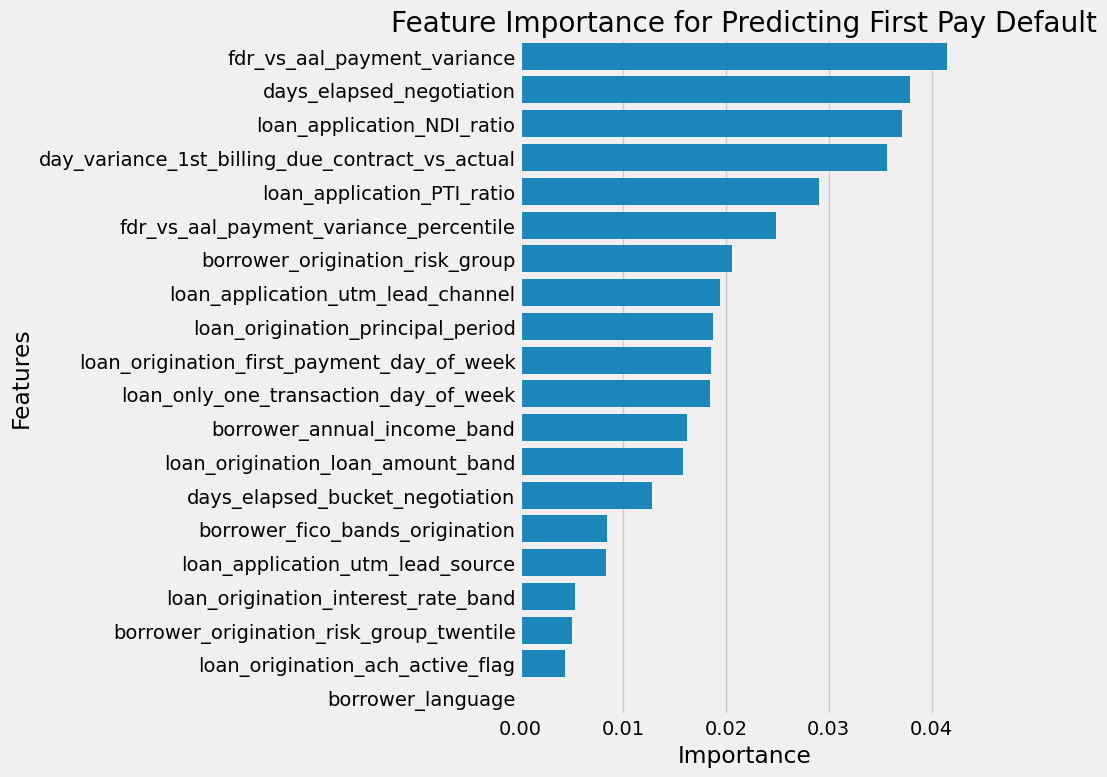

In [8]:
# Data Preprocessing
# Separate target variable
X = df.drop('flag_1st_pay_default', axis=1)
y = df['flag_1st_pay_default']

# Drop columns with all missing values
X.dropna(axis=1, how='all', inplace=True)

# Identify categorical and numerical columns after dropping
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Impute missing values (using mean for numerical and most frequent for categorical)
numerical_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = categorical_imputer.fit_transform(X[categorical_cols])


# Encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Drop date and dbdate columns before feature selection
date_cols = X.select_dtypes(include=['datetime64[ns]', 'dbdate']).columns
X = X.drop(columns=date_cols)

# Check for constant columns before feature selection
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
print(f"Constant columns before feature selection: {constant_cols}")

# Check for remaining NaNs before feature selection
print("Number of NaNs per column before feature selection:")
display(X.isnull().sum())

# Define the list of categorical features to explicitly include
categorical_features_to_include = [
    'loan_origination_loan_amount_band'
    , 'loan_origination_interest_rate_band'
    , 'loan_origination_principal_period'
    , 'borrower_language'
    , 'borrower_fico_bands_origination'
    , 'borrower_annual_income_band'
    , 'borrower_origination_risk_group_twentile'
    , 'borrower_origination_state'
    , 'loan_origination_first_payment_day_of_week'
    , 'days_elapsed_bucket_negotiation'
    , 'loan_application_NDI_ratio'
    , 'loan_application_PTI_ratio'
    , 'loan_application_utm_lead_source'
    , 'loan_application_utm_lead_channel'
    , 'loan_origination_interest_rate_band'
    , 'loan_origination_principal_period'
    , 'borrower_language'
    , 'borrower_fico_bands_origination'
    , 'borrower_annual_income_band'
    , 'fdr_vs_aal_payment_variance_percentile'
    , 'fdr_vs_aal_payment_variance'
]


# Feature Selection (SelectKBest)
# Using f_classif for classification tasks
selector = SelectKBest(score_func=f_classif, k=20) # Select top 20 features
X_selected_kbest = selector.fit_transform(X, y)

# Get the names of selected features from SelectKBest
selected_kbest_feature_names = X.columns[selector.get_support(indices=True)]

# Combine SelectKBest features with the specified categorical features
# Ensure no duplicates and that all specified categorical features are included
all_selected_feature_names = list(selected_kbest_feature_names) + categorical_features_to_include
all_selected_feature_names = list(dict.fromkeys(all_selected_feature_names)) # Remove duplicates while preserving order


# Filter X to include only the combined set of selected features
X_selected = X[all_selected_feature_names]


# Model Selection and Training (RandomForestClassifier)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_selected, y)

# Identify Important Features
feature_importances = model.feature_importances_
feature_importances_series = pd.Series(feature_importances, index=X_selected.columns)
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

# Define columns to remove (including those previously specified by the user)
columns_to_remove = [
    'days_elapsed_origination_to_dq_30',
    'loan_investor',
    'loan_prepaid_flag',
    'loan_contributing_investor',
    'loan_no_payment_straight_to_chargeoff_flag',
    'loan_1st_pay_default_return_code',
    'days_elapsed_origination_to_dq',
    'principal_default_percent',
    'count_dpd_1_to_10',
    'count_dpd_cured',
    'count_dpd_30',
    'loan_chargeoff_flag',
    'loan_contractual_chargeoff_flag',
    'loan_in_debt_settlement_flag',
    'flag_dq',
    'flag_never_pay',
    'borrower_origination_state'
]


# Remove specified columns from feature importances
filtered_feature_importances = sorted_feature_importances.drop(columns_to_remove, errors='ignore')


print("Sorted Feature Importances (including specified categorical features and excluding others):")
display(filtered_feature_importances)

# Optional: Visualize filtered feature importances
plt.figure(figsize=(10, 8)) # Increased figure height for more features
sns.barplot(x=filtered_feature_importances.values, y=filtered_feature_importances.index, orient='h')
plt.title('Feature Importance for Predicting First Pay Default')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Visualize numerical feature default proportions
Visualize the contribution of each feature to the target variable `flag_1st_pay_default`.
## Subtask:
Create plots showing the proportion of defaulting customers within bins of the numerical features.

**Reasoning**:
To visualize the proportion of defaults within bins of numerical features, I will:
1. Identify numerical columns (excluding constant ones).
2. Iterate through each numerical column.
3. Create bins for the numerical feature.
4. Calculate the proportion of defaults within each bin.
5. Plot the default proportions against the bin centers or edges.

Initial numerical columns: ['loan_application_NDI_ratio', 'loan_application_PTI_ratio', 'loan_origination_loan_amount', 'loan_origination_interest_rate', 'loan_origination_term_in_months', 'loan_origination_ach_active_flag', 'loan_prepaid_flag', 'loan_chargeoff_flag', 'loan_no_payment_straight_to_chargeoff_flag', 'loan_contractual_chargeoff_flag', 'loan_fraud_flag', 'loan_deceased_flag', 'loan_bk_discharged_flag', 'loan_in_debt_settlement_flag', 'borrower_origination_risk_group', 'borrower_home_owner_flag', 'co_borrower_flag', 'days_elapsed_negotiation', 'day_variance_1st_billing_due_contract_vs_actual', 'count_dpd_cured', 'flag_dq', 'flag_1st_pay_default', 'flag_never_pay', 'principal_default_percent', 'count_dpd_1_to_10', 'count_dpd_30', 'days_elapsed_origination_to_dq', 'days_elapsed_origination_to_dq_30', 'avg_monthly_draft', 'cplus_estimated_monthly_payment_amount', 'monthly_loan_payment_amount', 'fdr_vs_aal_payment_variance', 'fdr_vs_aal_payment_variance_percent_change', 'fdr_vs_

/tmp/ipykernel_683/735445535.py:79: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df[col].fillna(mean_value, inplace=True)


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.00,2053,10.979784,0.010716
1,1,0.09,1736,9.284415,0.00288
2,2,0.15,2094,11.199059,0.005253
3,3,0.20,1905,10.188255,0.005774
4,4,0.24,2040,10.910258,0.005392
5,5,0.28,1490,7.968767,0.004698
6,6,0.31,2027,10.840732,0.006413
7,7,0.36,1879,10.049203,0.00958
8,8,0.42,1648,8.813777,0.006068
9,9,0.50,1826,9.76575,0.006572


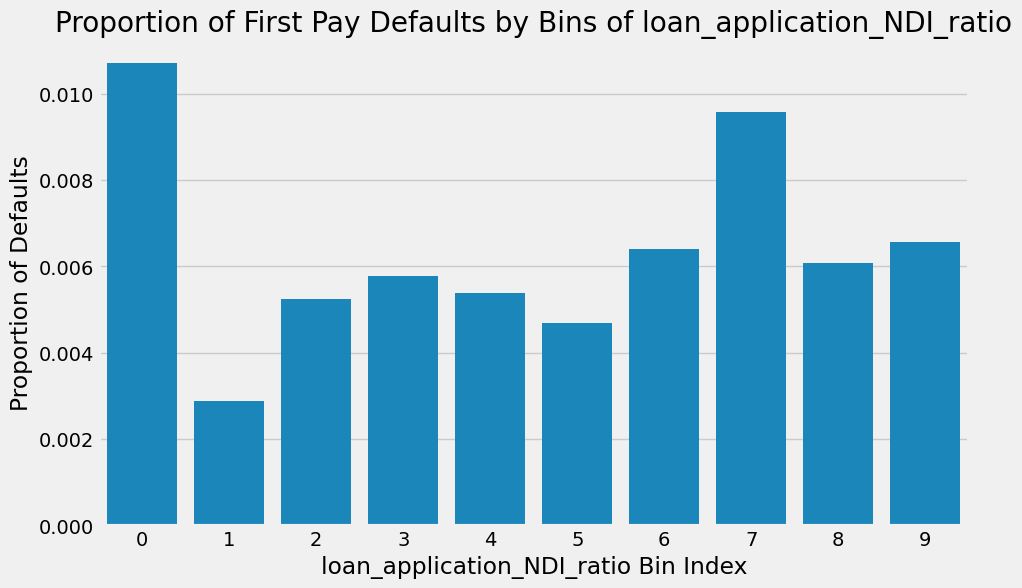

Imputed missing values in 'loan_application_PTI_ratio' with mean (0.10).
Created quantile bins for column 'loan_application_PTI_ratio'.
Bin analysis for loan_application_PTI_ratio:


/tmp/ipykernel_683/735445535.py:79: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df[col].fillna(mean_value, inplace=True)


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.00,2481,13.268799,0.004837
1,1,0.04,1591,8.508931,0.002514
2,2,0.05,1725,9.225586,0.009855
3,3,0.06,1752,9.369986,0.005137
4,4,0.07,3173,16.969729,0.006303
5,5,0.09,1276,6.824259,0.007837
6,6,0.10,1097,5.866938,0.002735
7,7,0.11,2437,13.03348,0.008617
8,8,0.14,1361,7.278853,0.008082
9,9,0.17,1805,9.653439,0.007202


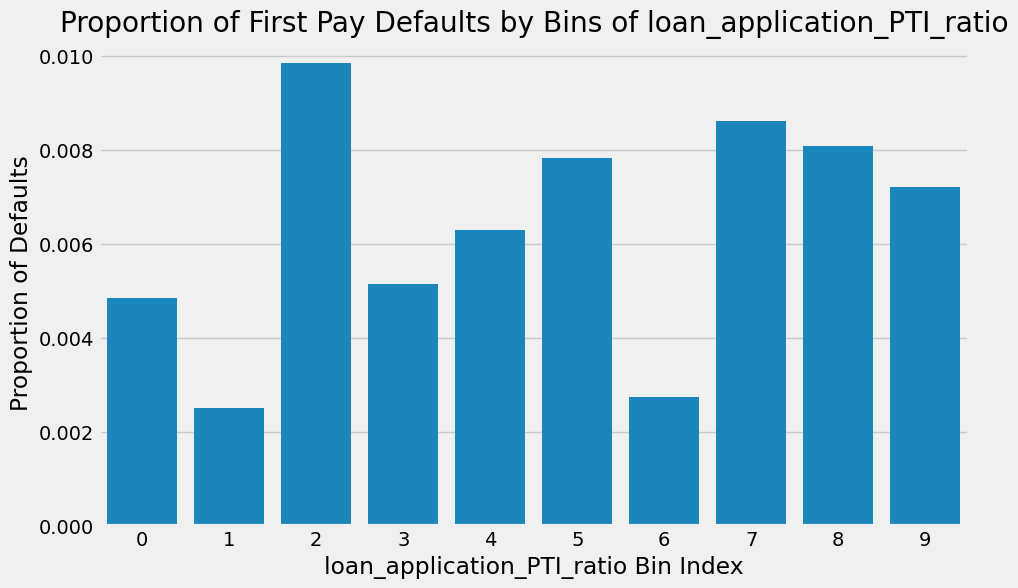

Created quantile bins for column 'loan_origination_loan_amount'.
Bin analysis for loan_origination_loan_amount:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,1596.680,1870,10.00107,0.006952
1,1,6446.139,1870,10.00107,0.009626
2,2,8483.800,1870,10.00107,0.006952
3,3,10271.605,1869,9.995721,0.00321
4,4,12140.818,1870,10.00107,0.006952
5,5,14244.270,1870,10.00107,0.005348
6,6,16723.112,1869,9.995721,0.007491
7,7,19984.435,1870,10.00107,0.005882
8,8,24971.730,1870,10.00107,0.006952
9,9,33713.080,1870,10.00107,0.004813


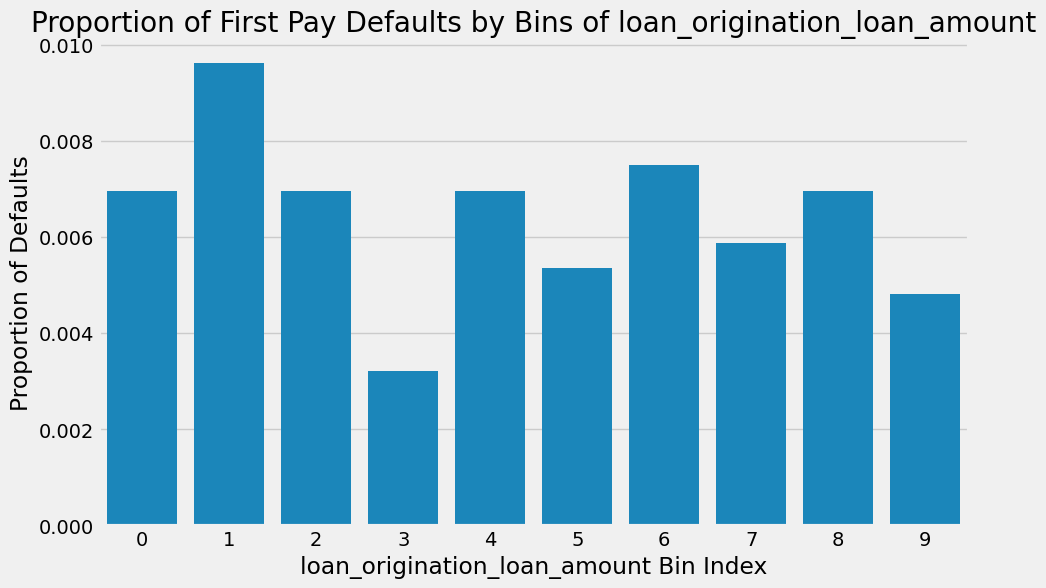

Created quantile bins for column 'loan_origination_interest_rate'.
Bin analysis for loan_origination_interest_rate:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.239,18698,100.0,0.006418


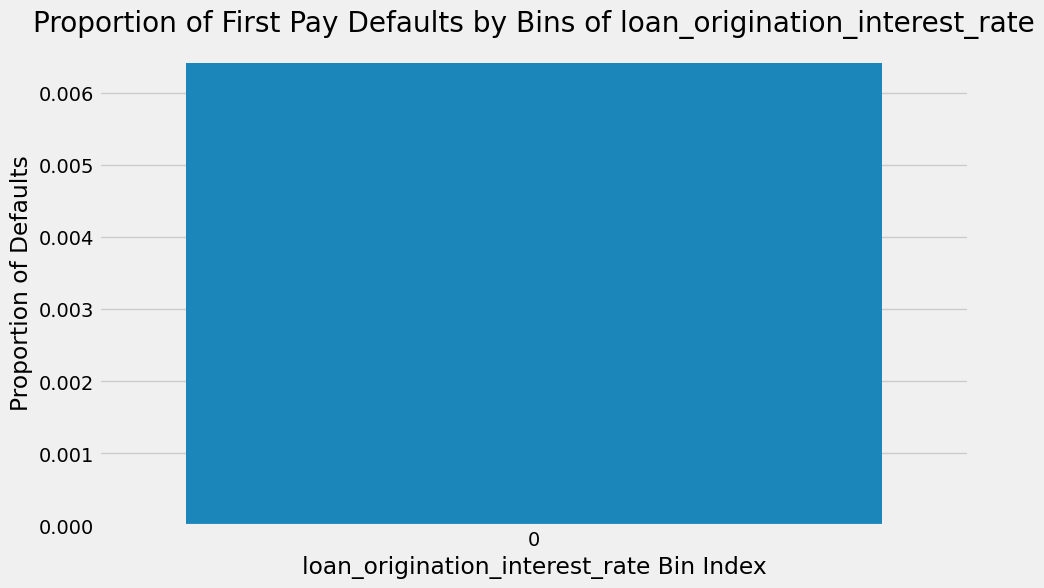

Created quantile bins for column 'loan_origination_term_in_months'.
Bin analysis for loan_origination_term_in_months:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,23.0,2018,10.792598,0.005451
1,1,27.0,1808,9.669483,0.006637
2,2,36.0,2025,10.830035,0.005432
3,3,45.0,1810,9.68018,0.003867
4,4,49.0,2124,11.359504,0.006591
5,5,52.0,1445,7.728099,0.006228
6,6,54.0,3481,18.616964,0.010055
7,7,58.0,664,3.551182,0.00753
8,8,59.0,1613,8.626591,0.00372
9,9,64.0,1710,9.145363,0.005848


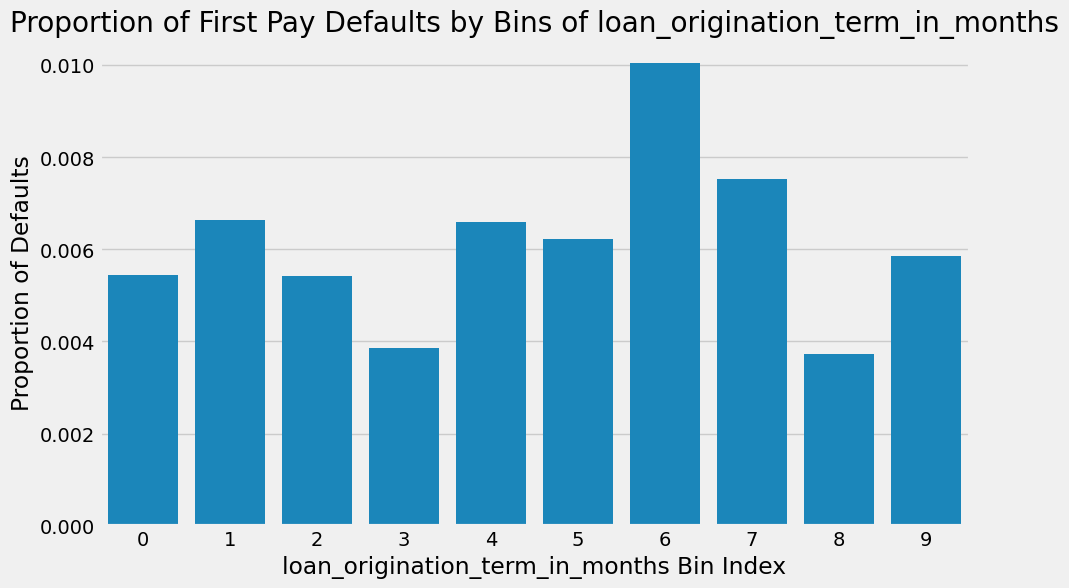

Created quantile bins for column 'loan_origination_ach_active_flag'.
Bin analysis for loan_origination_ach_active_flag:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.0,18698,100.0,0.006418


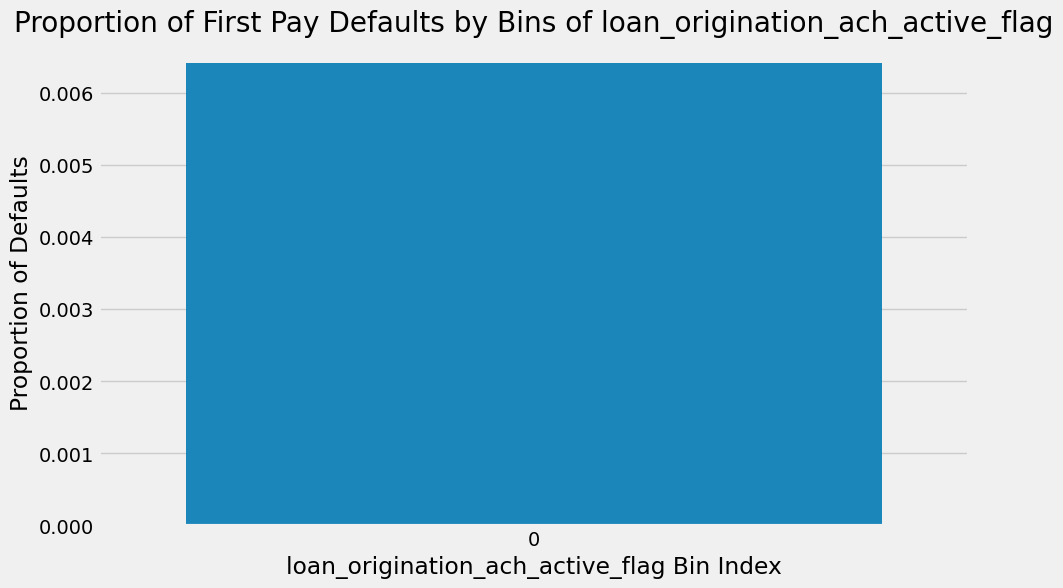

Created quantile bins for column 'borrower_origination_risk_group'.
Bin analysis for borrower_origination_risk_group:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,1.0,5038,26.944058,0.002382
1,1,3.0,1521,8.13456,0.009862
2,2,4.0,1276,6.824259,0.005486
3,3,5.0,2482,13.274147,0.004835
4,4,7.0,1416,7.573002,0.008475
5,5,8.0,2578,13.787571,0.010473
6,6,10.0,1399,7.482084,0.004289
7,7,11.0,2052,10.974436,0.009259
8,8,13.0,936,5.005883,0.010684


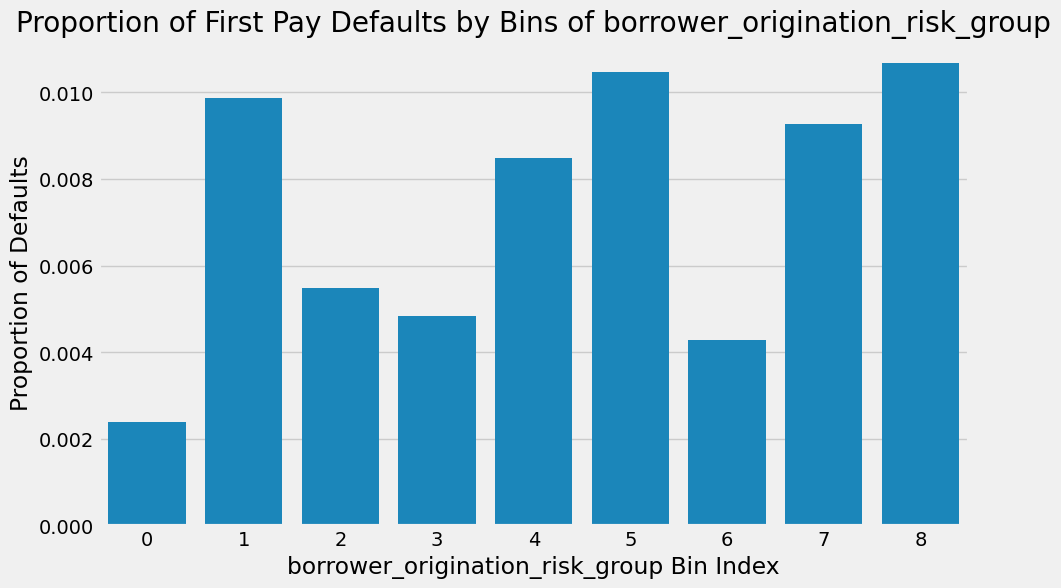

Created quantile bins for column 'borrower_home_owner_flag'.
Bin analysis for borrower_home_owner_flag:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.0,18698,100.0,0.006418


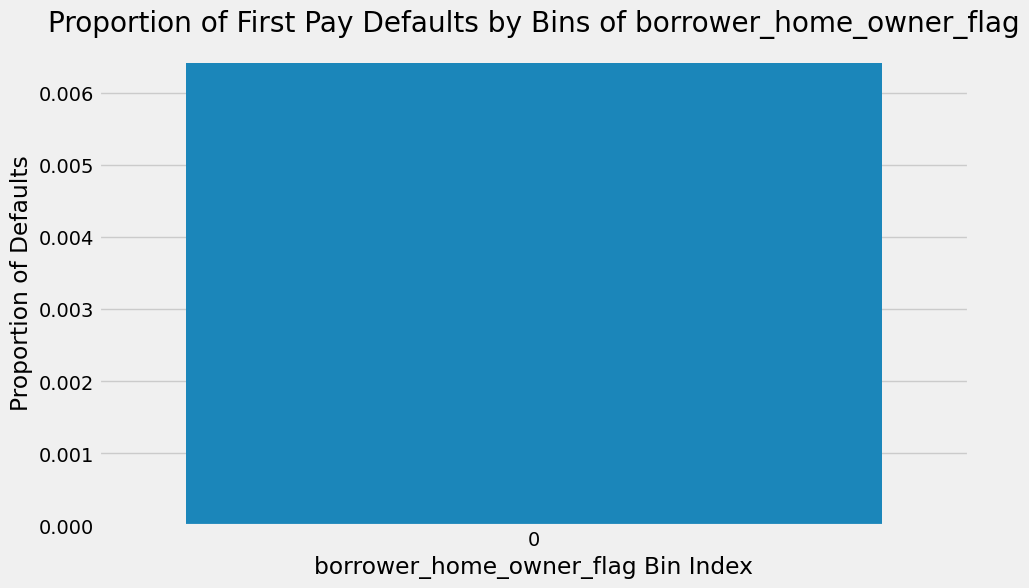

Created quantile bins for column 'co_borrower_flag'.
Bin analysis for co_borrower_flag:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.0,18698,100.0,0.006418


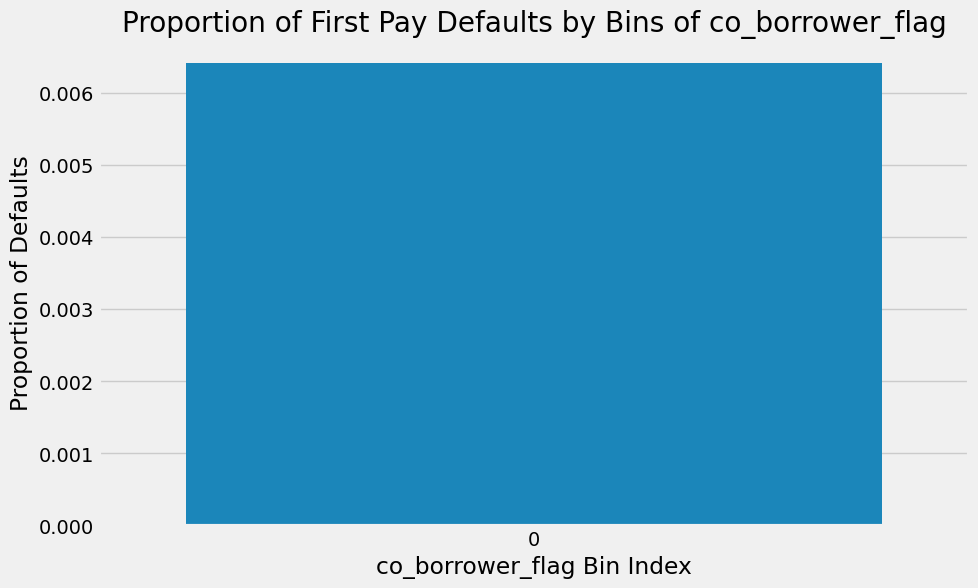

Created quantile bins for column 'days_elapsed_negotiation'.
Bin analysis for days_elapsed_negotiation:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,2.0,2102,11.241844,0.004757
1,1,22.0,1728,9.24163,0.007523
2,2,26.0,1829,9.781795,0.006561
3,3,29.0,2073,11.086747,0.003859
4,4,34.0,1659,8.872607,0.003617
5,5,38.0,2053,10.979784,0.006332
6,6,45.0,1738,9.295112,0.005178
7,7,53.0,1817,9.717617,0.005504
8,8,64.0,1911,10.220344,0.006279
9,9,84.0,1788,9.56252,0.015101


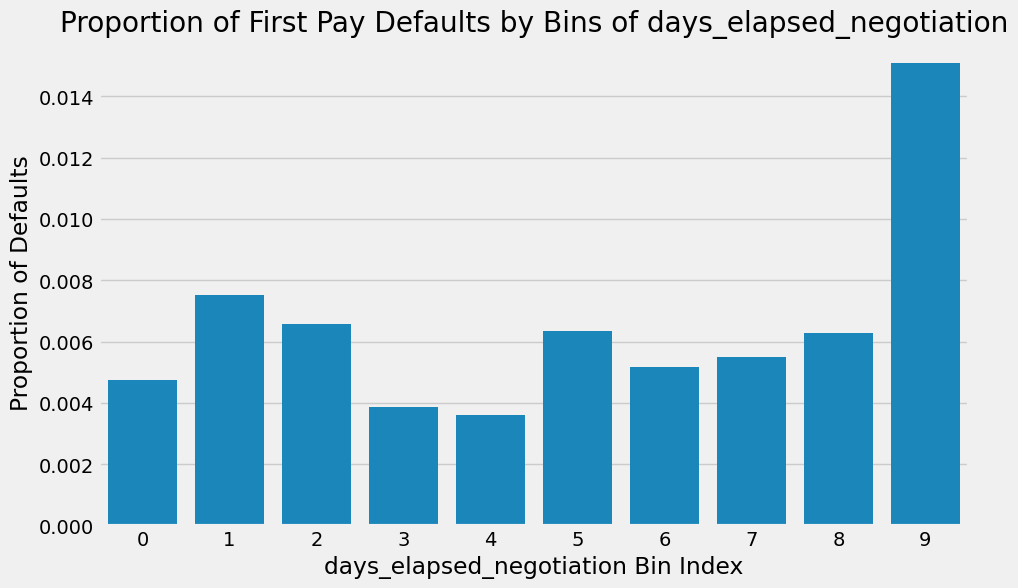

Created quantile bins for column 'day_variance_1st_billing_due_contract_vs_actual'.
Bin analysis for day_variance_1st_billing_due_contract_vs_actual:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,-379.0,2353,12.66961,0.0119
1,1,-31.0,2311,12.443463,0.005625
2,2,-14.0,4920,26.491493,0.004472
3,3,0.0,2761,14.866466,0.002173
4,4,14.0,3004,16.174887,0.003995
5,5,28.0,1382,7.441309,0.004342
6,6,30.0,1841,9.912772,0.002716


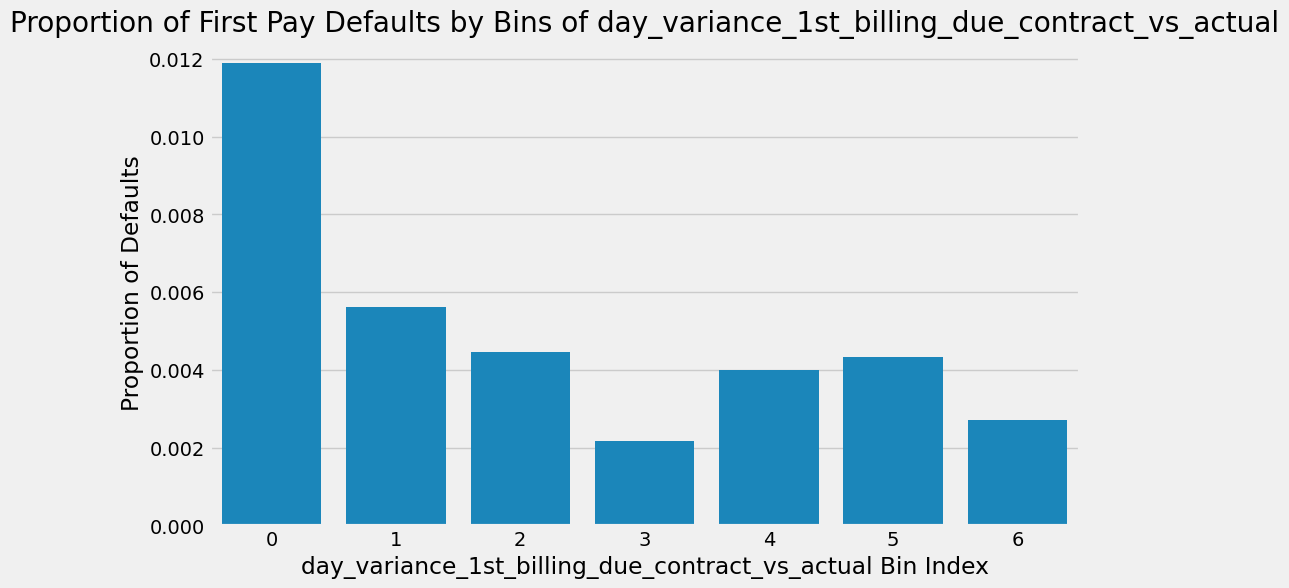

Created quantile bins for column 'avg_monthly_draft'.
Bin analysis for avg_monthly_draft:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,110.000000,1883,10.091645,0.01009
1,1,221.000000,1887,10.113082,0.007949
2,2,270.000000,1831,9.812959,0.008192
3,3,314.166667,1942,10.407846,0.006694
4,4,364.000000,1814,9.72185,0.006064
5,5,418.166667,1864,9.989817,0.004828
6,6,480.000000,1845,9.88799,0.005962
7,7,552.500000,1861,9.973739,0.003761
8,8,673.598907,1869,10.016614,0.005886
9,9,900.000000,1863,9.984458,0.004831


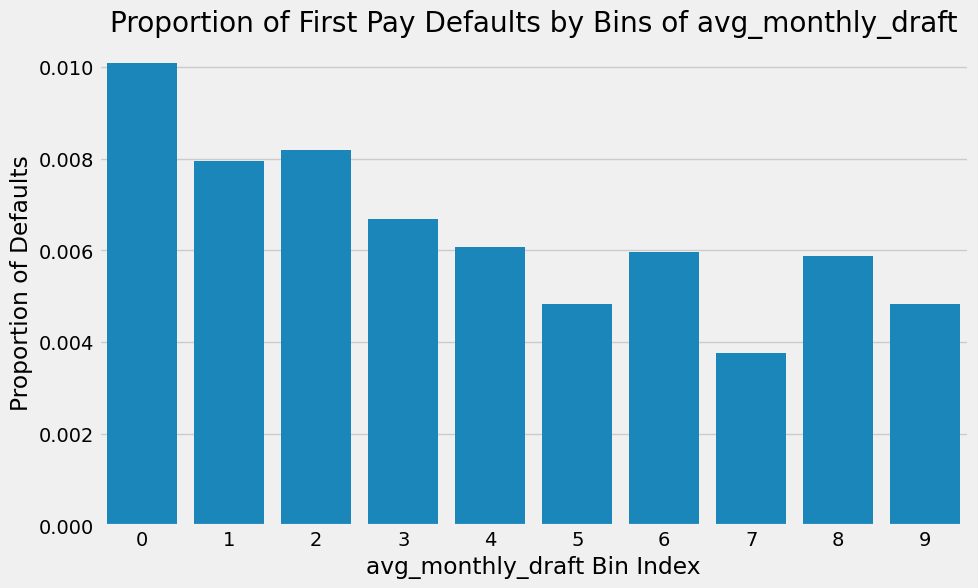

Created quantile bins for column 'cplus_estimated_monthly_payment_amount'.
Bin analysis for cplus_estimated_monthly_payment_amount:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,80.060,1870,10.00107,0.007487
1,1,246.051,1870,10.00107,0.008556
2,2,305.788,1870,10.00107,0.007487
3,3,362.001,1869,9.995721,0.004815
4,4,422.524,1871,10.006418,0.004276
5,5,488.000,1871,10.006418,0.008552
6,6,563.330,1867,9.985025,0.005356
7,7,670.054,1870,10.00107,0.005348
8,8,825.666,1870,10.00107,0.006417
9,9,1100.409,1870,10.00107,0.005882


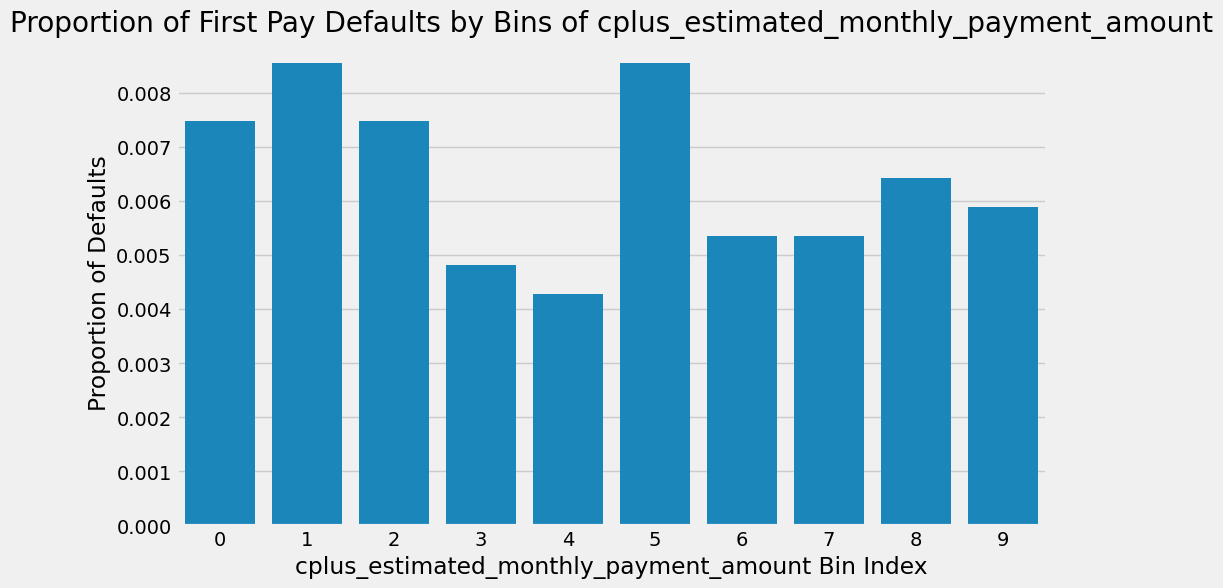

Created quantile bins for column 'monthly_loan_payment_amount'.
Bin analysis for monthly_loan_payment_amount:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,45.570754,1870,10.00107,0.008556
1,1,235.041734,1870,10.00107,0.009091
2,2,296.234755,1870,10.00107,0.003743
3,3,351.722000,1869,9.995721,0.008026
4,4,410.223112,1870,10.00107,0.004278
5,5,475.865000,1871,10.006418,0.007483
6,6,552.700000,1869,9.995721,0.006421
7,7,658.670000,1869,9.995721,0.00428
8,8,810.246000,1874,10.022462,0.007471
9,9,1083.330000,1866,9.979677,0.004823


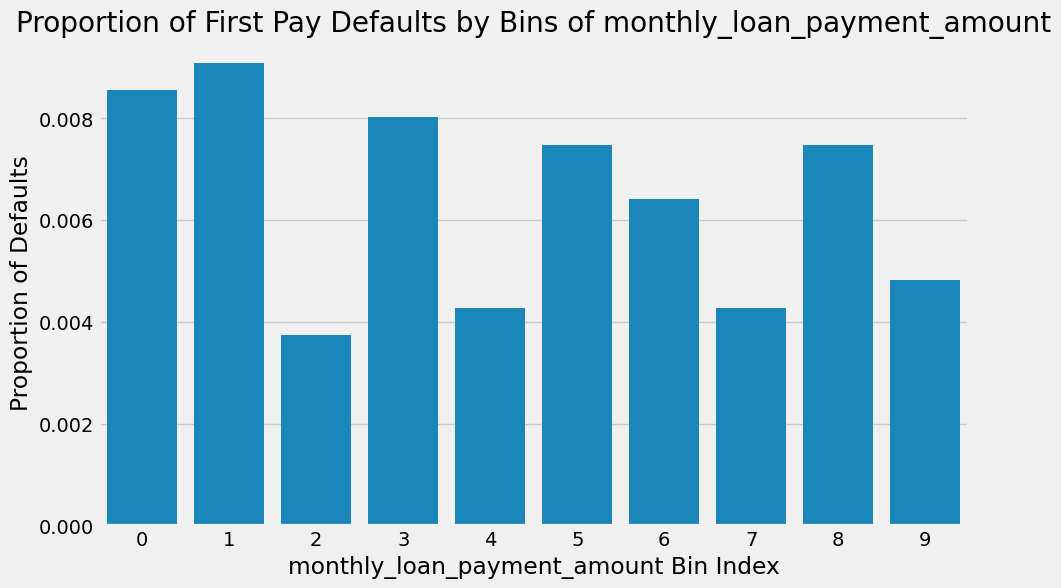

Created quantile bins for column 'fdr_vs_aal_payment_variance'.
Bin analysis for fdr_vs_aal_payment_variance:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,-3073.220,1871,10.006418,0.002138
1,1,-62.220,3085,16.499091,0.005835
2,2,0.000,654,3.4977,0.007645
3,3,9.171,1870,10.00107,0.004813
4,4,43.120,1870,10.00107,0.01123
5,5,74.790,1873,10.017114,0.007475
6,6,106.000,1865,9.974329,0.005362
7,7,146.529,1870,10.00107,0.007487
8,8,204.942,1870,10.00107,0.009091
9,9,313.489,1870,10.00107,0.004278


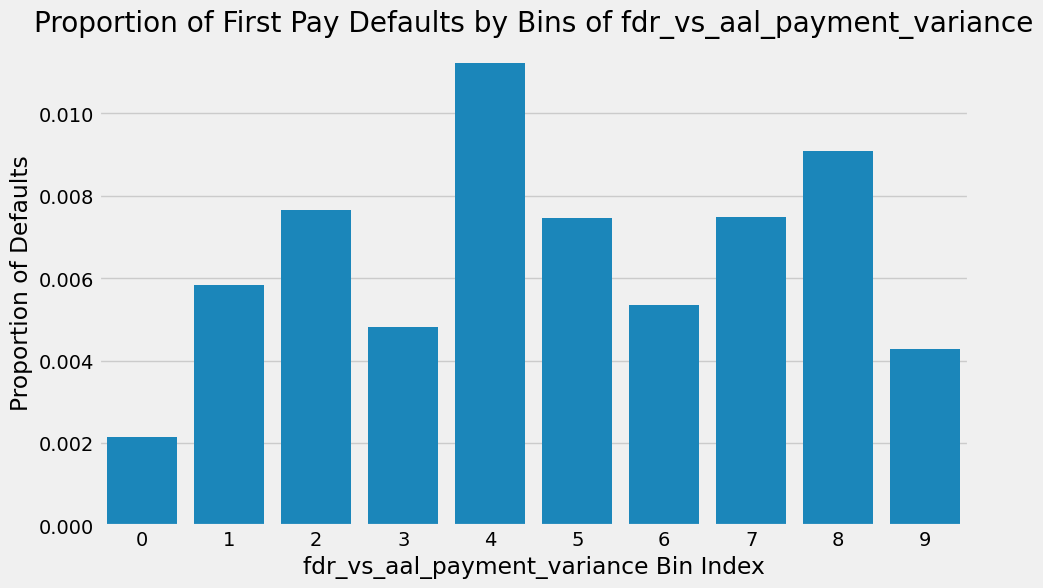

Created quantile bins for column 'fdr_vs_aal_payment_variance_percent_change'.
Bin analysis for fdr_vs_aal_payment_variance_percent_change:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,-0.875408,1866,10.000536,0.003215
1,1,-0.143783,3051,16.351359,0.005244
2,2,0.000000,681,3.649713,0.007342
3,3,0.017160,1866,10.000536,0.004823
4,4,0.119277,1866,10.000536,0.008574
5,5,0.211988,1865,9.995177,0.006971
6,6,0.292901,1866,10.000536,0.007503
7,7,0.371456,1866,10.000536,0.008039
8,8,0.459492,1866,10.000536,0.007503
9,9,0.592084,1866,10.000536,0.006431


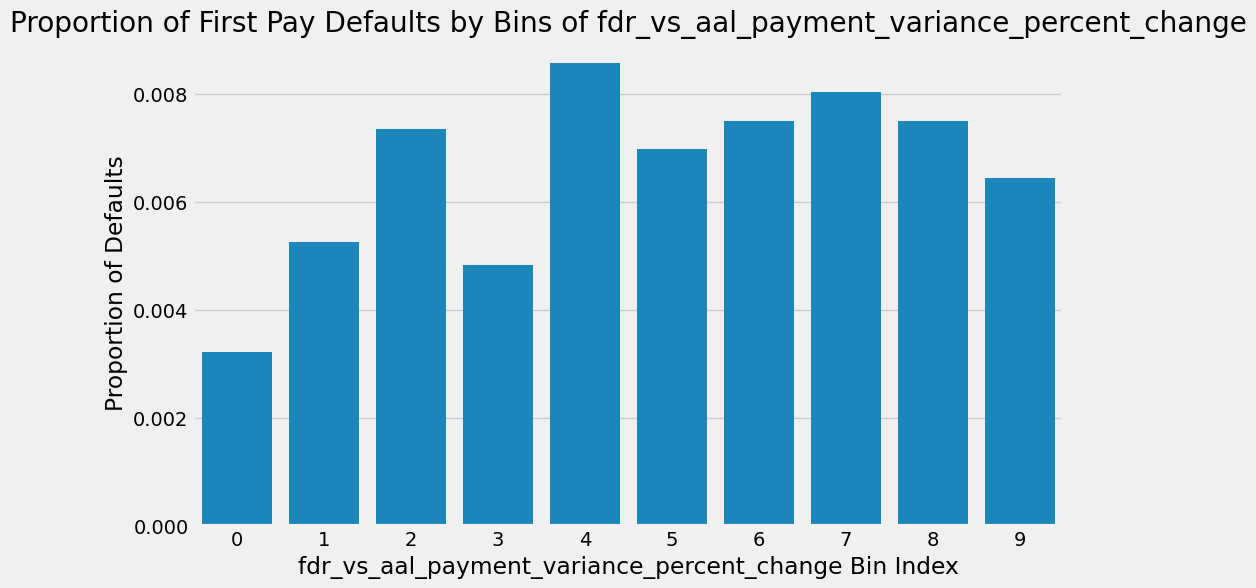

Created quantile bins for column 'fdr_vs_aal_payment_variance_percentile'.
Bin analysis for fdr_vs_aal_payment_variance_percentile:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,-8.0,2162,11.586902,0.0037
1,1,-1.0,4930,26.421566,0.005477
2,2,0.0,1981,10.61686,0.007067
3,3,1.0,2269,12.160352,0.007492
4,4,2.0,2380,12.755239,0.007983
5,5,3.0,1908,10.225628,0.006813
6,6,4.0,1258,6.742055,0.007949
7,7,5.0,1771,9.491398,0.006776


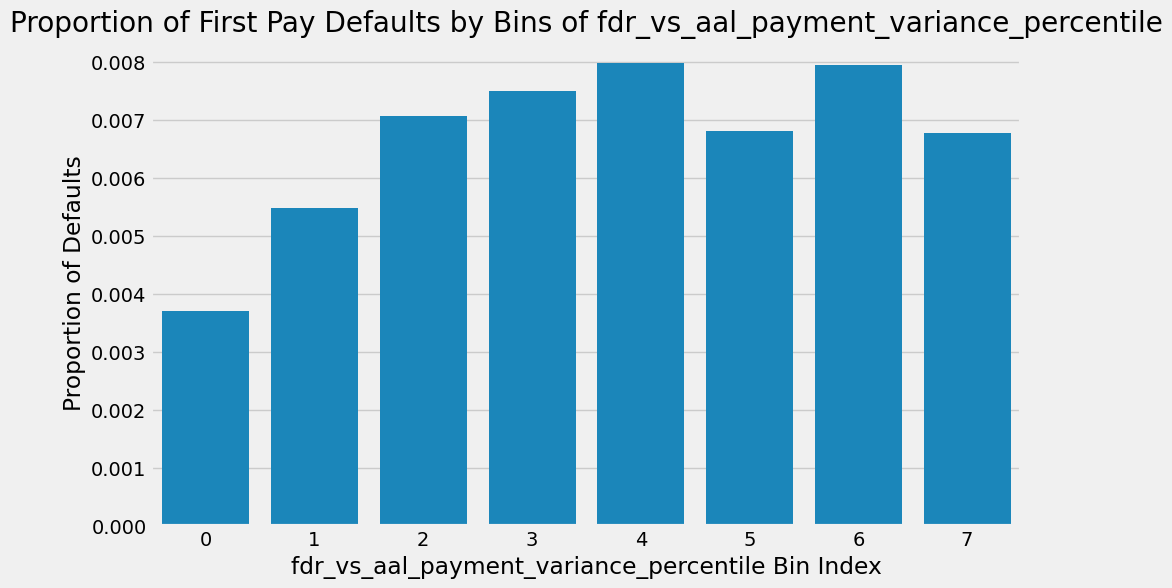

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'df' and 'flag_1st_pay_default' are already loaded and available

# Identify numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
print(f"Initial numerical columns: {list(numerical_cols)}")

# Identify constant numerical columns using a for loop for robustness
constant_numerical_cols = []
for col in numerical_cols:
    try:
        # Exclude the target variable from the nunique check if it's numeric
        if col != 'flag_1st_pay_default' and df[col].nunique() == 1:
            constant_numerical_cols.append(col)
        # Handle the case where the target variable might be in numerical_cols
        elif col == 'flag_1st_pay_default':
             continue
    except Exception as e:
        print(f"Could not determine nunique for column '{col}': {e}")
print(f"Constant numerical columns: {constant_numerical_cols}")


# Define columns to exclude from plotting (keeping previous exclusions and ensuring no overlap)
columns_to_exclude_plotting = [
    'days_elapsed_origination_to_dq_30',
    'loan_investor', # Although listed, this is likely categorical. Will handle based on dtype.
    'loan_prepaid_flag',
    'loan_contributing_investor', # Although listed, this is likely categorical. Will handle based on dtype.
    'loan_no_payment_straight_to_chargeoff_flag',
    'loan_1st_pay_default_return_code', # Although listed, this is likely categorical. Will handle based on dtype.
    'days_elapsed_origination_to_dq',
    'principal_default_percent',
    'count_dpd_1_to_10',
    'count_dpd_cured',
    'count_dpd_30',
    'loan_chargeoff_flag',
    'loan_contractual_chargeoff_flag',
    'loan_in_debt_settlement_flag',
    'flag_dq',
    'flag_never_pay',
    'loan_bk_discharged_flag',
    'loan_deceased_flag'
]
print(f"Columns to exclude from plotting: {columns_to_exclude_plotting}")


# Filter out constant numerical columns, the target variable, and specified excluded columns
plottable_numerical_cols = [
    col for col in numerical_cols
    if col not in constant_numerical_cols and
       col != 'flag_1st_pay_default' and
       col not in columns_to_exclude_plotting
]
print(f"Plottable numerical columns after filtering: {plottable_numerical_cols}")


# Columns to impute with mean
columns_to_impute_mean = ['loan_application_NDI_ratio', 'loan_application_PTI_ratio']

print(f"Attempting to plot default proportions for {len(plottable_numerical_cols)} numerical columns.")

# Iterate through plottable numerical columns and create plots of default proportions
for col in plottable_numerical_cols:
    try:
        # Use the full df with the new cluster_label column
        temp_df = df[[col, 'flag_1st_pay_default']].copy() # Create a temporary df with only the relevant columns

        # Impute missing values for specified columns with their mean
        if col in columns_to_impute_mean:
            mean_value = temp_df[col].mean()
            if pd.isna(mean_value):
                print(f"Skipping plotting for column '{col}' because it contains only null values.")
                plt.close() # Ensure figure is closed
                continue
            temp_df[col].fillna(mean_value, inplace=True)
            print(f"Imputed missing values in '{col}' with mean ({mean_value:.2f}).")

        # Remove rows where the numerical column is NaN after imputation (only if still NaNs exist)
        temp_df.dropna(subset=[col, 'flag_1st_pay_default'], inplace=True)


        if temp_df.empty:
            print(f"Skipping plotting for column '{col}' due to no non-null data for plotting after imputation.")
            continue

        # Create bins for the numerical feature
        # Using qcut for quantiles to handle skewed data, fall back to cut if too many identical values
        try:
            # Attempt to create quantile bins and capture the bins information
            bins, intervals = pd.qcut(temp_df[col], q=10, labels=False, duplicates='drop', retbins=True)
            temp_df['bin'] = bins
            print(f"Created quantile bins for column '{col}'.")

        except ValueError as ve:
            print(f"Could not create quantile bins for '{col}' ({ve}), falling back to equal-width bins.")
            try:
                # Fall back to equal-width bins and capture the bins information
                bins, intervals = pd.cut(temp_df[col], bins=10, labels=False, include_lowest=True, retbins=True)
                temp_df['bin'] = bins
                if temp_df['bin'].isnull().all():
                     print(f"Skipping plotting for column '{col}' as equal-width binning resulted in all NaNs.")
                     continue
                print(f"Created equal-width bins for column '{col}'.")

            except Exception as cut_e:
                print(f"Skipping plotting for column '{col}' due to error during binning: {cut_e}")
                continue

        # Calculate the proportion of defaults and count of loans within each bin
        bin_analysis = temp_df.groupby('bin')['flag_1st_pay_default'].agg(['count', 'mean']).reset_index()
        bin_analysis = bin_analysis.rename(columns={'count': 'loan_count', 'mean': 'default_proportion'})

        # Calculate the percentage of total population for each bin
        total_loans_in_col = bin_analysis['loan_count'].sum()
        bin_analysis['percentage_of_total'] = (bin_analysis['loan_count'] / total_loans_in_col) * 100

        if bin_analysis.empty:
             print(f"Skipping plotting for column '{col}' as no bin analysis could be calculated after binning.")
             continue

        # Display bin information including edges, count, and percentage
        bin_info = pd.DataFrame({'Bin Index': bin_analysis['bin'],
                                 'Bin Edge': intervals[:-1] if len(intervals) == len(bin_analysis) + 1 else None, # Attempt to align edges
                                 'Loan Count': bin_analysis['loan_count'],
                                 'Percentage of Total': bin_analysis['percentage_of_total'],
                                 'Default Proportion': bin_analysis['default_proportion']
                                })
        print(f"Bin analysis for {col}:")
        display(bin_info)


        # Create a bar plot of default proportions
        plt.figure(figsize=(10, 6))
        sns.barplot(x=bin_analysis['bin'], y=bin_analysis['default_proportion'])
        plt.title(f'Proportion of First Pay Defaults by Bins of {col}')
        plt.xlabel(f'{col} Bin Index') # Using bin index as labels for now
        plt.ylabel('Proportion of Defaults')
        plt.show()
        plt.close()

    except Exception as e:
        print(f"Skipping plotting for column '{col}' due to error: {e}")
        plt.close()

In [10]:
# Define the column to bin
column_to_bin = 'days_elapsed_negotiation'

# --- 2. Corrected Crosstab with Bin Limits ---
if f'{column_to_bin}_Decile_Label' in df.columns:

    print("\n## 📋 Crosstab of Decile Counts and Limits ##")

    # Calculate the count of loans in each descriptive decile bin
    decile_crosstab = df[f'{column_to_bin}_Decile_Label'].value_counts().sort_index().to_frame('Loan Count')

    # === FIX APPLIED HERE ===
    # Explicitly convert the CategoricalIndex back to an IntervalIndex
    # so we can access the .left and .right attributes.
    decile_crosstab.index = decile_crosstab.index.astype('interval')

    # Calculate the percentage of total loans
    total_loans = decile_crosstab['Loan Count'].sum()
    decile_crosstab['Percentage'] = (decile_crosstab['Loan Count'] / total_loans) * 100

    # Extract the lower and upper limit from the now-correct Interval Index
    decile_crosstab['Lower Limit'] = decile_crosstab.index.left
    decile_crosstab['Upper Limit'] = decile_crosstab.index.right

    # Reorder columns for clarity
    decile_crosstab = decile_crosstab[['Lower Limit', 'Upper Limit', 'Loan Count', 'Percentage']]

    display(decile_crosstab)

##Days Elapsed Negotiation Historgram

Decile Binning and Crosstab created for 'days_elapsed_negotiation'.

## 📈 Bar Plot: Loan Count Frequency by Decile Bin ##


/tmp/ipykernel_683/2871449064.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


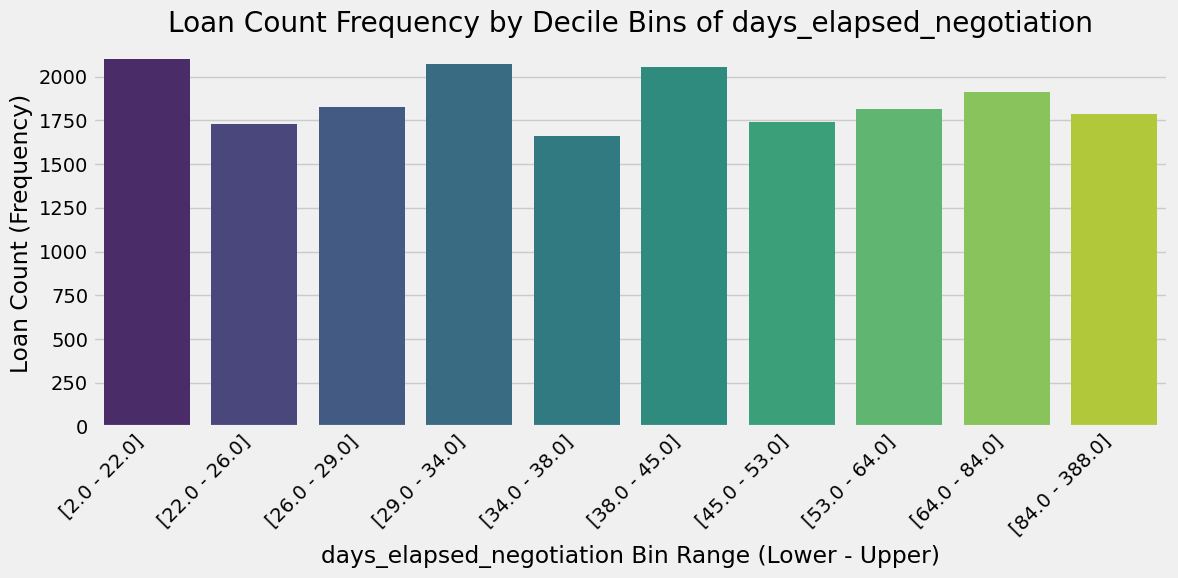

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'df' is your loaded DataFrame
column_to_bin = 'days_elapsed_negotiation'
decile_label_col = f'{column_to_bin}_Decile_Label'

# --- 1. Recreate Labeled Decile Bins and Crosstab (Necessary Setup) ---

temp_df = df.dropna(subset=[column_to_bin]).copy()

# A. Create the bins and intervals
try:
    decile_cut, intervals = pd.qcut(
        temp_df[column_to_bin],
        q=10,
        labels=False,
        duplicates='drop',
        retbins=True
    )
    # B. Create the descriptive labels
    decile_labels = pd.cut(
        temp_df[column_to_bin],
        bins=intervals,
        include_lowest=True,
        duplicates='drop',
        right=True
    )
    df[decile_label_col] = decile_labels

    # C. Create the Crosstab with Loan Counts
    decile_crosstab = df[decile_label_col].value_counts().sort_index().to_frame('Loan Count')

    # FIX: Convert the index back to IntervalIndex to extract limits
    decile_crosstab.index = decile_crosstab.index.astype('interval')

    # D. Prepare labels for the X-axis
    # Create descriptive labels like "[Lower - Upper]"
    decile_crosstab['Bin Label'] = (
        '[' + decile_crosstab.index.left.round(2).astype(str) +
        ' - ' +
        decile_crosstab.index.right.round(2).astype(str) +
        ']'
    )

    print(f"Decile Binning and Crosstab created for '{column_to_bin}'.")

except Exception as e:
    print(f"Skipping visualization due to error in binning: {e}")
    # Handle the error gracefully if binning fails
    exit() # Exit the block if setup fails


# --- 2. Bar Plot for Loan Count Frequency ---

print(f"\n## 📈 Bar Plot: Loan Count Frequency by Decile Bin ##")

plt.figure(figsize=(12, 6))

# Use the 'Bin Label' for the x-axis and 'Loan Count' for the y-axis
sns.barplot(
    x='Bin Label',
    y='Loan Count',
    data=decile_crosstab,
    palette="viridis"
)

plt.title(f'Loan Count Frequency by Decile Bins of {column_to_bin}')
plt.xlabel(f'{column_to_bin} Bin Range (Lower - Upper)')
plt.ylabel('Loan Count (Frequency)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()


## 🗓️ Processing Segment: loan_vintage_month = 2026-01-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-01-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


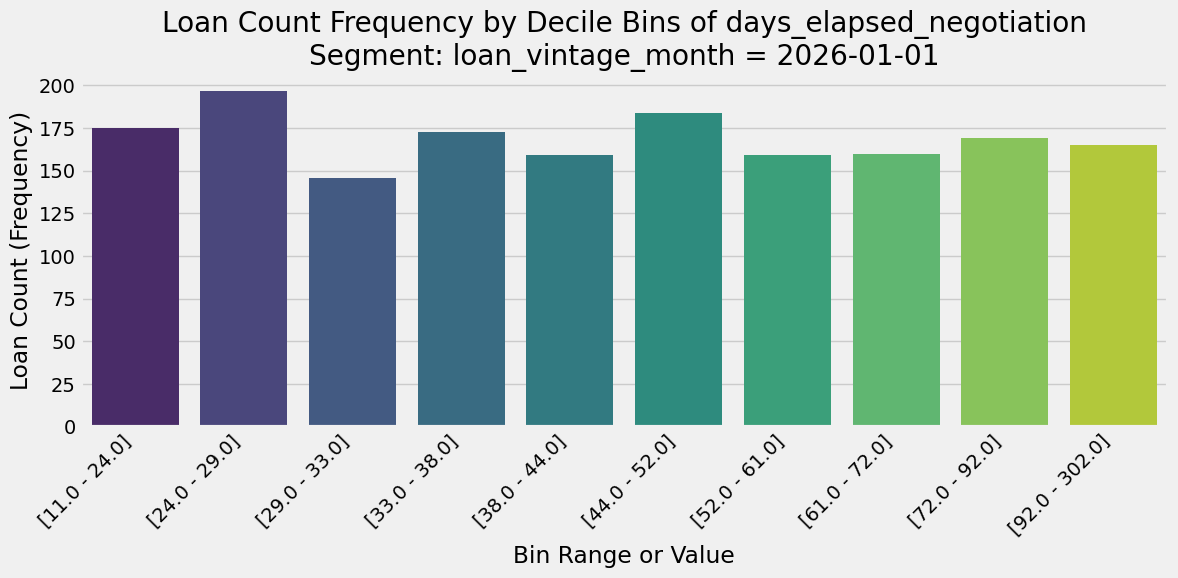


## 🗓️ Processing Segment: loan_vintage_month = 2026-02-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-02-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


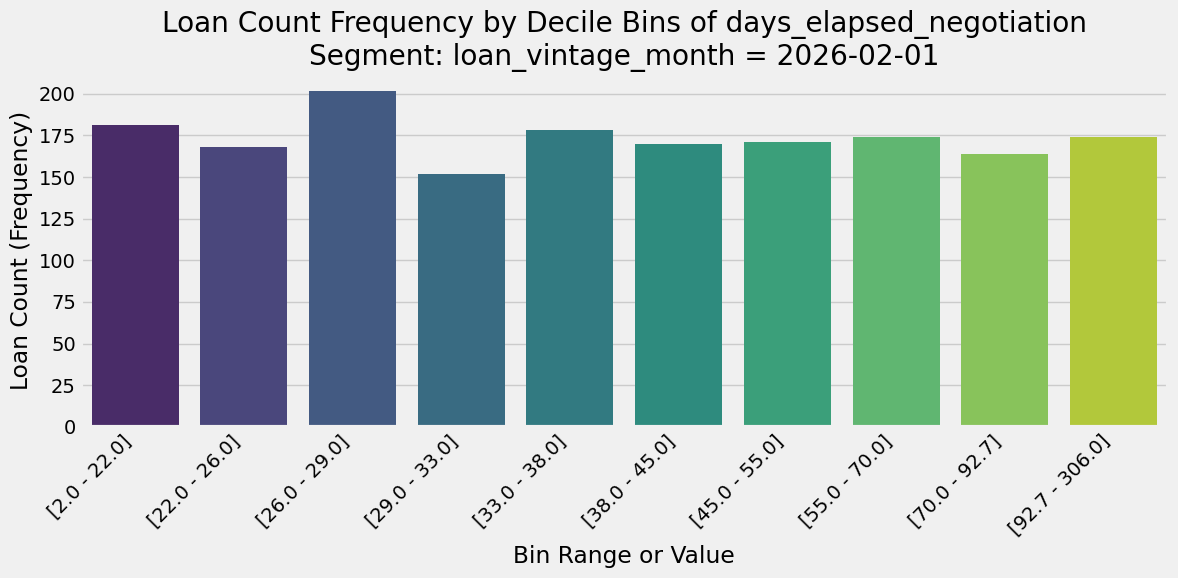


## 🗓️ Processing Segment: loan_vintage_month = 2026-03-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-03-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


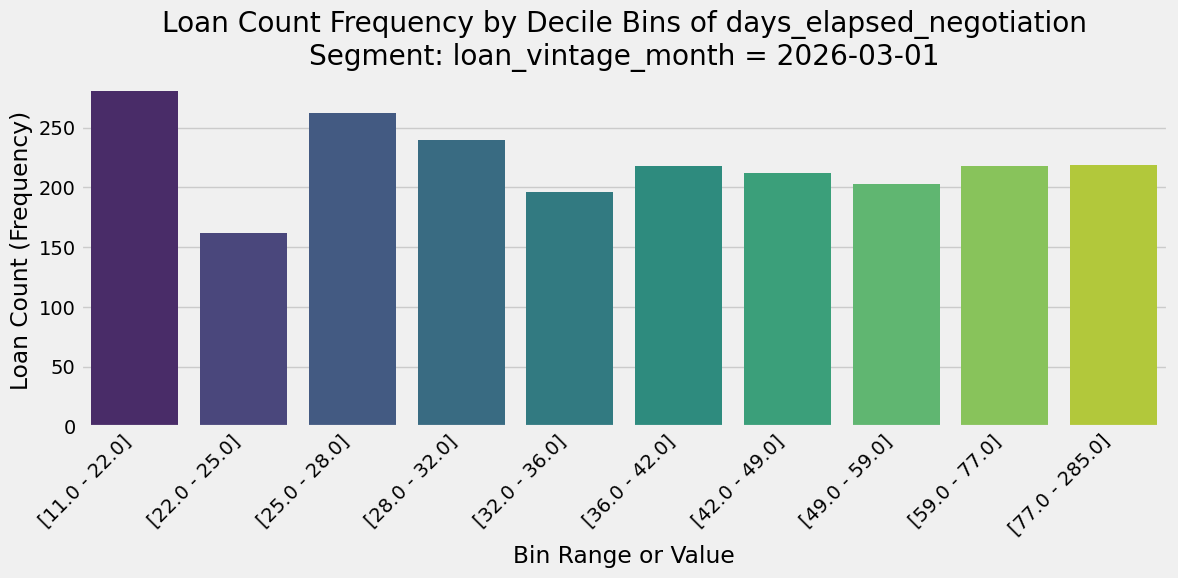


## 🗓️ Processing Segment: loan_vintage_month = 2026-04-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-04-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


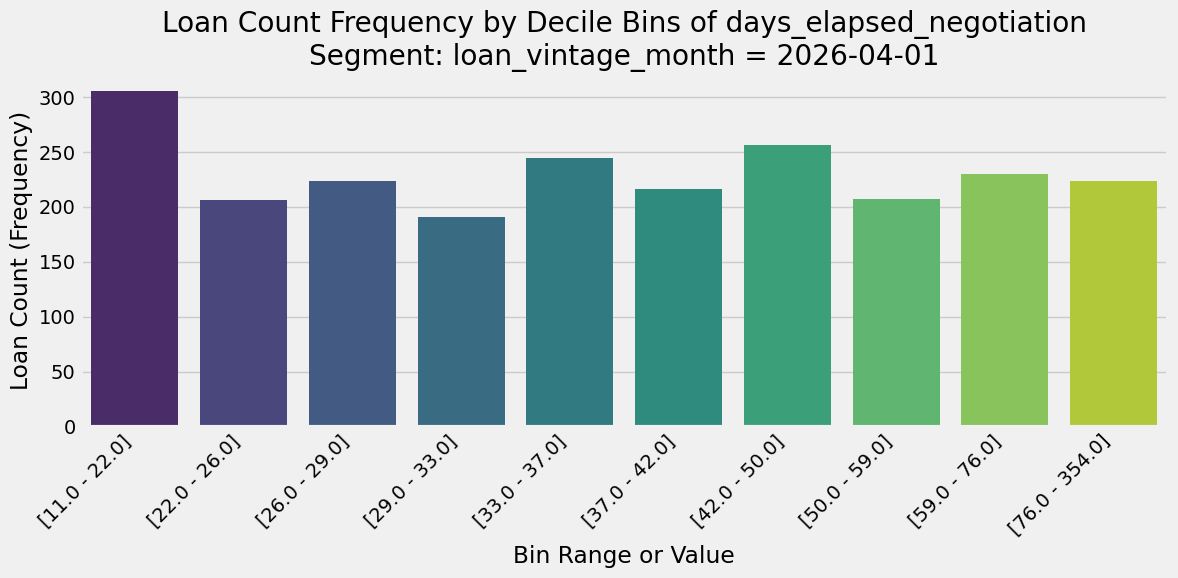


## 🗓️ Processing Segment: loan_vintage_month = 2026-05-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-05-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


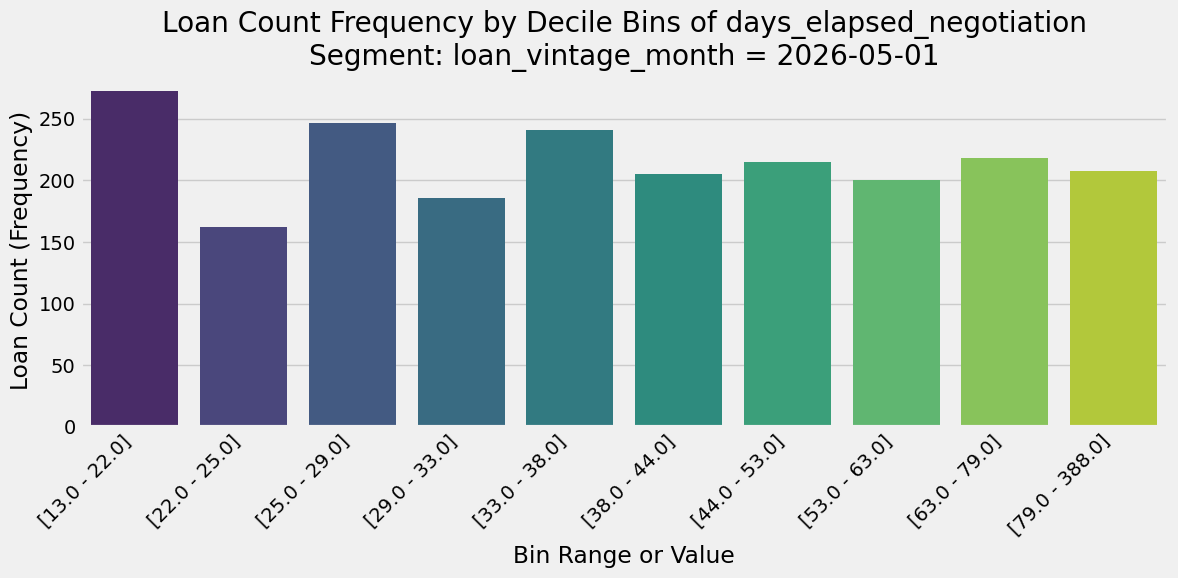


## 🗓️ Processing Segment: loan_vintage_month = 2026-06-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-06-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


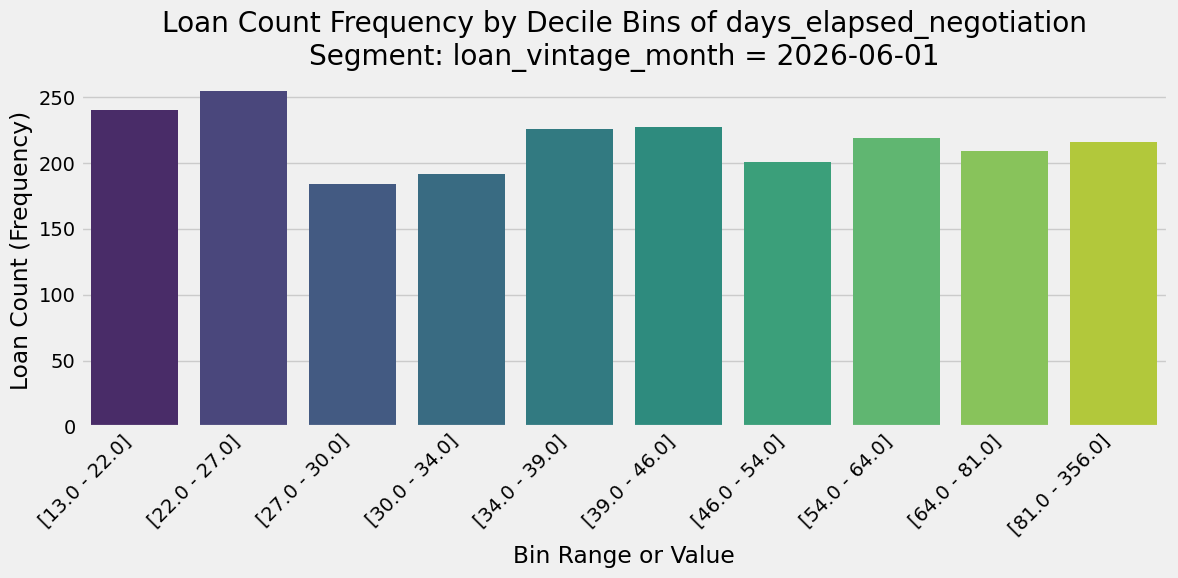


## 🗓️ Processing Segment: loan_vintage_month = 2026-07-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-07-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


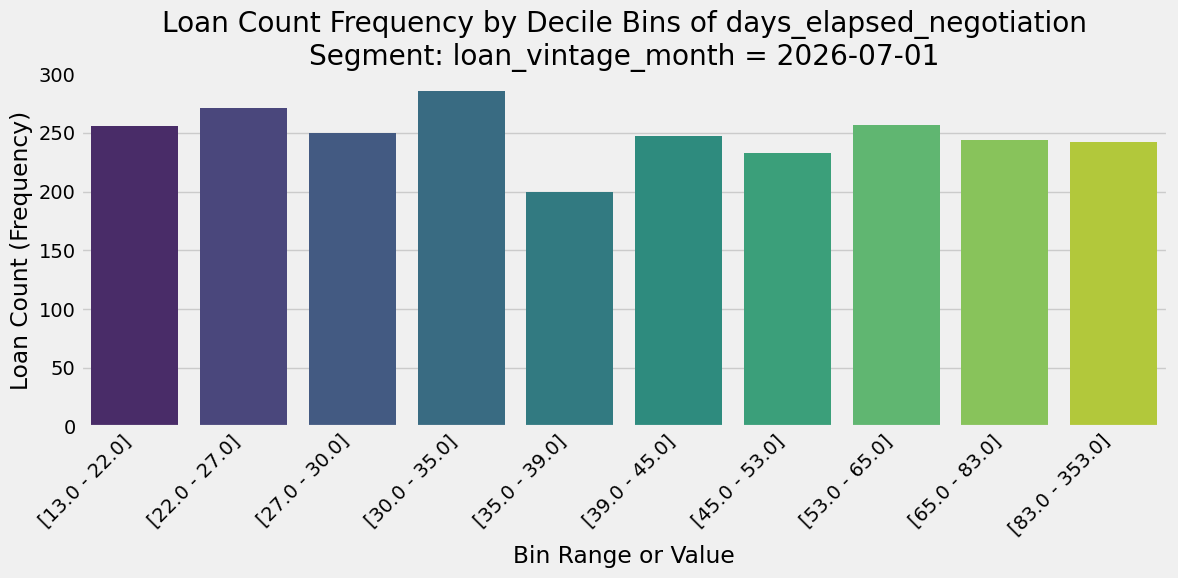


## 🗓️ Processing Segment: loan_vintage_month = 2026-08-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-08-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


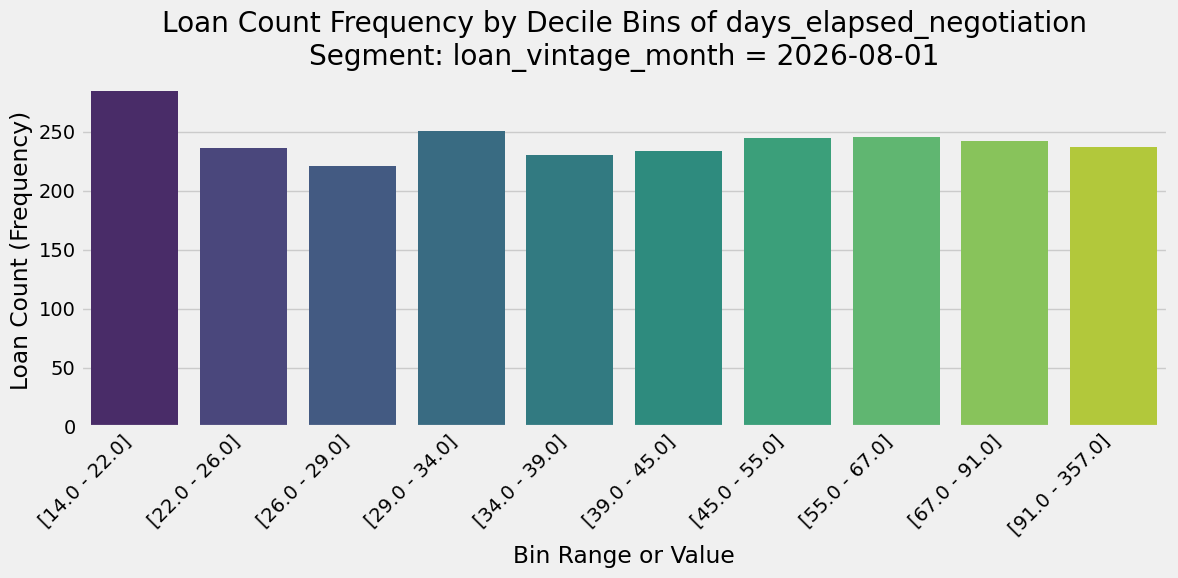


## 🗓️ Processing Segment: loan_vintage_month = 2026-09-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-09-01.


/tmp/ipykernel_683/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


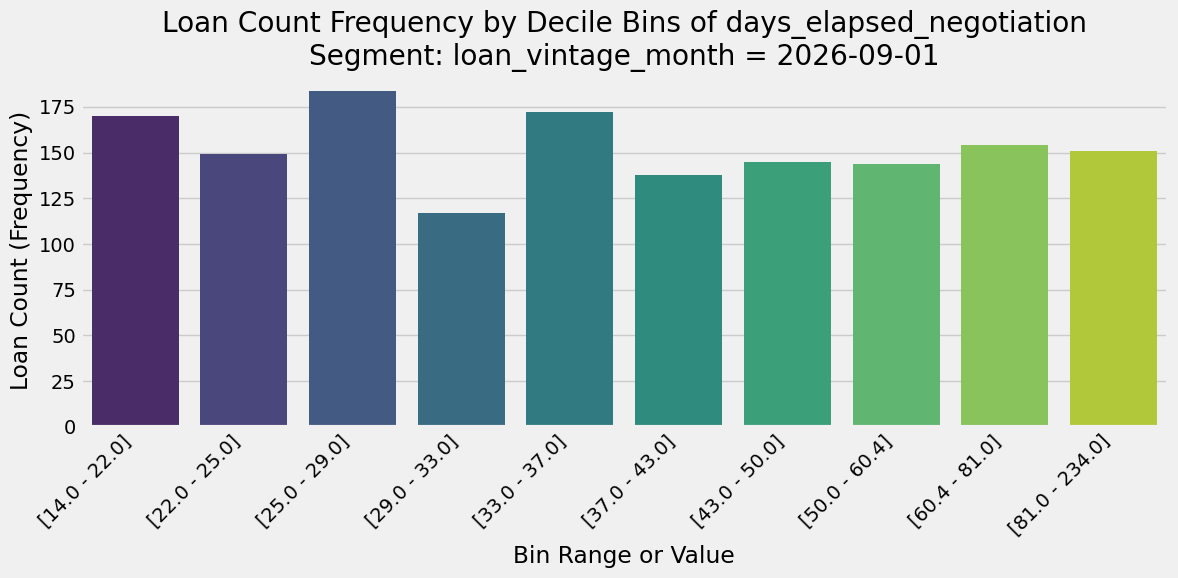

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'df' is your loaded DataFrame
column_to_bin = 'days_elapsed_negotiation'
segment_col = 'loan_vintage_month'

# --- 0. Prepare the segmentation column and unique values ---
if segment_col not in df.columns:
    print(f"Error: '{segment_col}' column not found in the DataFrame.")
    exit()

# Get and sort unique vintage months. Use np.sort() for robustness with datetime types.
vintage_months = df[segment_col].unique()
vintage_months = np.sort(vintage_months)

# --- Loop through each vintage month to create segmented visualizations ---
for vintage_month in vintage_months:
    print(f"\n=======================================================")
    print(f"## 🗓️ Processing Segment: {segment_col} = {vintage_month} ##")
    print(f"=======================================================")

    # 1. Filter the data for the current segment
    segment_df = df[df[segment_col] == vintage_month].copy()

    # Get the non-null data for the target column
    temp_data = segment_df.dropna(subset=[column_to_bin])[column_to_bin]

    # Check for minimum data points
    if temp_data.shape[0] < 10:
        print(f"Skipping visualization for {vintage_month}: Not enough non-null data points ({temp_data.shape[0]}) to create 10 deciles.")
        continue

    # --- 1. Decile Binning and Crosstab (PER SEGMENT) ---

    try:
        # A. Use pd.qcut to determine the bin edges (intervals)
        _, intervals = pd.qcut(
            temp_data,
            q=10,
            labels=False,
            duplicates='drop',
            retbins=True
        )

        # B. Use pd.cut with the determined intervals to create the IntervalIndex labels
        decile_labels = pd.cut(
            temp_data,
            bins=intervals,
            include_lowest=True,
            duplicates='drop',
            right=True
        )

        # C. Create the Crosstab with Loan Counts
        decile_crosstab = decile_labels.value_counts().sort_index().to_frame('Loan Count')

        # --- FIX: Explicitly convert the CategoricalIndex to IntervalIndex ---
        # This addresses the 'CategoricalIndex' object has no attribute 'left' error.
        if isinstance(decile_crosstab.index, pd.CategoricalIndex):
            decile_crosstab.index = decile_crosstab.index.astype('interval')


        # --- Check for Single Bin (Non-IntervalIndex) ---
        # Now this check should be for IntervalIndex, which covers all valid multi-bin cases.
        if not isinstance(decile_crosstab.index, pd.IntervalIndex):
            # Handle the true single-bin case (or remaining rare edge cases)
            if len(decile_crosstab) == 1:
                total_count = decile_crosstab['Loan Count'].iloc[0]
                unique_value = temp_data.iloc[0]

                decile_crosstab = pd.DataFrame({
                    'Bin Label': [f'All Values = {unique_value.round(2)}'],
                    'Loan Count': [total_count]
                })
                print(f"Plotting {vintage_month} as a single bin (value={unique_value.round(2)}).")
            else:
                print(f"Skipping visualization for {vintage_month}: Binning resulted in an unexpected Index type after conversion.")
                continue

        else:
            # D. Prepare labels for the X-axis (Standard Decile case)
            decile_crosstab['Bin Label'] = (
                '[' + decile_crosstab.index.left.round(2).astype(str) +
                ' - ' +
                decile_crosstab.index.right.round(2).astype(str) +
                ']'
            )
            print(f"Decile Binning and Crosstab created for '{column_to_bin}' in segment {vintage_month}.")


    except Exception as e:
        print(f"Skipping visualization due to error in binning for {vintage_month}: {e}")
        continue

    # --- 2. Bar Plot for Loan Count Frequency (PER SEGMENT) ---
    # This section now works for both deciles and the single-bin case.

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x='Bin Label',
        y='Loan Count',
        data=decile_crosstab,
        palette="viridis"
    )

    plt.title(f'Loan Count Frequency by Decile Bins of {column_to_bin}\nSegment: {segment_col} = {vintage_month}')
    plt.xlabel('Bin Range or Value')
    plt.ylabel('Loan Count (Frequency)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    plt.close()


## 🎻 Violin Plot Visualization for days_elapsed_negotiation ##


/tmp/ipykernel_683/1528239298.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=decile_label_col, y=column_to_bin, data=plot_df, inner="quartile", palette="Set2")


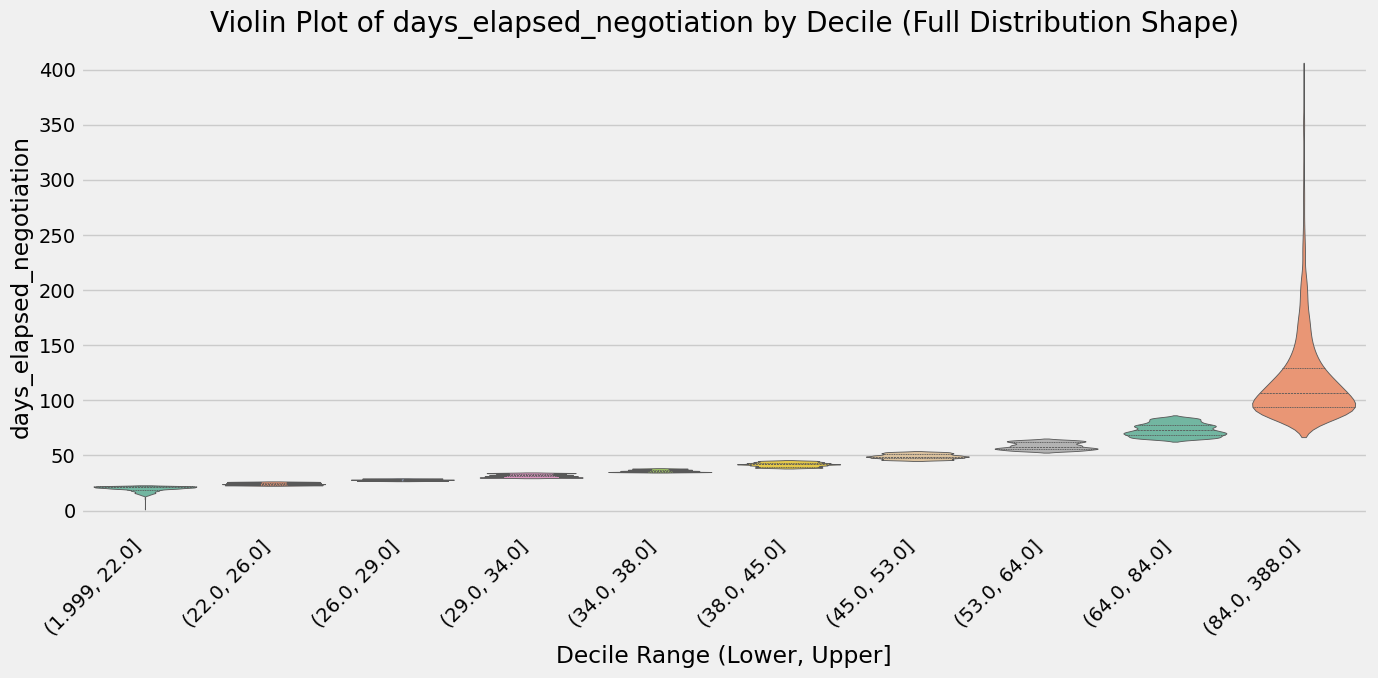

In [13]:
# Assuming 'df' and the column names are defined as in the previous script
column_to_bin = 'days_elapsed_negotiation'
decile_label_col = f'{column_to_bin}_Decile_Label'

# Filter for non-null values for plotting
plot_df = df.dropna(subset=[column_to_bin, decile_label_col]).copy()

print(f"\n## 🎻 Violin Plot Visualization for {column_to_bin} ##")

plt.figure(figsize=(14, 7))
# Use the 'split=True' or 'inner="quartile"' parameter for more detail if needed.
sns.violinplot(x=decile_label_col, y=column_to_bin, data=plot_df, inner="quartile", palette="Set2")
plt.title(f'Violin Plot of {column_to_bin} by Decile (Full Distribution Shape)')
plt.xlabel('Decile Range (Lower, Upper]')
plt.ylabel(column_to_bin)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()


## 🎯 Strip Plot Visualization for days_elapsed_negotiation ##


/tmp/ipykernel_683/2766928799.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=decile_label_col, y=column_to_bin, data=plot_df, jitter=0.3, size=3, palette="Set1")


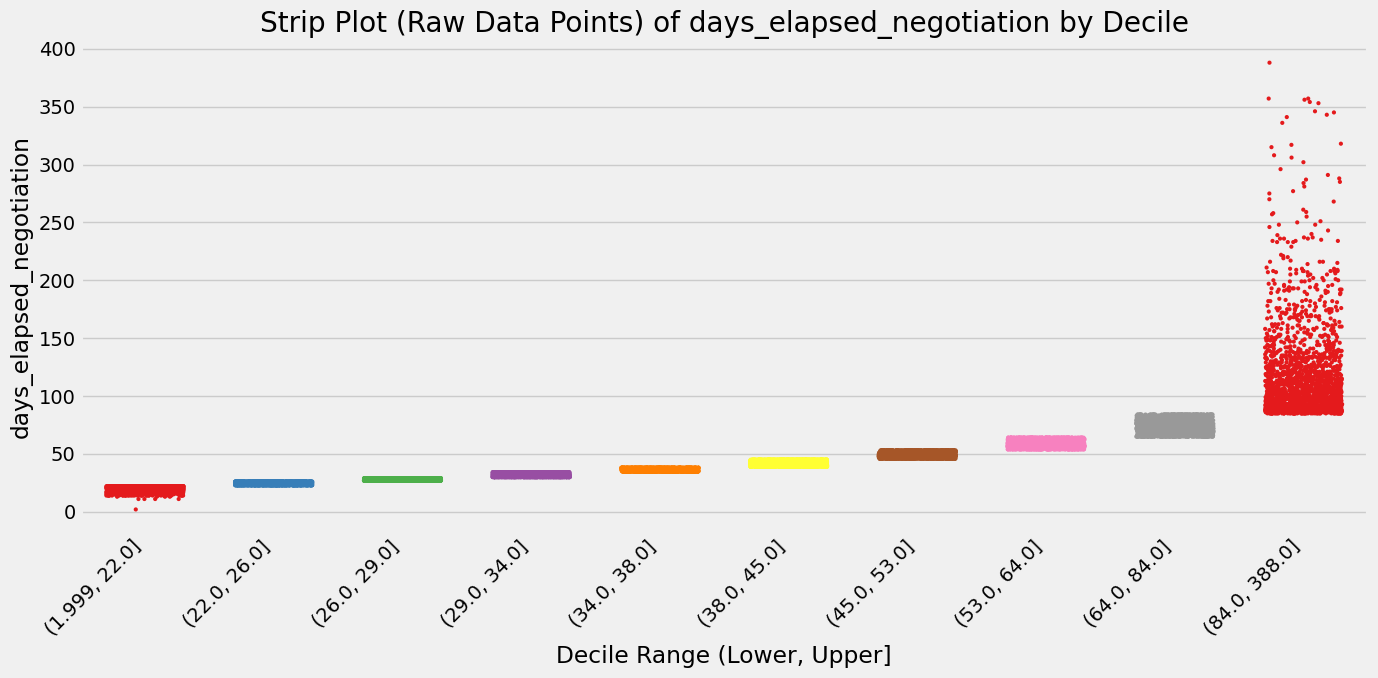

In [14]:
# Assuming 'df' and the column names are defined as in the previous script
column_to_bin = 'days_elapsed_negotiation'
decile_label_col = f'{column_to_bin}_Decile_Label'

# Filter for non-null values for plotting
plot_df = df.dropna(subset=[column_to_bin, decile_label_col]).copy()

print(f"\n## 🎯 Strip Plot Visualization for {column_to_bin} ##")

plt.figure(figsize=(14, 7))
# 'jitter=True' spreads the points horizontally for visibility
sns.stripplot(x=decile_label_col, y=column_to_bin, data=plot_df, jitter=0.3, size=3, palette="Set1")
plt.title(f'Strip Plot (Raw Data Points) of {column_to_bin} by Decile')
plt.xlabel('Decile Range (Lower, Upper]')
plt.ylabel(column_to_bin)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

# Visualize categorical feature distributions by default status

## Subtask:
Create bar plots showing the count or proportion of defaulting customers within each category of the categorical features.


**Reasoning**:
Create bar plots showing the proportion of defaulting customers within each category of the categorical features to visualize their contribution to the target variable.



Analysis for categorical feature: loan_consultant_name


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_consultant_name,,,
Alex Chavez,526,2.813135,0.005703
Alicia Villa,200,1.069633,0.005000
Amani Woods,48,0.256712,0.020833
Ana Daneri Santamaria,317,1.695368,0.009464
Andrae Holden,194,1.037544,0.000000
...,...,...,...
Tony Valicento,231,1.235426,0.008658
Tosh Oxborrow,271,1.449353,0.003690
Tyler Deterville,489,2.615253,0.006135


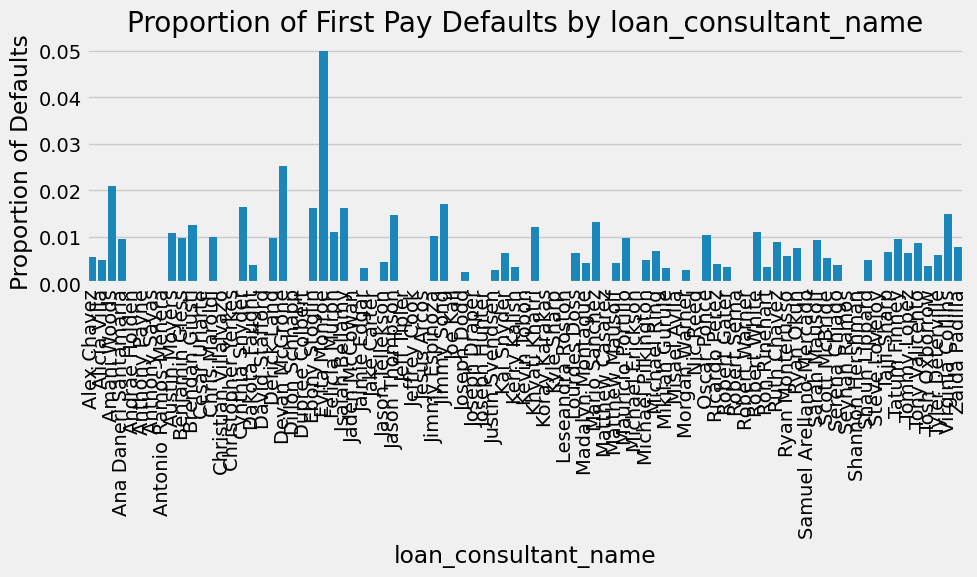

Analysis for categorical feature: loan_detail_1_debt_relief_firm


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_detail_1_debt_relief_firm,,,
ACHIEVE RESOLUTION,311,1.663279,0.006431
FREEDOM DEBT RELIEF,14757,78.922879,0.006776
"TURNBULL LAW GROUP NJ, LLC",532,2.845224,0.009398
"TURNBULL LAW GROUP SC, LLC",312,1.668628,0.000000
"TURNBULL LAW GROUP, LLC",2786,14.899989,0.004666


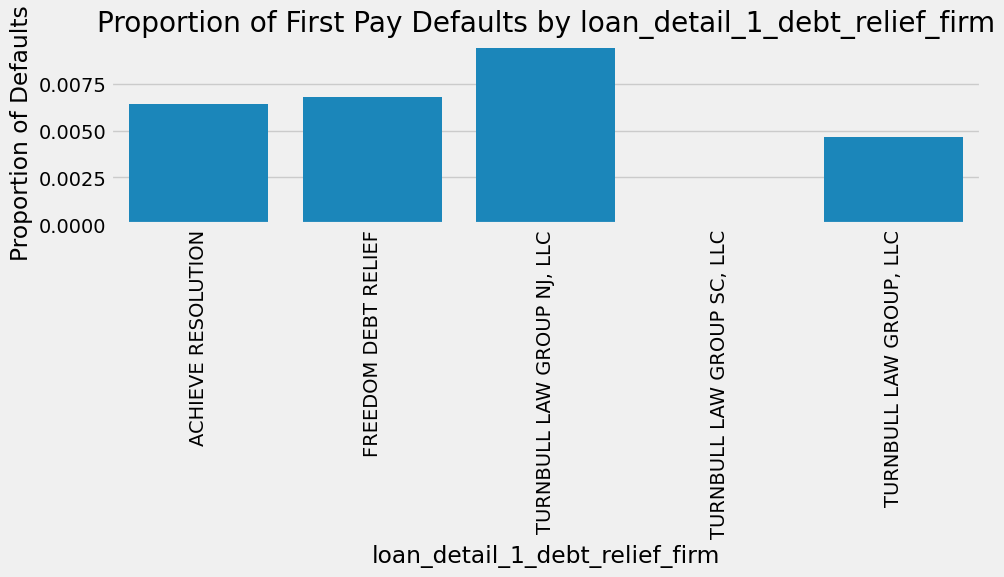

Analysis for categorical feature: loan_vintage_quarter


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_vintage_quarter,,,
20261,5632,30.120869,0.007102
20262,6629,35.452990,0.007392
20263,6437,34.426142,0.004816


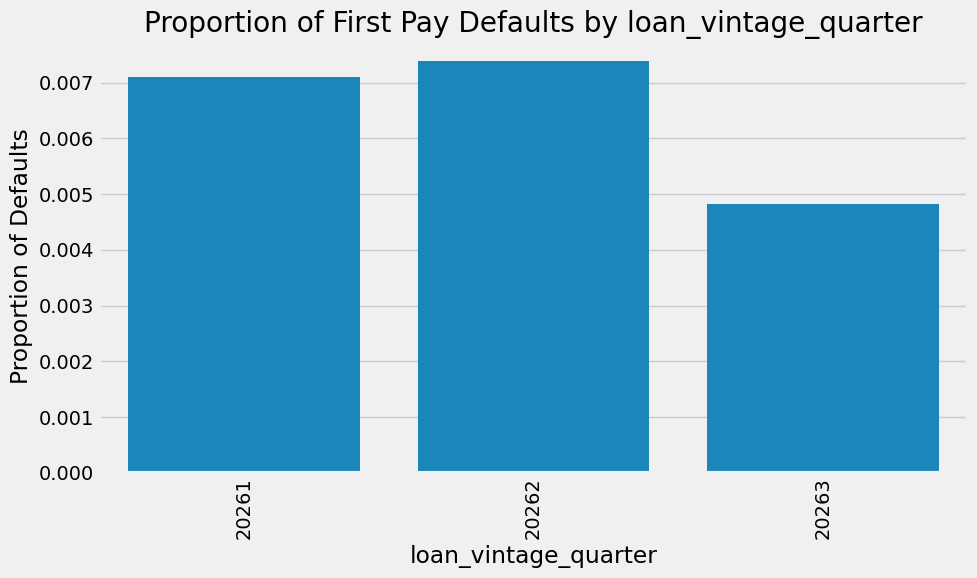

Analysis for categorical feature: loan_adr_retail_vs_wholesale


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_adr_retail_vs_wholesale,,,
Retail,12555,67.146219,0.006452
Wholesale,6143,32.853781,0.006349


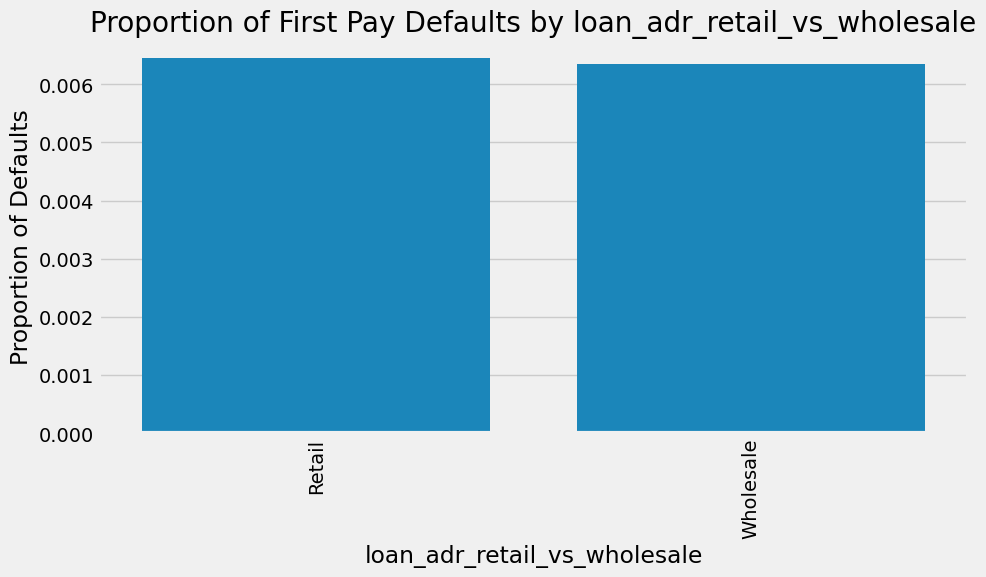

Skipping plotting for column 'loan_application_lead_category' due to error: division by zero
Skipping plotting for column 'loan_application_lead_restrictions' due to error: division by zero
Skipping plotting for column 'loan_application_customer_experience' due to error: division by zero
Analysis for categorical feature: loan_application_utm_lead_source


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_application_utm_lead_source,,,
Bubz,3,0.017779,0.000000
Call-in,4,0.023705,0.000000
FDR Credit Report,3,0.017779,0.000000
GFI Referral,2,0.011853,0.000000
Long Form,14704,87.139979,0.006189
Phone Lead,1120,6.637430,0.008929
Short Form,984,5.831457,0.006098
WFG Referral,50,0.296314,0.000000
Web Form,4,0.023705,0.250000


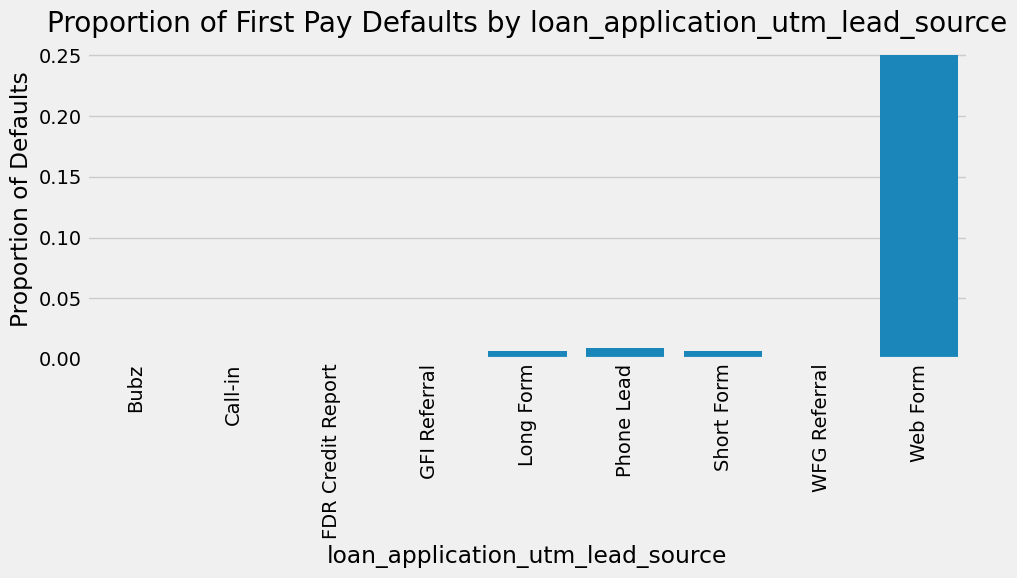

Analysis for categorical feature: loan_application_utm_lead_channel


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_application_utm_lead_channel,,,
affiliate,4653,37.203166,0.004728
app,15,0.119933,0.000000
direct mail,9,0.071960,0.000000
display,1918,15.335412,0.008863
imp,5,0.039978,0.000000
lendage,24,0.191893,0.041667
nurture,2,0.015991,0.000000
offline,6,0.047973,0.000000
organic,1650,13.192612,0.007273


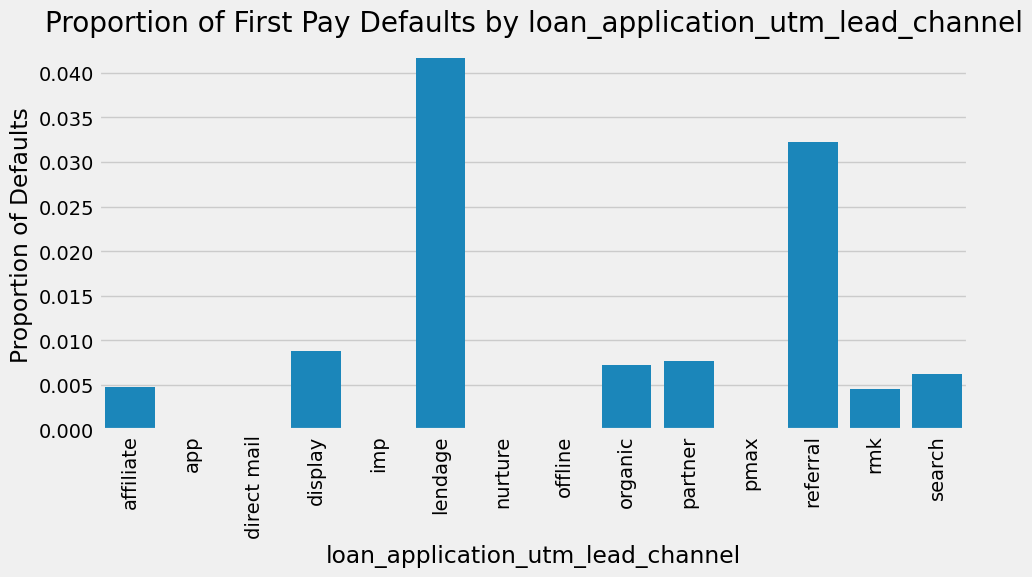

Analysis for categorical feature: loan_application_loan_use


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_application_loan_use,,,
Consolidation Plus,18698,100.0,0.006418


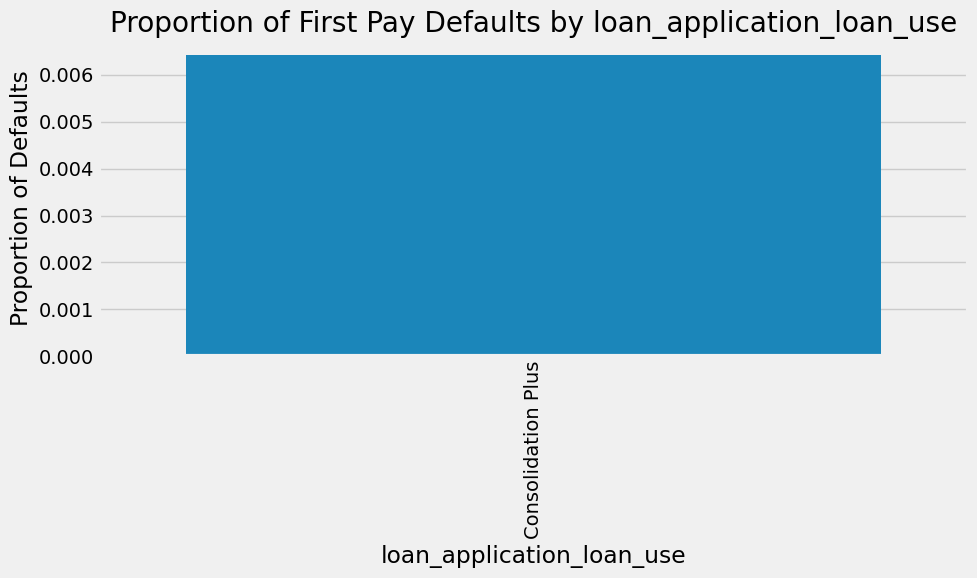

Analysis for categorical feature: loan_origination_loan_amount_band


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_origination_loan_amount_band,,,
10K to 15K,4678,25.018719,0.004489
15K to 18K,2083,11.140229,0.006721
18K to 20K,1063,5.685100,0.008467
20K to 25K,1962,10.493101,0.007136
25K to 30K,1188,6.353621,0.005051
30K to 35K,858,4.588726,0.006993
<10K,5160,27.596534,0.007946
>35K,1706,9.123970,0.005275


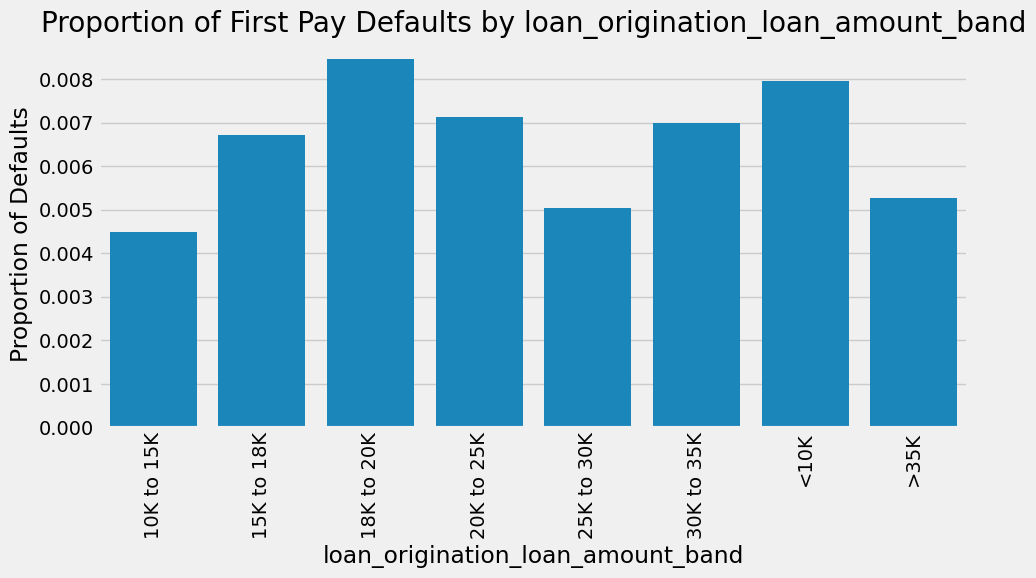

Analysis for categorical feature: loan_origination_interest_rate_band


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_origination_interest_rate_band,,,
≥20% and <25%,13606,72.767141,0.005733
≥25%,5092,27.232859,0.008248


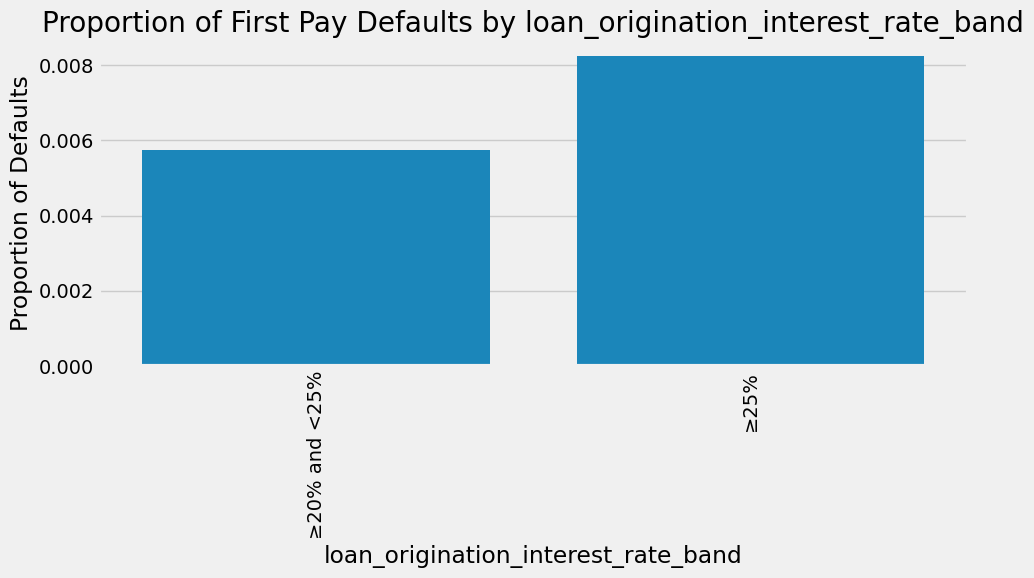

Analysis for categorical feature: loan_origination_principal_period


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_origination_principal_period,,,
BW,9175,49.069419,0.004360
MO,7635,40.833244,0.008513
S4,471,2.518986,0.010616
SM,1417,7.578351,0.007057


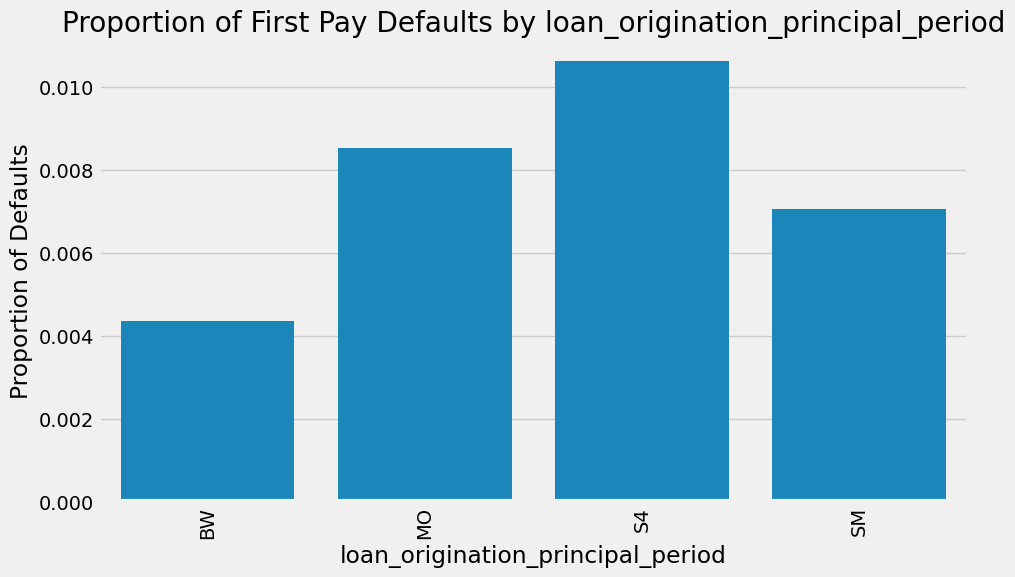

Analysis for categorical feature: borrower_language


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_language,,,
ENGLISH,18697,99.994652,0.006418
SPANISH,1,0.005348,0.000000


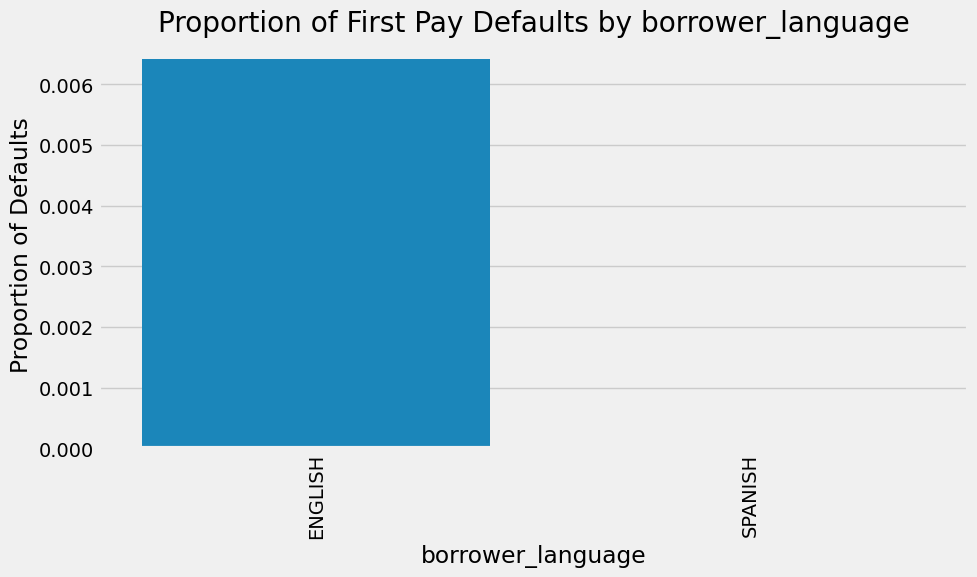

Analysis for categorical feature: borrower_fico_bands_origination


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_fico_bands_origination,,,
300 - 579,10910,58.348486,0.006966
580 - 669,7333,39.218098,0.005318
670 - 739,435,2.326452,0.011494
740 - 799,17,0.090919,0.000000
> 800,3,0.016044,0.000000


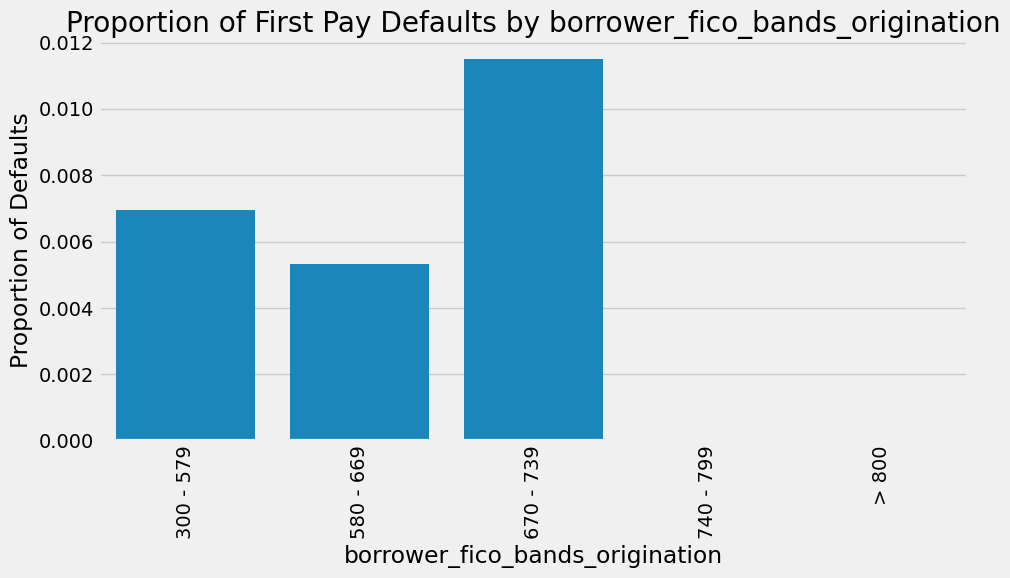

Analysis for categorical feature: borrower_fico_band_category_origination


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_fico_band_category_origination,,,
Exceptional,3,0.016044,0.000000
Fair,7333,39.218098,0.005318
Good,435,2.326452,0.011494
Very Good,17,0.090919,0.000000
Very Poor,10910,58.348486,0.006966


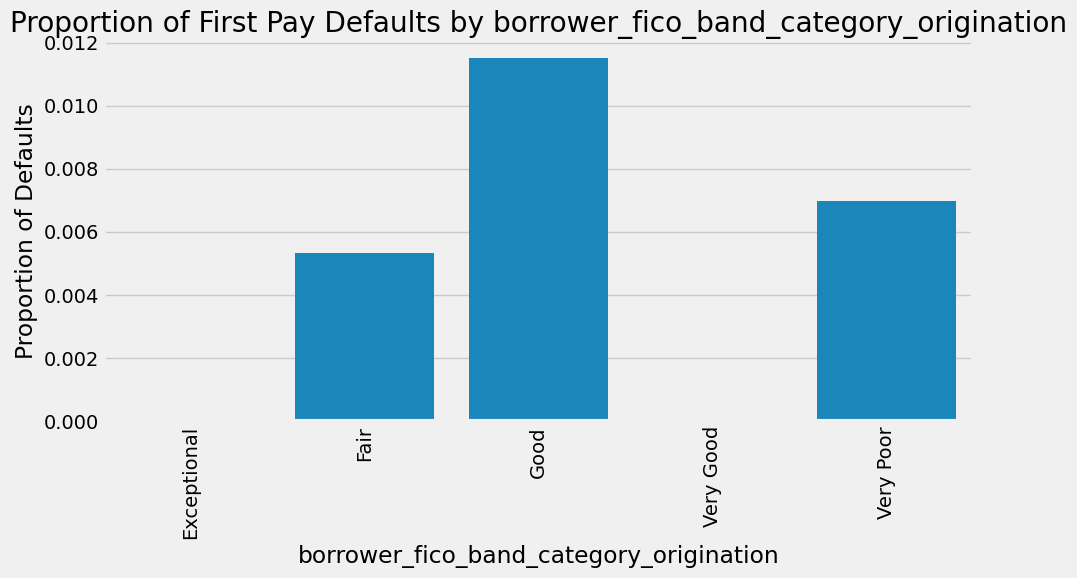

Analysis for categorical feature: borrower_annual_income_band


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_annual_income_band,,,
< 50K,5180,27.703498,0.010232
> 150K,1097,5.866938,0.007293
≥ 100K and < 125K,1994,10.664242,0.002006
≥ 125K and < 150K,986,5.273291,0.007099
≥ 50K and < 75K,5521,29.527222,0.004890
≥ 75K and < 100K,3920,20.964809,0.005357


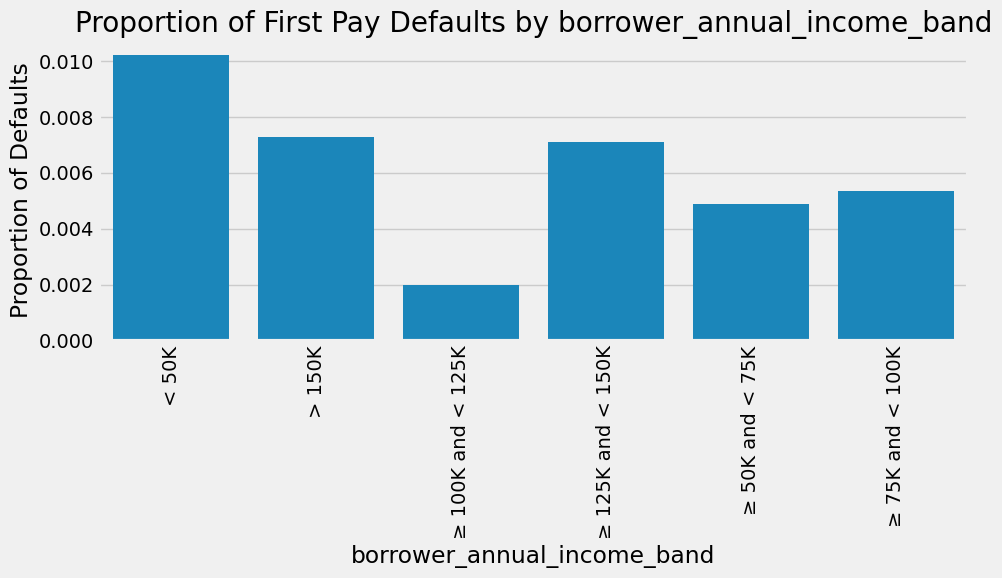

Analysis for categorical feature: borrower_origination_risk_group_twentile


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_origination_risk_group_twentile,,,
Tier 1,12850,68.723928,0.005136
Tier 2,5848,31.276072,0.009234


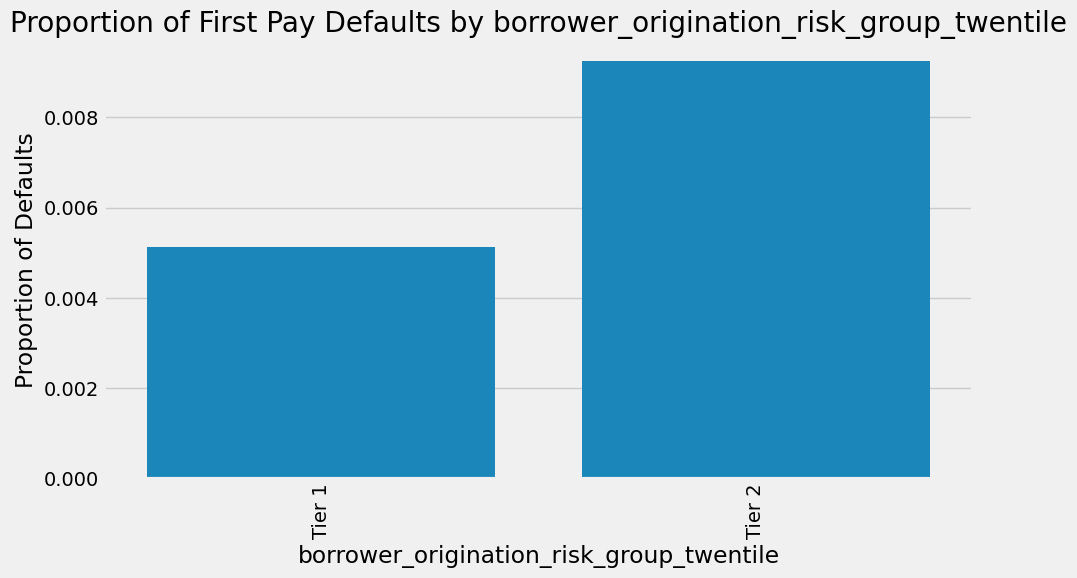

Analysis for categorical feature: borrower_origination_state


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_origination_state,,,
AK,44,0.235319,0.000000
AL,374,2.000214,0.000000
AR,265,1.417264,0.003774
AZ,385,2.059044,0.007792
CA,1981,10.594716,0.006562
DC,25,0.133704,0.000000
DE,49,0.262060,0.000000
FL,1840,9.840625,0.008696
GA,563,3.011017,0.005329


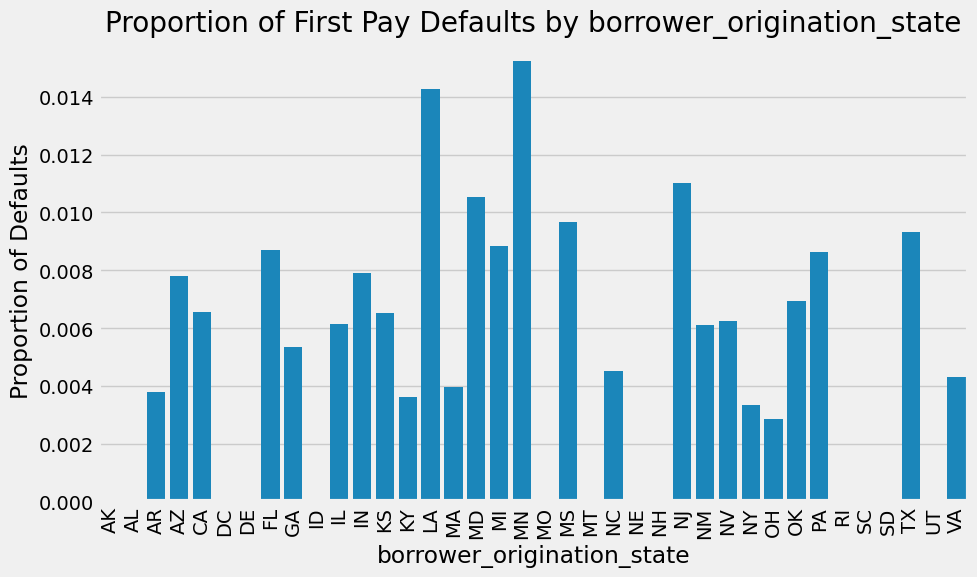

Analysis for categorical feature: loan_origination_first_payment_day_of_week


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_origination_first_payment_day_of_week,,,
Friday,7792,41.672906,0.005133
Monday,1838,9.829928,0.010337
Saturday,1840,9.840625,0.007609
Sunday,1435,7.674618,0.006272
Thursday,2150,11.498556,0.006047
Tuesday,1564,8.364531,0.004476
Wednesday,2079,11.118836,0.008658


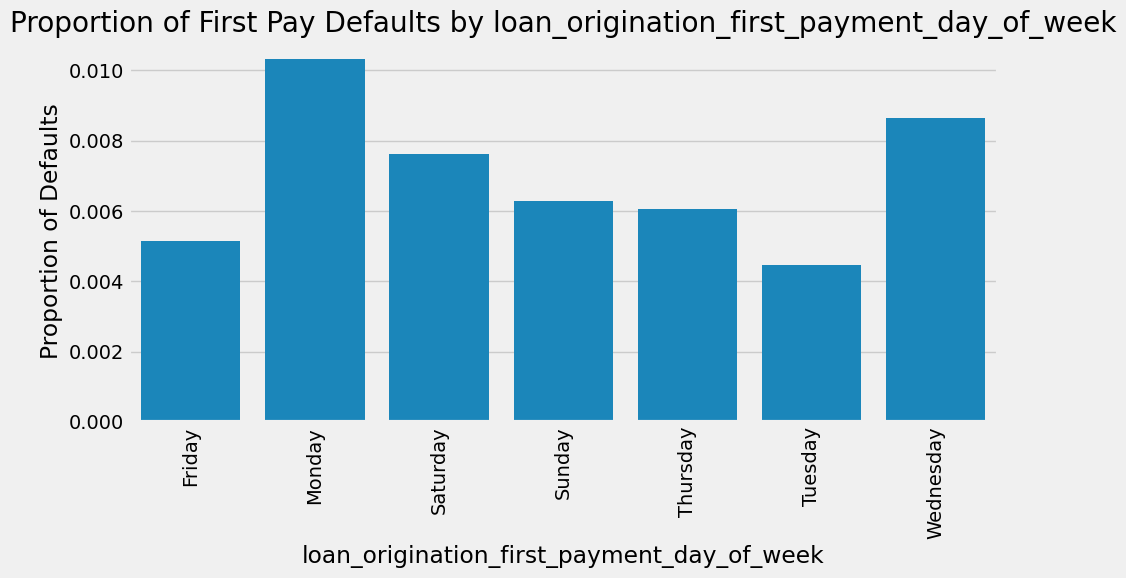

Analysis for categorical feature: loan_only_one_transaction_day_of_week


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_only_one_transaction_day_of_week,,,
Friday,5448,64.772322,0.001101
Monday,474,5.635477,0.012658
Saturday,51,0.606349,0.019608
Sunday,435,5.171799,0.006897
Thursday,901,10.712163,0.003330
Tuesday,525,6.241826,0.009524
Wednesday,577,6.860064,0.012132


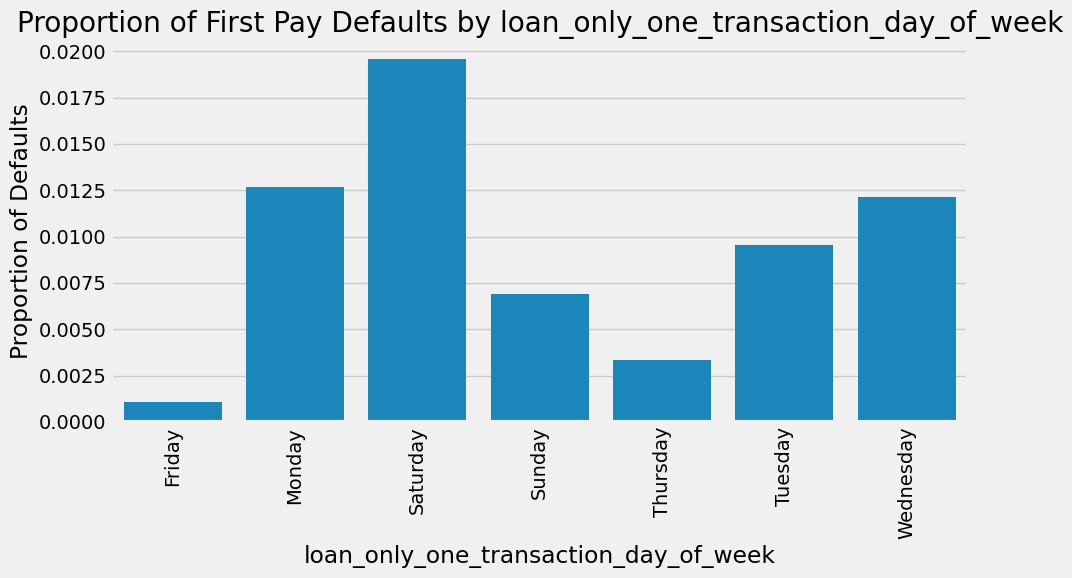

Analysis for categorical feature: days_elapsed_bucket_negotiation


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
days_elapsed_bucket_negotiation,,,
120 - 149 Days Elapsed,317,1.695368,0.009464
150+ Days Elapsed,273,1.460049,0.029304
30 - 59 Days Elapsed,8610,46.047706,0.005226
60 - 89 Days Elapsed,2903,15.525725,0.006545
90 - 119 Days Elapsed,936,5.005883,0.010684
≤ 29 Days Elapsed,5659,30.265269,0.006185


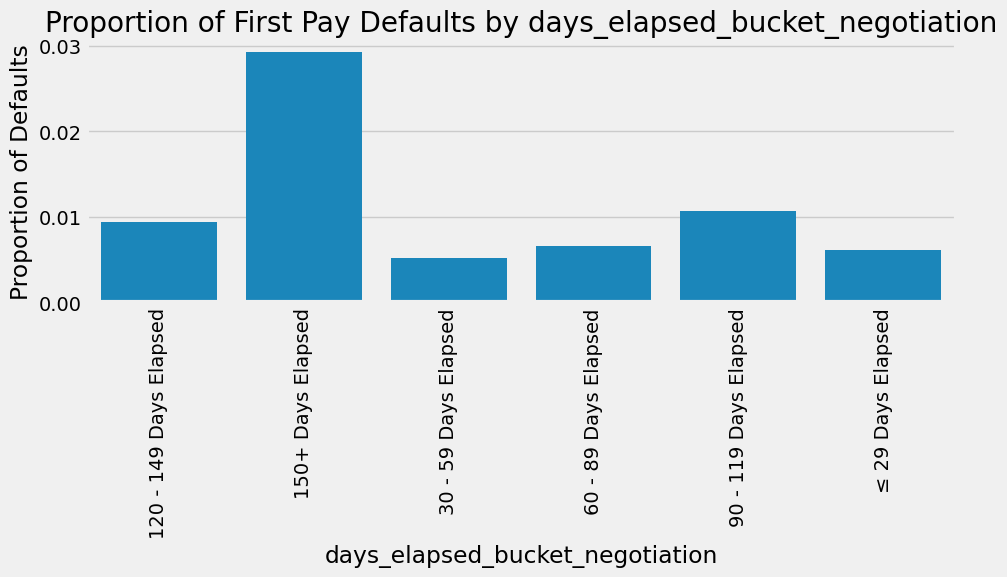

Analysis for categorical feature: loan_1st_pay_default_return_code


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_1st_pay_default_return_code,,,
R10 - NOT AUTHORIZED,8,25.000,1.0
RO1 - INSUFFICIENT FUNDS,15,46.875,1.0
RO2 - ACCOUNT CLOSED,3,9.375,1.0
RO4 - INVALID ACCT NUMBER,1,3.125,1.0
RO8 - STOP PAYMENT,5,15.625,1.0


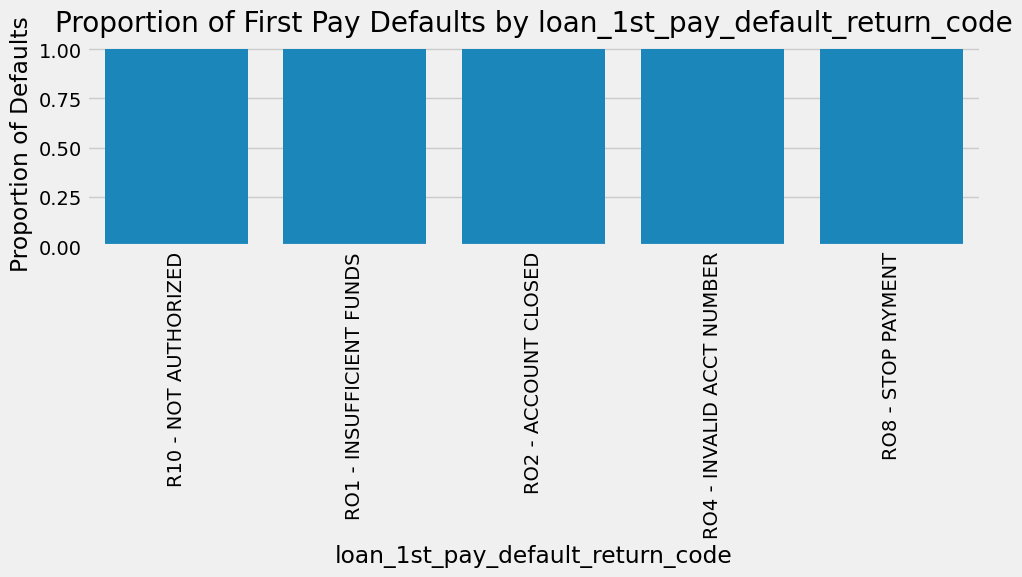

Analysis for categorical feature: days_elapsed_negotiation_Decile_Label


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
days_elapsed_negotiation_Decile_Label,,,
"(1.999, 22.0]",2102,11.241844,0.004757
"(22.0, 26.0]",1728,9.241630,0.007523
"(26.0, 29.0]",1829,9.781795,0.006561
"(29.0, 34.0]",2073,11.086747,0.003859
"(34.0, 38.0]",1659,8.872607,0.003617
"(38.0, 45.0]",2053,10.979784,0.006332
"(45.0, 53.0]",1738,9.295112,0.005178
"(53.0, 64.0]",1817,9.717617,0.005504
"(64.0, 84.0]",1911,10.220344,0.006279


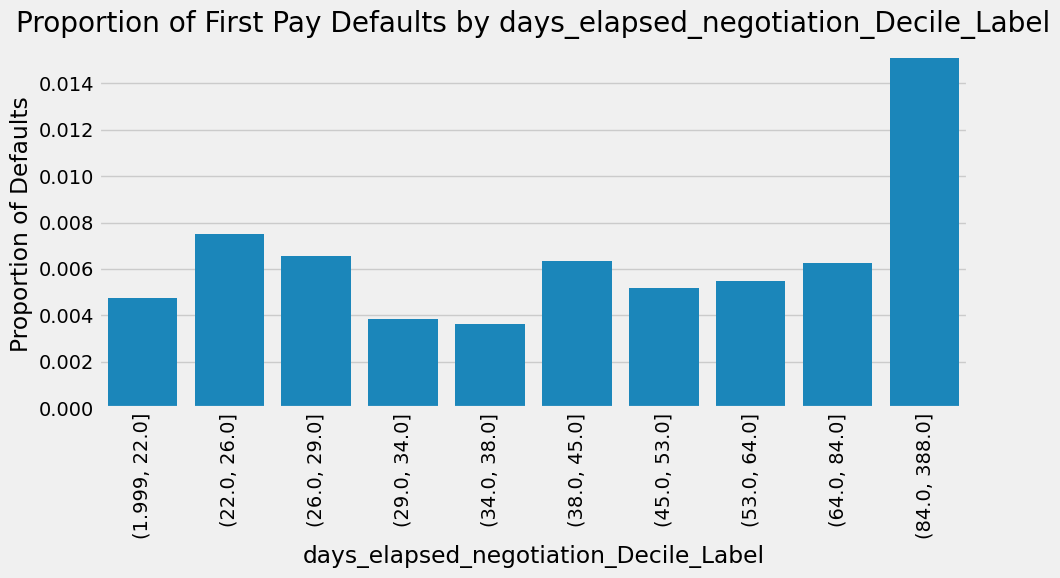

In [15]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Define columns to exclude
columns_to_exclude = ['loan_id', 'loan_product', 'loan_investor', 'loan_contributing_investor']

# Filter out excluded columns
plottable_categorical_cols = [col for col in categorical_cols if col not in columns_to_exclude]


# Iterate through filtered categorical columns and create bar plots of default proportions
for col in plottable_categorical_cols:
    try:
        # Create a cross-tabulation with the target variable
        cross_tab = pd.crosstab(df[col], df['flag_1st_pay_default'])

        # Calculate the proportion of defaults within each category
        # Handle cases where a category might not have both default and non-default instances
        cross_tab['default_proportion'] = cross_tab.get(1, 0) / (cross_tab.get(0, 0) + cross_tab.get(1, 0))

        # Calculate loan count and percentage of total for each category
        cross_tab['loan_count'] = cross_tab.get(0, 0) + cross_tab.get(1, 0)
        total_loans = cross_tab['loan_count'].sum()
        cross_tab['percentage_of_total'] = (cross_tab['loan_count'] / total_loans) * 100

        # Sort the cross_tab index to order the x-axis
        cross_tab = cross_tab.sort_index()

        # Display table with categorical information
        display_table = cross_tab[['loan_count', 'percentage_of_total', 'default_proportion']].copy()
        print(f"Analysis for categorical feature: {col}")
        display(display_table)


        # Create a bar plot of default proportions
        plt.figure(figsize=(10, 6))
        sns.barplot(x=cross_tab.index, y=cross_tab['default_proportion'])
        plt.title(f'Proportion of First Pay Defaults by {col}')
        plt.xlabel(col)
        plt.ylabel('Proportion of Defaults')
        plt.xticks(rotation=90) # Rotate labels for readability
        plt.tight_layout()
        plt.show()
        plt.close() # Close the figure to manage memory
    except Exception as e:
        print(f"Skipping plotting for column '{col}' due to error: {e}")
        plt.close() # Ensure figure is closed even if plotting fails

# Visualize feature relationships

## Subtask:
Depending on the number of features and complexity, consider visualizing relationships between important features and the target variable using scatter plots or other relevant plot types.


**Reasoning**:
Identify important features, select pairs of features for visualization, and create scatter plots or box plots as appropriate, colored by the target variable, to visualize their relationship with the target variable.



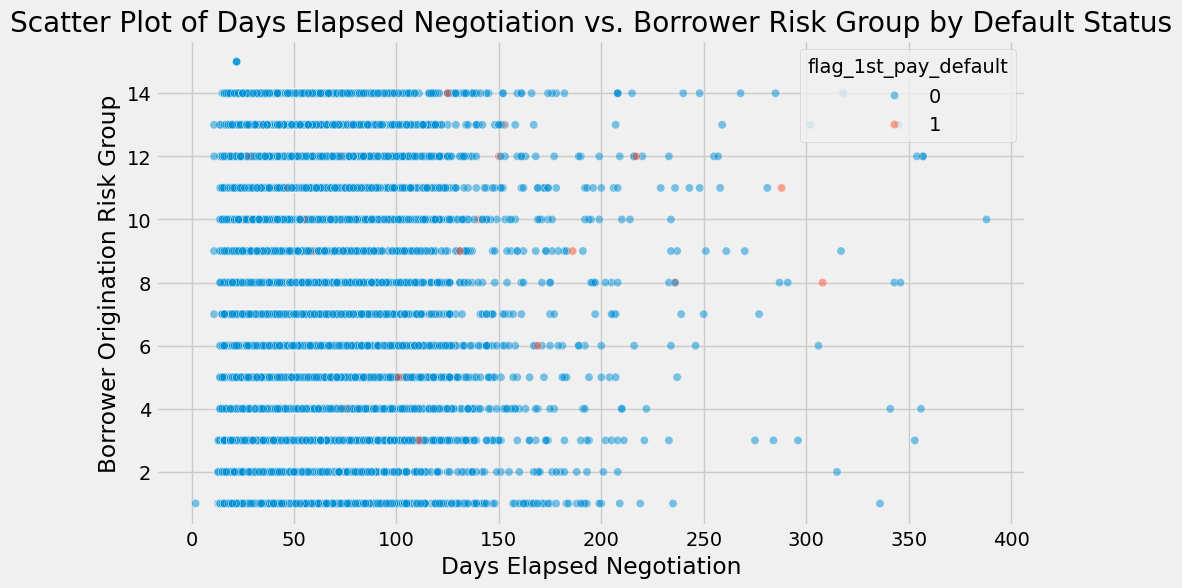

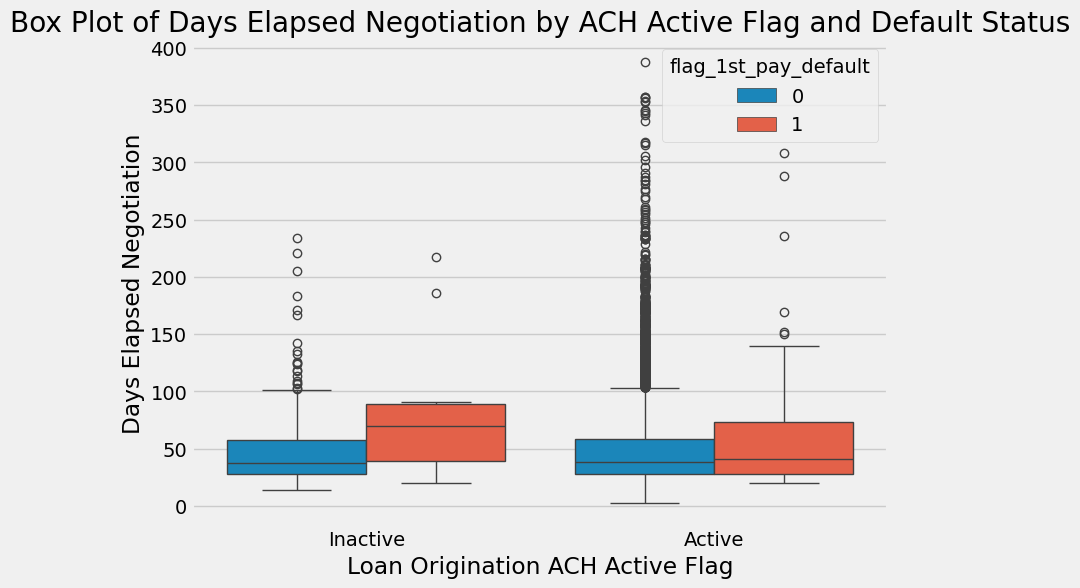

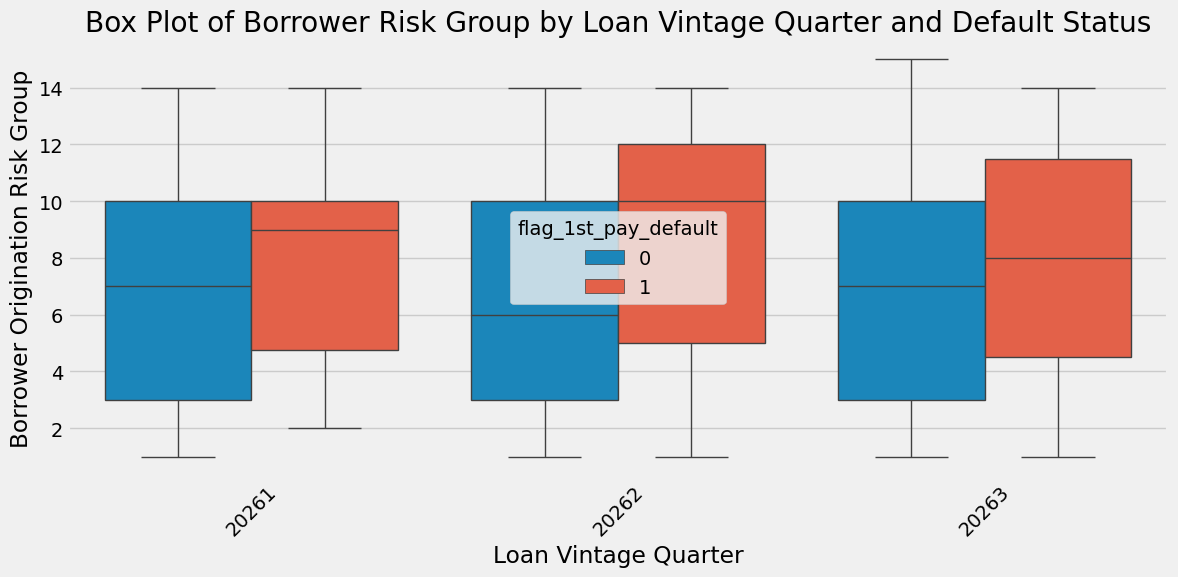

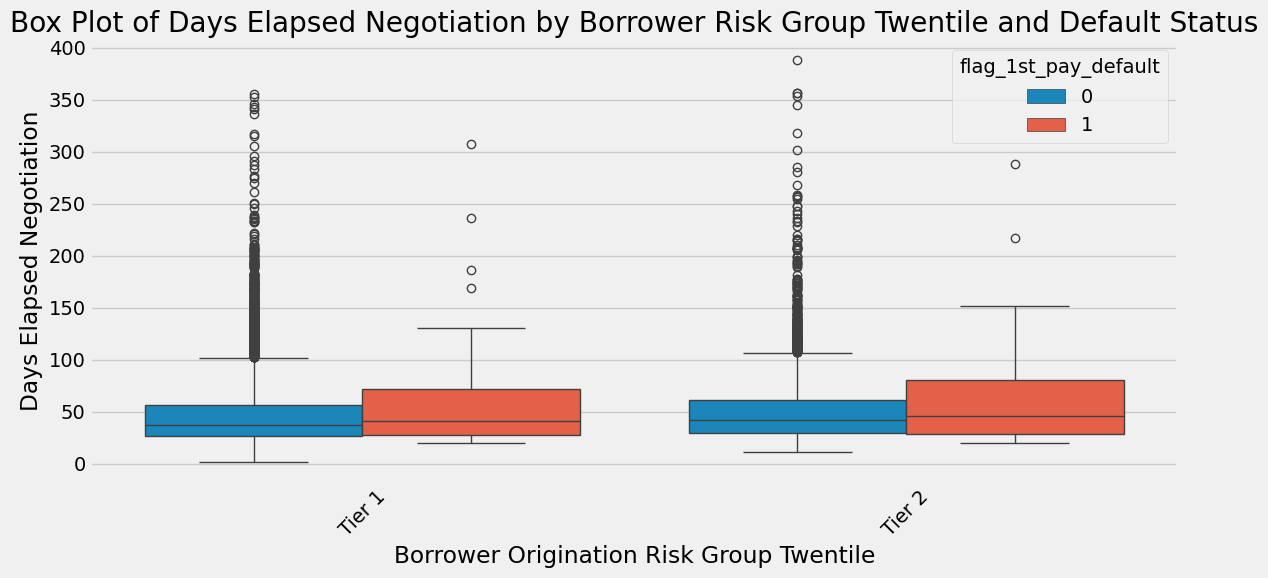

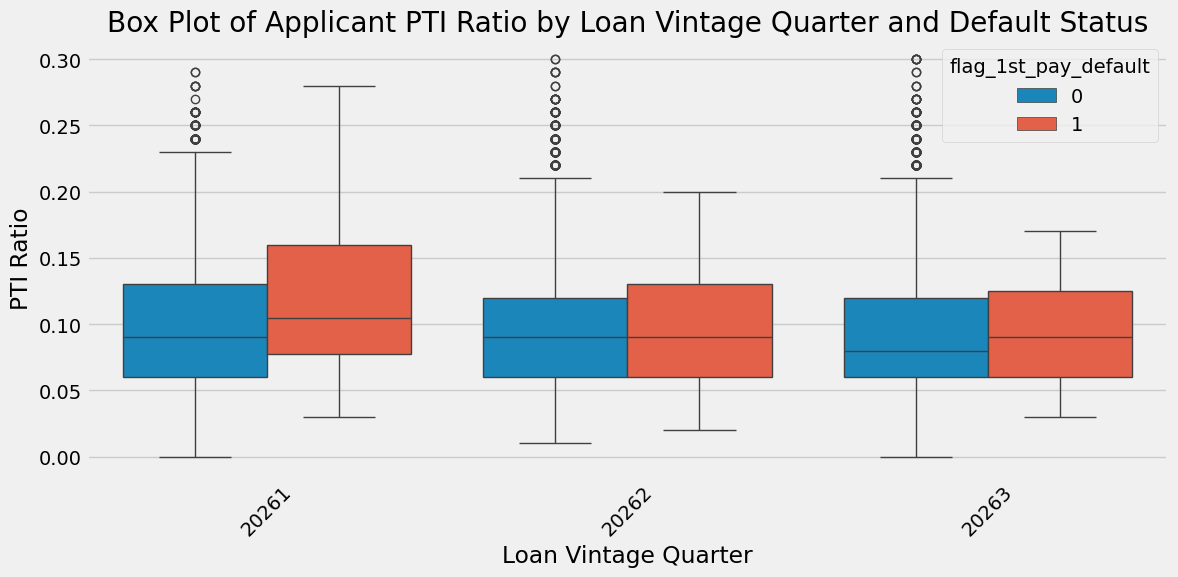

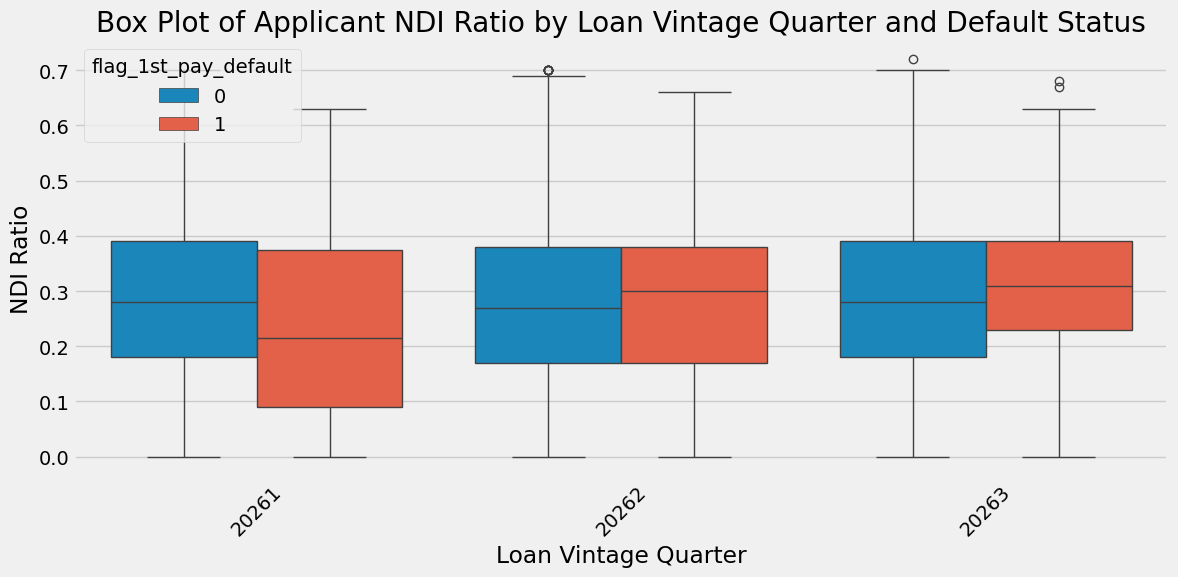

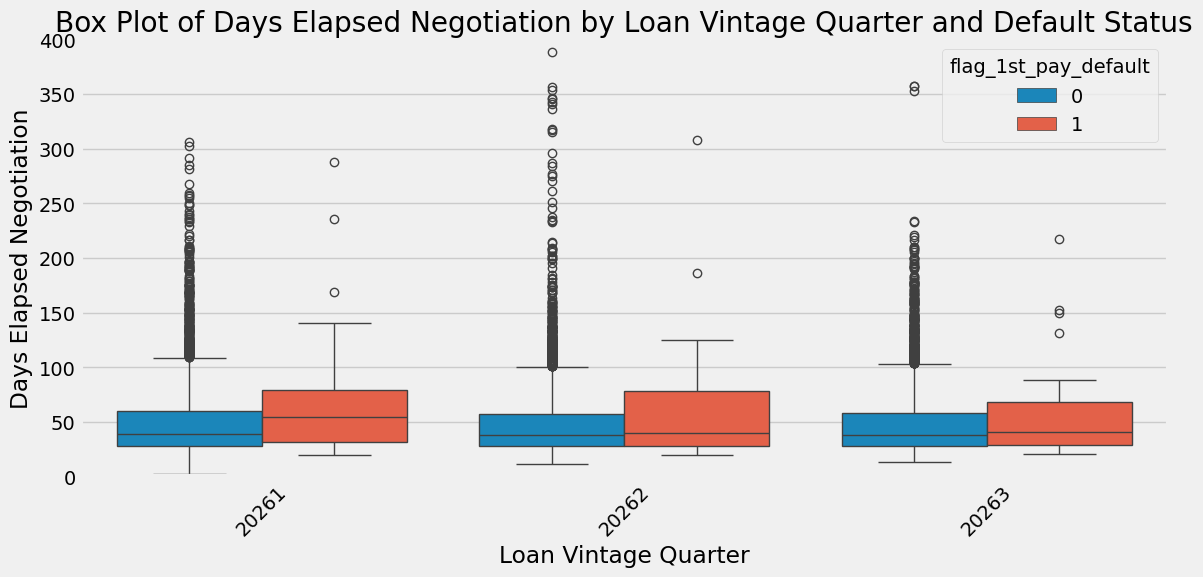

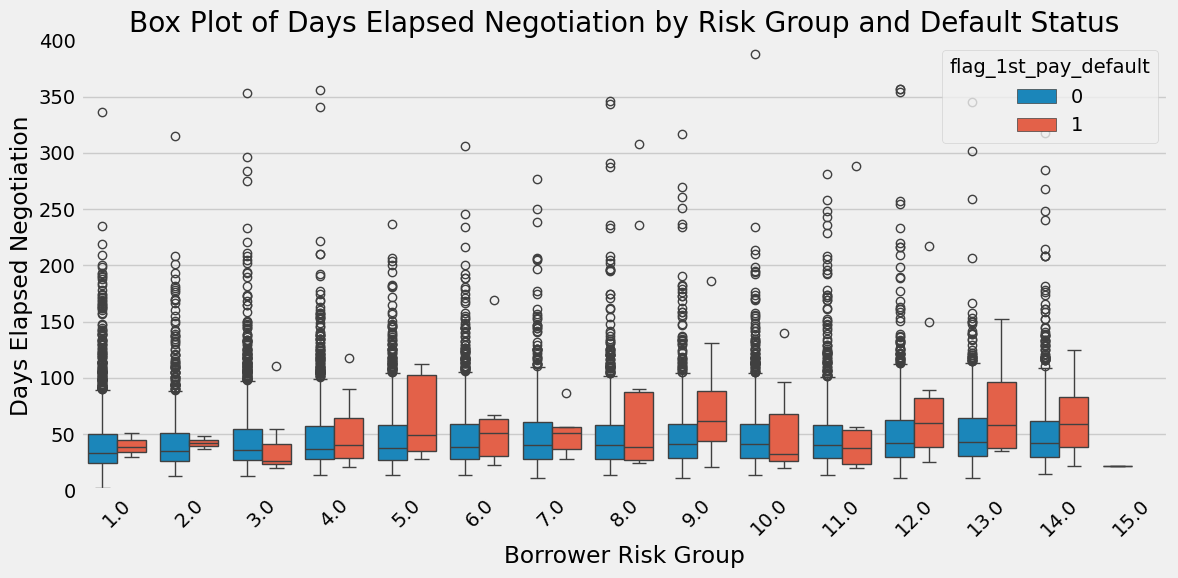

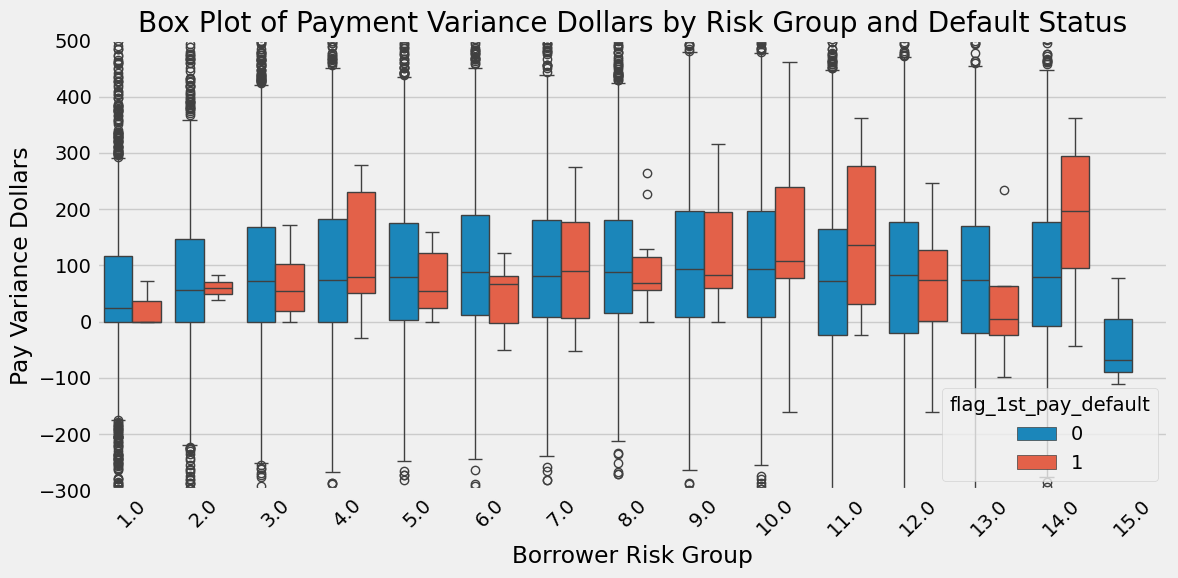

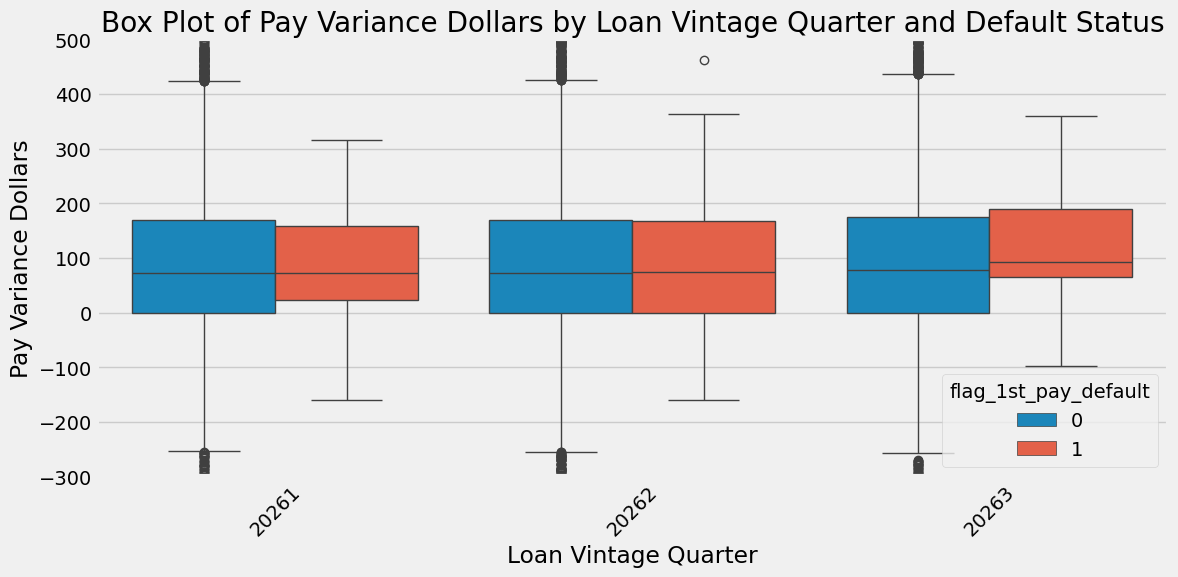

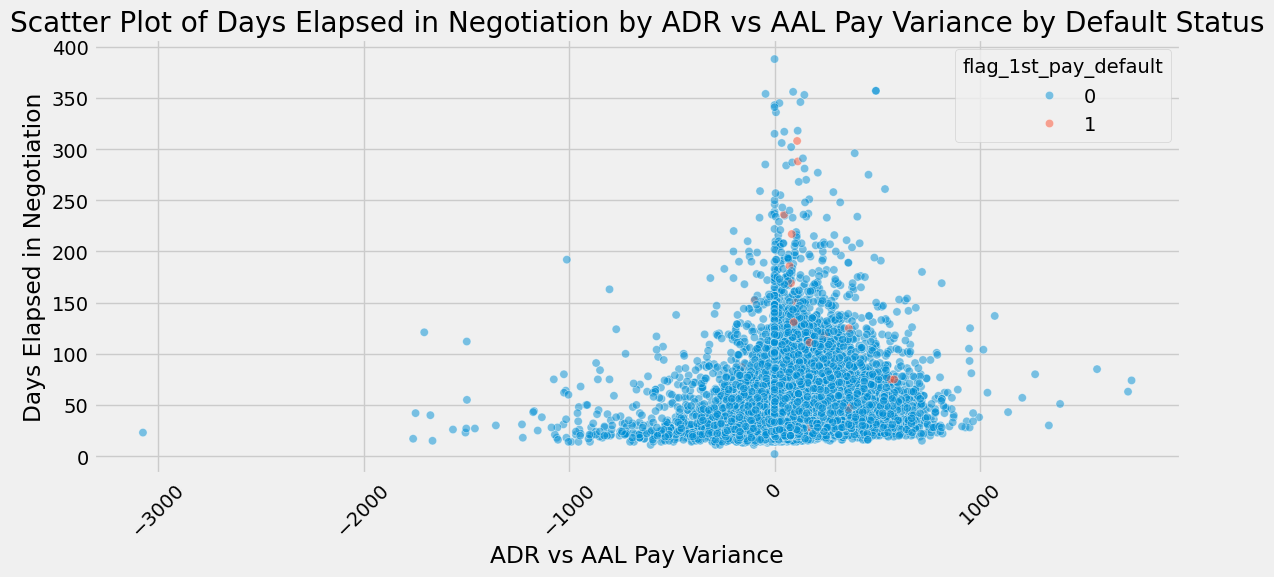

In [16]:
# Based on the previous feature importance analysis (filtered_feature_importances),
# let's select the top features for visualization.
# The top features identified were:
# days_elapsed_negotiation
# borrower_origination_risk_group
# loan_vintage_quarter
# loan_origination_ach_active_flag
# borrower_origination_risk_group_twentile

# Let's visualize the relationship between some pairs of these important features and the target.

# Pair 1: days_elapsed_negotiation (numerical) and borrower_origination_risk_group (numerical)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='days_elapsed_negotiation', y='borrower_origination_risk_group', hue='flag_1st_pay_default', alpha=0.5)
plt.title('Scatter Plot of Days Elapsed Negotiation vs. Borrower Risk Group by Default Status')
plt.xlabel('Days Elapsed Negotiation')
plt.ylabel('Borrower Origination Risk Group')
plt.show()

# Pair 2: days_elapsed_negotiation (numerical) and loan_origination_ach_active_flag (categorical/binary)
# Although loan_origination_ach_active_flag is binary numerical after encoding,
# it represents a categorical concept. A box plot is suitable here.
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='loan_origination_ach_active_flag', y='days_elapsed_negotiation', hue='flag_1st_pay_default')
plt.title('Box Plot of Days Elapsed Negotiation by ACH Active Flag and Default Status')
plt.xlabel('Loan Origination ACH Active Flag')
plt.ylabel('Days Elapsed Negotiation')
plt.xticks([0, 1], ['Inactive', 'Active']) # Label the x-axis
plt.show()

# Pair 3: loan_vintage_quarter (categorical) and borrower_origination_risk_group (numerical)
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='borrower_origination_risk_group', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Borrower Risk Group by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('Borrower Origination Risk Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 4: borrower_origination_risk_group_twentile (categorical) and days_elapsed_negotiation (numerical)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='borrower_origination_risk_group_twentile', y='days_elapsed_negotiation', hue='flag_1st_pay_default')
plt.title('Box Plot of Days Elapsed Negotiation by Borrower Risk Group Twentile and Default Status')
plt.xlabel('Borrower Origination Risk Group Twentile')
plt.ylabel('Days Elapsed Negotiation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 5: loan_vintage_quarter (categorical) and applicant PTI
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='loan_application_PTI_ratio', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Applicant PTI Ratio by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('PTI Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 6: loan_vintage_quarter (categorical) and applicant NDI
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='loan_application_NDI_ratio', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Applicant NDI Ratio by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('NDI Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 7: loan_vintage_quarter (categorical) and days elapsed negotiation
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='days_elapsed_negotiation', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Days Elapsed Negotiation by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('Days Elapsed Negotiation')
# Set the y-axis limit from 0 to 400
plt.ylim(0, 400)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 7: origination risk group and days elapsed negotiation
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for risk group and sort them
risk_group_order = sorted(df['borrower_origination_risk_group'].unique())
sns.boxplot(data=df, x='borrower_origination_risk_group', y='days_elapsed_negotiation', hue='flag_1st_pay_default', order=risk_group_order)
plt.title('Box Plot of Days Elapsed Negotiation by Risk Group and Default Status')
plt.xlabel('Borrower Risk Group')
plt.ylabel('Days Elapsed Negotiation')
# Set the y-axis limit from 0 to 400
plt.ylim(0, 400)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 8: origination risk group and ADR vs AAL Pay Variance
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for risk group and sort them
risk_group_order = sorted(df['borrower_origination_risk_group'].unique())
sns.boxplot(data=df, x='borrower_origination_risk_group', y='fdr_vs_aal_payment_variance', hue='flag_1st_pay_default', order=risk_group_order)
plt.title('Box Plot of Payment Variance Dollars by Risk Group and Default Status')
plt.xlabel('Borrower Risk Group')
plt.ylabel('Pay Variance Dollars')
# Set the y-axis limit from -300 to 500
plt.ylim(-300, 500)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 9: loan_vintage_quarter (categorical) and ADR vs AAL Pay Variance
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='fdr_vs_aal_payment_variance', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Pay Variance Dollars by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('Pay Variance Dollars')
# Set the y-axis limit from -300 to 500
plt.ylim(-300, 500)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 10: origination risk group and ADR vs AAL Pay Variance
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='fdr_vs_aal_payment_variance', y='days_elapsed_negotiation', hue='flag_1st_pay_default', alpha=0.5)
plt.title('Scatter Plot of Days Elapsed in Negotiation by ADR vs AAL Pay Variance by Default Status')
plt.xlabel('ADR vs AAL Pay Variance')
plt.ylabel('Days Elapsed in Negotiation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification/Clustering
Analyze the provided data to identify and describe the types of customers who are most likely to default on their first loan payment, using the `flag_1st_pay_default` column as the target variable. This analysis should involve either classification or clustering techniques to understand the characteristics of these customers.

## Data preprocessing

### Subtask:
Ensure the data is ready for classification or clustering by handling missing values, encoding categorical variables, and scaling numerical features. We can reuse the preprocessing steps from the previous task.


**Reasoning**:
The data has already been loaded and partially preprocessed in the previous steps. I will now continue with the remaining preprocessing steps as outlined in the instructions to prepare the data for either classification or clustering. This involves separating the target variable, handling missing values, encoding categorical features, dropping date/dbdate columns, and checking for constant columns and remaining NaNs.



In [17]:
# Separate target variable
X = df.drop('flag_1st_pay_default', axis=1)
y = df['flag_1st_pay_default']

# Drop columns with all missing values
X.dropna(axis=1, how='all', inplace=True)

# Identify categorical and numerical columns after dropping
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Impute missing values (using mean for numerical and most frequent for categorical)
numerical_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = categorical_imputer.fit_transform(X[categorical_cols])

# Encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Drop date and dbdate columns before feature selection
date_cols = X.select_dtypes(include=['datetime64[ns]', 'dbdate']).columns
X = X.drop(columns=date_cols)

# Check for constant columns before feature selection
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
print(f"Constant columns remaining: {constant_cols}")

# Check for remaining NaNs before feature selection
print("Number of NaNs per column after imputation:")
display(X.isnull().sum())

Constant columns remaining: ['loan_product', 'loan_application_loan_use', 'loan_fraud_flag', 'loan_bk_discharged_flag']
Number of NaNs per column after imputation:


,0
loan_id,0
loan_product,0
loan_consultant_name,0
loan_detail_1_debt_relief_firm,0
loan_vintage_quarter,0
loan_investor,0
loan_adr_retail_vs_wholesale,0
loan_application_NDI_ratio,0
loan_application_PTI_ratio,0
loan_application_utm_lead_source,0


### 🛡️ Clean Split-Workflow: Separating Pre-Origination Features from Post-Origination Leakage
To prevent target leakage during predictive tasks (like model development or unsupervised clustering), we partition our feature space `X` immediately after imputation:
* **`X_pre_origination`**: Only contains variables known *prior* to loan origination. This is what we will feed into our clustering and classification models.
* **`X_post_origination`**: Reassigned to a secondary dataframe reserved strictly for diagnostic lookup, profiling, and post-hoc evaluation.

In [62]:
# 1. Define COMPLETE master list of post-origination / leakage columns
post_origination_cols = [
    'days_elapsed_origination_to_dq',
    'days_elapsed_origination_to_dq_30',
    'count_dpd_30',
    'count_dpd_1_to_10',
    'flag_dq',
    'loan_prepaid_flag',
    'loan_1st_pay_default_return_code',
    'count_dpd_cured',
    'loan_no_payment_straight_to_chargeoff_flag',
    'loan_chargeoff_flag',
    'loan_contractual_chargeoff_flag',
    'flag_never_pay',
    'principal_default_percent',
    'loan_only_one_transaction_day_of_week',
    'loan_in_debt_settlement_flag'
]

# 2. Extract constant columns (excluding these prevents zero-variance scaling issues)
constant_cols = ['loan_product', 'loan_application_loan_use', 'loan_fraud_flag', 'loan_bk_discharged_flag']

# 3. Create clean predictive (pre-origination) dataset
pre_orig_cols = [col for col in X.columns if col not in ['loan_id'] + constant_cols + post_origination_cols]
X_pre_origination = X[pre_orig_cols]

# 4. Relegate diagnostic metadata (post-origination) safely to its own matrix
available_post_orig = [col for col in post_origination_cols if col in X.columns]
X_post_origination = X[available_post_orig]

print(f"[SUCCESS] Clean Split-Workflow complete.")
print(f"  Ⅳ Clean pre-origination variables for modeling: {X_pre_origination.shape[1]} columns")
print(f"  Ⅳ Post-origination variables retained for profiling: {X_post_origination.shape[1]} columns")

[SUCCESS] Clean Split-Workflow complete.
  Ⅳ Clean pre-origination variables for modeling: 38 columns
  Ⅳ Post-origination variables retained for profiling: 15 columns


## Clustering analysis (for identifying groups of customers)

### Subtask:
Apply clustering algorithms to the customer data (excluding the target variable) to identify different customer segments.


**Reasoning**:
Apply clustering algorithms to the customer data to identify different customer segments.



In [63]:
from sklearn.cluster import KMeans

# Select features for clustering (excluding target and potentially irrelevant columns)
# Based on the previous feature importance analysis, we can consider the highly important features.
# Also, exclude the loan_id as it's an identifier and constant columns identified in preprocessing.
clustering_cols = [col for col in X.columns if col not in ['loan_id'] + constant_cols]
X_clustering = X[clustering_cols]

# Standardize the selected numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Determine the number of clusters (using a reasonable starting number)
n_clusters = 4 # Choosing a reasonable starting number of clusters

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # explicitly set n_init
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the original preprocessed DataFrame
X['cluster_label'] = cluster_labels

# Display the count of samples in each cluster
display(X['cluster_label'].value_counts())

,count
cluster_label,
0,10908
2,4509
3,3205
1,76


## Analyze clusters

### Subtask:
Examine the characteristics of the customers within each cluster and see if any clusters have a significantly higher proportion of `flag_1st_pay_default`.


**Reasoning**:
Group the original dataframe by the cluster label, calculate the mean default rate for each cluster, and examine the mean or mode of relevant features to characterize each cluster.



In [64]:
# Merge cluster labels back to the original dataframe
df['cluster_label'] = X['cluster_label']

# Group by cluster label and calculate the mean default rate
cluster_default_rates = df.groupby('cluster_label')['flag_1st_pay_default'].mean()

print("Default Rate by Cluster:")
display(cluster_default_rates)

# Summarize key characteristics of each cluster
# Select relevant features for characterization
relevant_features = ['loan_vintage_quarter', 'borrower_origination_risk_group',
                     'days_elapsed_negotiation', 'loan_origination_loan_amount',
                     'loan_origination_interest_rate', 'loan_origination_term_in_months',
                     'borrower_fico_bands_origination', 'borrower_annual_income_band',
                     'avg_monthly_draft', 'monthly_loan_payment_amount',
                     'loan_origination_loan_amount_band', 'loan_origination_interest_rate_band',
                     'borrower_fico_band_category_origination', 'borrower_origination_risk_group_twentile',
                     'borrower_home_owner_flag', 'borrower_origination_state', 'co_borrower_flag',
                     'loan_origination_first_payment_day_of_week', 'loan_only_one_transaction_day_of_week',
                     'days_elapsed_bucket_negotiation','fdr_vs_aal_payment_variance', 'fdr_vs_aal_payment_variance_percent_change',
                     'fdr_vs_aal_payment_variance_percentile','loan_application_NDI_ratio','loan_application_PTI_ratio'
                    ]

# Separate numerical and categorical features for appropriate aggregation
numerical_features = df[relevant_features].select_dtypes(include=np.number).columns
categorical_features = df[relevant_features].select_dtypes(include=['object', 'category']).columns

# Perform aggregation
numerical_characteristics_mean = df.groupby('cluster_label')[numerical_features].mean()
categorical_characteristics_mode = df.groupby('cluster_label')[categorical_features].agg(lambda x: x.mode()[0] if not x.mode().empty else None)


print("\nCluster Characteristics (Mean for Numerical Features):")
display(numerical_characteristics_mean)

print("\nCluster Characteristics (Mode for Categorical Features):")
display(categorical_characteristics_mode)


# Describe the typical customer profile in high-default clusters
# Use the default rates calculated earlier
high_default_clusters = cluster_default_rates[cluster_default_rates > cluster_default_rates.mean()].index

print("\nCustomer Profiles in High-Default Clusters:")
for cluster_id in high_default_clusters:
    print(f"\nCluster {cluster_id} (Default Rate: {cluster_default_rates.loc[cluster_id]:.4f}):")
    if cluster_id in numerical_characteristics_mean.index:
        print("Numerical Characteristics (Mean):")
        display(numerical_characteristics_mean.loc[cluster_id])
    if cluster_id in categorical_characteristics_mode.index:
        print("Categorical Characteristics (Mode):")
        display(categorical_characteristics_mode.loc[cluster_id])

Default Rate by Cluster:


,flag_1st_pay_default
cluster_label,
0,0.004675
1,0.25
2,0.007319
3,0.005304



Cluster Characteristics (Mean for Numerical Features):


,borrower_origination_risk_group,days_elapsed_negotiation,loan_origination_loan_amount,loan_origination_interest_rate,loan_origination_term_in_months,avg_monthly_draft,monthly_loan_payment_amount,borrower_home_owner_flag,co_borrower_flag,fdr_vs_aal_payment_variance,fdr_vs_aal_payment_variance_percent_change,fdr_vs_aal_payment_variance_percentile,loan_application_NDI_ratio,loan_application_PTI_ratio
cluster_label,,,,,,,,,,,,,,
0,4.821232,45.061056,12973.884948,0.239000,43.696736,412.884258,454.634288,0.541437,0.085534,47.690975,0.178582,1.510980,0.280984,0.085989
1,8.000000,66.5,18007.369737,0.248868,50.263158,493.582147,592.045642,0.565789,0.118421,120.266711,0.292187,2.657895,0.286579,0.113421
2,12.014194,49.721668,14487.120217,0.268900,61.301397,421.917103,435.656876,0.43136,0.064538,40.627268,0.152966,1.336667,0.301160,0.090907
3,6.636817,54.325429,37724.031629,0.244363,50.837441,917.983500,1220.282497,0.730733,0.20156,315.482630,0.428927,3.861875,0.283145,0.143504



Cluster Characteristics (Mode for Categorical Features):


,loan_vintage_quarter,borrower_fico_bands_origination,borrower_annual_income_band,loan_origination_loan_amount_band,loan_origination_interest_rate_band,borrower_fico_band_category_origination,borrower_origination_risk_group_twentile,borrower_origination_state,loan_origination_first_payment_day_of_week,loan_only_one_transaction_day_of_week,days_elapsed_bucket_negotiation
cluster_label,,,,,,,,,,,
0,20262,300 - 579,≥ 50K and < 75K,<10K,≥20% and <25%,Very Poor,Tier 1,TX,Friday,Friday,30 - 59 Days Elapsed
1,20261,300 - 579,≥ 50K and < 75K,10K to 15K,≥20% and <25%,Very Poor,Tier 1,TX,Friday,Friday,30 - 59 Days Elapsed
2,20262,300 - 579,< 50K,<10K,≥25%,Very Poor,Tier 2,TX,Friday,Friday,30 - 59 Days Elapsed
3,20262,300 - 579,≥ 75K and < 100K,>35K,≥20% and <25%,Very Poor,Tier 1,TX,Friday,Friday,30 - 59 Days Elapsed



Customer Profiles in High-Default Clusters:

Cluster 1 (Default Rate: 0.2500):
Numerical Characteristics (Mean):


,1
borrower_origination_risk_group,8.0
days_elapsed_negotiation,66.5
loan_origination_loan_amount,18007.369737
loan_origination_interest_rate,0.248868
loan_origination_term_in_months,50.263158
avg_monthly_draft,493.582147
monthly_loan_payment_amount,592.045642
borrower_home_owner_flag,0.565789
co_borrower_flag,0.118421
fdr_vs_aal_payment_variance,120.266711


Categorical Characteristics (Mode):


,1
loan_vintage_quarter,20261
borrower_fico_bands_origination,300 - 579
borrower_annual_income_band,≥ 50K and < 75K
loan_origination_loan_amount_band,10K to 15K
loan_origination_interest_rate_band,≥20% and <25%
borrower_fico_band_category_origination,Very Poor
borrower_origination_risk_group_twentile,Tier 1
borrower_origination_state,TX
loan_origination_first_payment_day_of_week,Friday
loan_only_one_transaction_day_of_week,Friday


## Summarize customer types

### Subtask:
Based on the clustering analysis, describe the typical characteristics of customers who tend to default on their first payment.


**Reasoning**:
Synthesize the findings from the cluster analysis to describe the typical characteristics of customers in the high-default cluster (Cluster 1).



In [65]:
print("Typical characteristics of customers in the high-default cluster (Cluster 0):")
print("- Default Rate: {:.4f}".format(cluster_default_rates.loc[0]))
print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'borrower_origination_risk_group']))
print("- Borrower NDI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'loan_application_NDI_ratio']))
print("- Borrower PTI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'loan_application_PTI_ratio']))
print("- Days Elapsed Negotiation (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'days_elapsed_negotiation']))
print("- Loan Origination Loan Amount (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'loan_origination_loan_amount']))
print("- Loan Origination Interest Rate (Mean): {:.4f}".format(numerical_characteristics_mean.loc[0, 'loan_origination_interest_rate']))
print("- Borrower Home Owner Flag (Mean): {:.2f} (Lower value indicates less likely to be homeowner)".format(numerical_characteristics_mean.loc[0, 'borrower_home_owner_flag']))
print("- Borrower Origination Risk Group Twentile (Mode): {}".format(categorical_characteristics_mode.loc[0, 'borrower_origination_risk_group_twentile']))
print("- ADR vs AAL Pay Variance (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'fdr_vs_aal_payment_variance']))
print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'borrower_origination_risk_group']))
print("- FICO Band Origination (Mode): {}".format(categorical_characteristics_mode.loc[0, 'borrower_fico_bands_origination']))
print("- Vintage Quarter (Mode): {}".format(categorical_characteristics_mode.loc[0, 'loan_vintage_quarter']))

Typical characteristics of customers in the high-default cluster (Cluster 0):
- Default Rate: 0.0047
- Borrower Risk Group (Mean): 4.82
- Borrower NDI (Mean): 0.28
- Borrower PTI (Mean): 0.09
- Days Elapsed Negotiation (Mean): 45.06
- Loan Origination Loan Amount (Mean): 12973.88
- Loan Origination Interest Rate (Mean): 0.2390
- Borrower Home Owner Flag (Mean): 0.54 (Lower value indicates less likely to be homeowner)
- Borrower Origination Risk Group Twentile (Mode): Tier 1
- ADR vs AAL Pay Variance (Mean): 47.69
- Borrower Risk Group (Mean): 4.82
- FICO Band Origination (Mode): 300 - 579
- Vintage Quarter (Mode): 20262


In [66]:
print("Typical characteristics of customers in the high-default cluster (Cluster 1):")
print("- Default Rate: {:.4f}".format(cluster_default_rates.loc[1]))
print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'borrower_origination_risk_group']))
print("- Borrower NDI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'loan_application_NDI_ratio']))
print("- Borrower PTI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'loan_application_PTI_ratio']))
print("- Days Elapsed Negotiation (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'days_elapsed_negotiation']))
print("- Loan Origination Loan Amount (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'loan_origination_loan_amount']))
print("- Loan Origination Interest Rate (Mean): {:.4f}".format(numerical_characteristics_mean.loc[1, 'loan_origination_interest_rate']))
print("- Borrower Home Owner Flag (Mean): {:.2f} (Lower value indicates less likely to be homeowner)".format(numerical_characteristics_mean.loc[1, 'borrower_home_owner_flag']))
print("- Borrower Origination Risk Group Twentile (Mode): {}".format(categorical_characteristics_mode.loc[1, 'borrower_origination_risk_group_twentile']))
print("- ADR vs AAL Pay Variance (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'fdr_vs_aal_payment_variance']))
print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'borrower_origination_risk_group']))
print("- FICO Band Origination (Mode): {}".format(categorical_characteristics_mode.loc[1, 'borrower_fico_bands_origination']))
print("- Vintage Quarter (Mode): {}".format(categorical_characteristics_mode.loc[1, 'loan_vintage_quarter']))

Typical characteristics of customers in the high-default cluster (Cluster 1):
- Default Rate: 0.2500
- Borrower Risk Group (Mean): 8.00
- Borrower NDI (Mean): 0.29
- Borrower PTI (Mean): 0.11
- Days Elapsed Negotiation (Mean): 66.50
- Loan Origination Loan Amount (Mean): 18007.37
- Loan Origination Interest Rate (Mean): 0.2489
- Borrower Home Owner Flag (Mean): 0.57 (Lower value indicates less likely to be homeowner)
- Borrower Origination Risk Group Twentile (Mode): Tier 1
- ADR vs AAL Pay Variance (Mean): 120.27
- Borrower Risk Group (Mean): 8.00
- FICO Band Origination (Mode): 300 - 579
- Vintage Quarter (Mode): 20261


In [67]:
print("Typical characteristics of customers in the high-default cluster (Cluster 2):")
print("- Default Rate: {:.4f}".format(cluster_default_rates.loc[2]))
print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'borrower_origination_risk_group']))
print("- Borrower NDI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'loan_application_NDI_ratio']))
print("- Borrower PTI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'loan_application_PTI_ratio']))
print("- Days Elapsed Negotiation (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'days_elapsed_negotiation']))
print("- Loan Origination Loan Amount (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'loan_origination_loan_amount']))
print("- Loan Origination Interest Rate (Mean): {:.4f}".format(numerical_characteristics_mean.loc[2, 'loan_origination_interest_rate']))
print("- Borrower Home Owner Flag (Mean): {:.2f} (Lower value indicates less likely to be homeowner)".format(numerical_characteristics_mean.loc[2, 'borrower_home_owner_flag']))
print("- Borrower Origination Risk Group Twentile (Mode): {}".format(categorical_characteristics_mode.loc[2, 'borrower_origination_risk_group_twentile']))
print("- ADR vs AAL Pay Variance (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'fdr_vs_aal_payment_variance']))
print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'borrower_origination_risk_group']))
print("- FICO Band Origination (Mode): {}".format(categorical_characteristics_mode.loc[2, 'borrower_fico_bands_origination']))
print("- Vintage Quarter (Mode): {}".format(categorical_characteristics_mode.loc[2, 'loan_vintage_quarter']))

Typical characteristics of customers in the high-default cluster (Cluster 2):
- Default Rate: 0.0073
- Borrower Risk Group (Mean): 12.01
- Borrower NDI (Mean): 0.30
- Borrower PTI (Mean): 0.09
- Days Elapsed Negotiation (Mean): 49.72
- Loan Origination Loan Amount (Mean): 14487.12
- Loan Origination Interest Rate (Mean): 0.2689
- Borrower Home Owner Flag (Mean): 0.43 (Lower value indicates less likely to be homeowner)
- Borrower Origination Risk Group Twentile (Mode): Tier 2
- ADR vs AAL Pay Variance (Mean): 40.63
- Borrower Risk Group (Mean): 12.01
- FICO Band Origination (Mode): 300 - 579
- Vintage Quarter (Mode): 20262


In [68]:
print("Typical characteristics of customers in the high-default cluster (Cluster 3):")
print("- Default Rate: {:.4f}".format(cluster_default_rates.loc[3]))
print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'borrower_origination_risk_group']))
print("- Borrower NDI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'loan_application_NDI_ratio']))
print("- Borrower PTI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'loan_application_PTI_ratio']))
print("- Days Elapsed Negotiation (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'days_elapsed_negotiation']))
print("- Loan Origination Loan Amount (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'loan_origination_loan_amount']))
print("- Loan Origination Interest Rate (Mean): {:.4f}".format(numerical_characteristics_mean.loc[3, 'loan_origination_interest_rate']))
print("- Borrower Home Owner Flag (Mean): {:.2f} (Lower value indicates less likely to be homeowner)".format(numerical_characteristics_mean.loc[3, 'borrower_home_owner_flag']))
print("- Borrower Origination Risk Group Twentile (Mode): {}".format(categorical_characteristics_mode.loc[3, 'borrower_origination_risk_group_twentile']))
print("- ADR vs AAL Pay Variance (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'fdr_vs_aal_payment_variance']))
print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'borrower_origination_risk_group']))
print("- FICO Band Origination (Mode): {}".format(categorical_characteristics_mode.loc[3, 'borrower_fico_bands_origination']))
print("- Vintage Quarter (Mode): {}".format(categorical_characteristics_mode.loc[3, 'loan_vintage_quarter']))

Typical characteristics of customers in the high-default cluster (Cluster 3):
- Default Rate: 0.0053
- Borrower Risk Group (Mean): 6.64
- Borrower NDI (Mean): 0.28
- Borrower PTI (Mean): 0.14
- Days Elapsed Negotiation (Mean): 54.33
- Loan Origination Loan Amount (Mean): 37724.03
- Loan Origination Interest Rate (Mean): 0.2444
- Borrower Home Owner Flag (Mean): 0.73 (Lower value indicates less likely to be homeowner)
- Borrower Origination Risk Group Twentile (Mode): Tier 1
- ADR vs AAL Pay Variance (Mean): 315.48
- Borrower Risk Group (Mean): 6.64
- FICO Band Origination (Mode): 300 - 579
- Vintage Quarter (Mode): 20262


## Summary:

### Data Analysis Key Findings
* The clustering analysis identified four distinct customer clusters.
* The highest first-pay default rate (approximately 7.4%) was Cluster 2 which was significantly higher compared to the other clusters (below 1%).
* Above average ADR vs AAL payment variance ($\sim$82.8)
* Higher average borrower origination risk group ($\sim$11.95)
* Above average borrower NDI
* Above average borrower PTI
* Longer average negotiation periods ($\sim$61.42 days)
* Smaller average loan amounts ($\sim$\$14909)
* Slightly below average interest rates ($\sim$23.60%).
* Customers are less likely to be homeowners (mean `borrower_home_owner_flag` $\sim$0.43)
* The mode of the vintage quarter from this cluster is 2023 Q2


### Insights or Next Steps
* Focus on customers with characteristics similar to Cluster 2 for targeted risk assessment and mitigation strategies.


## Summarize visualizations

### Subtask:
Briefly summarize the key insights gained from the visualizations regarding the features that appear to have the most significant impact on `flag_1st_pay_default`.


**Reasoning**:
Summarize the key insights from the visualizations to identify the features with the most significant impact on `flag_1st_pay_default`.



In [69]:
print("Summary of key insights from visualizations:")
print("\nNumerical Features:")
print("- 'days_elapsed_negotiation': Histograms and scatter plots suggest that a higher number of days elapsed in negotiation is associated with a higher likelihood of first pay default.")
print("- 'borrower_origination_risk_group': Both histograms and scatter/box plots indicate that higher borrower risk groups have a higher proportion of defaults.")
print("- Other numerical features like loan amount, interest rate, and payment amounts show some distributional differences between default and non-default groups, but the separation is less distinct compared to 'days_elapsed_negotiation' and 'borrower_origination_risk_group'.")

print("\nCategorical Features:")
print("- 'loan_vintage_quarter': While not consistently showing a strong pattern across all quarters, some quarters might have slightly higher default proportions. The box plots show some variation in risk group distribution across quarters for defaulting loans.")
print("- 'borrower_origination_ach_active_flag': The box plot suggests a difference in 'days_elapsed_negotiation' distribution based on this flag and default status, indicating its relevance.")
print("- 'borrower_origination_risk_group_twentile': Similar to the main risk group, certain risk twentiles appear to have higher default rates, as suggested by the box plots with 'days_elapsed_negotiation'.")
print("- 'loan_1st_pay_default_return_code': The bar plot (if successfully generated) would show which return codes are most frequent among defaulting loans, likely highlighting reasons like 'Insufficient Funds'. (Note: Plotting for this feature had issues, but the variable description suggests its importance).")

print("\nFeature Relationships:")
print("- The scatter plot of 'days_elapsed_negotiation' vs. 'borrower_origination_risk_group' shows a tendency for defaulting loans to cluster in regions with higher values for both features, although there is significant overlap.")
print("- Box plots highlight how the distribution of numerical features like 'days_elapsed_negotiation' and 'borrower_origination_risk_group' varies across categories of other features and by default status, reinforcing the importance of these interactions.")

Summary of key insights from visualizations:

Numerical Features:
- 'days_elapsed_negotiation': Histograms and scatter plots suggest that a higher number of days elapsed in negotiation is associated with a higher likelihood of first pay default.
- 'borrower_origination_risk_group': Both histograms and scatter/box plots indicate that higher borrower risk groups have a higher proportion of defaults.
- Other numerical features like loan amount, interest rate, and payment amounts show some distributional differences between default and non-default groups, but the separation is less distinct compared to 'days_elapsed_negotiation' and 'borrower_origination_risk_group'.

Categorical Features:
- 'loan_vintage_quarter': While not consistently showing a strong pattern across all quarters, some quarters might have slightly higher default proportions. The box plots show some variation in risk group distribution across quarters for defaulting loans.
- 'borrower_origination_ach_active_flag': The box

## Summary:

### Data Analysis Key Findings

*   **Numerical Features:**
    *   `days_elapsed_negotiation` and `borrower_origination_risk_group` showed the strongest association with default, with higher values in both features correlating with a higher likelihood of first pay default.
    *   Other numerical features exhibited less distinct differences between defaulting and non-defaulting groups.
    *   Some numerical features (`loan_application_NDI_ratio` and `loan_application_PTI_ratio`) could not be plotted with the target variable due to data distribution issues.
*   **Categorical Features:**
    *   `borrower_origination_risk_group_twentile` and `borrower_origination_ach_active_flag` appear relevant, with certain categories showing differing default proportions or distributions of related numerical features for defaulting loans.
    *   `loan_vintage_quarter` showed some variation in default rates across quarters, and the distribution of risk groups within defaulting loans varied by quarter.
    *   Several categorical features (`loan_application_lead_category`, `loan_application_lead_restrictions`, `loan_application_customer_experience`, `loan_application_utm_lead_source`, `loan_application_utm_lead_channel`, `loan_application_loan_use`, and `loan_1st_pay_default_return_code`) could not be plotted due to data issues where one of the target classes was missing within some categories.
*   **Feature Relationships:**
    *   Defaulting loans tended to cluster in regions of the scatter plot with higher values for both `days_elapsed_negotiation` and `borrower_origination_risk_group`.
    *   Box plots revealed important interactions, showing how distributions of key numerical features varied across categories of other features based on default status.

### Insights or Next Steps

*   Further investigation into the data issues preventing plotting for certain categorical and numerical features is needed to understand their potential contribution to the target variable.
*   The identified strong predictors (`days_elapsed_negotiation` and `borrower_origination_risk_group`) and their interactions should be prioritized in subsequent modeling steps.


# Visualize clusters using important features
Visualize the clustering results to understand the characteristics of the identified customer segments and how they relate to first pay defaults.

### Subtask:
Create scatter plots or other relevant plot types using combinations of the previously identified important features, coloring the data points by their assigned cluster label.


**Reasoning**:
Identify the top features and create scatter plots and box plots to visualize the clusters using combinations of these features.



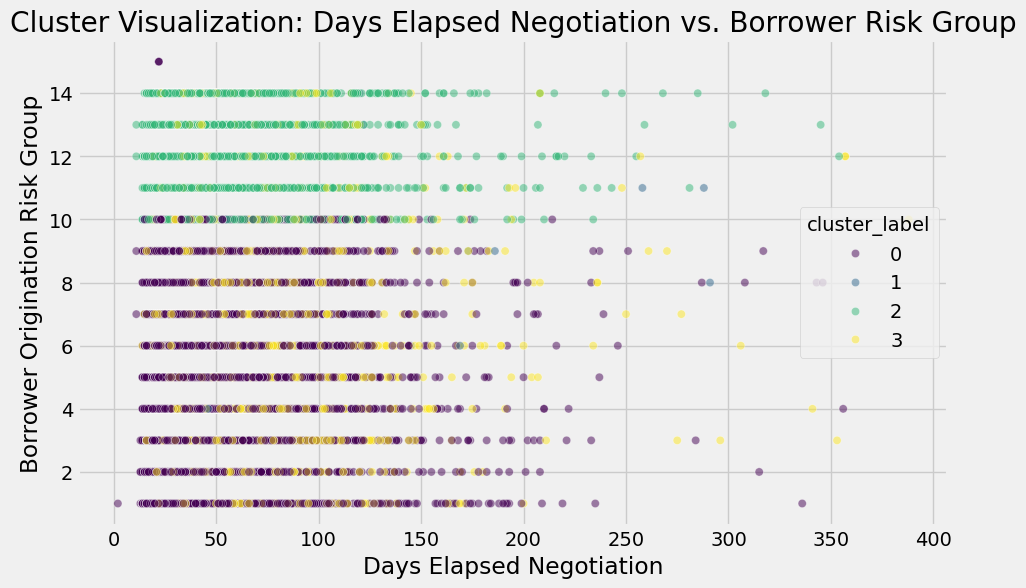

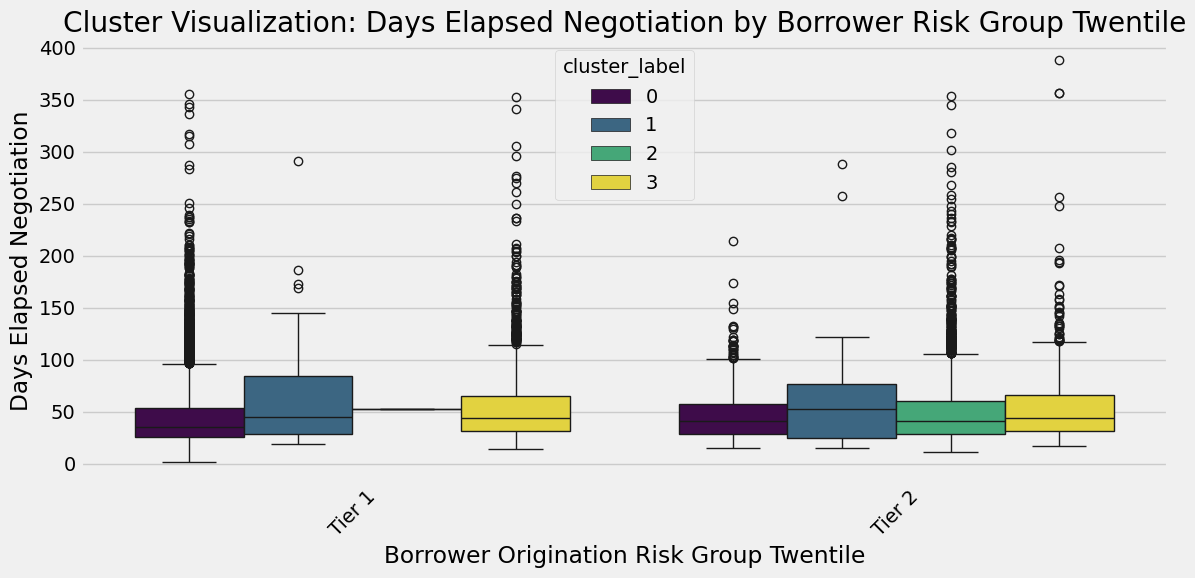

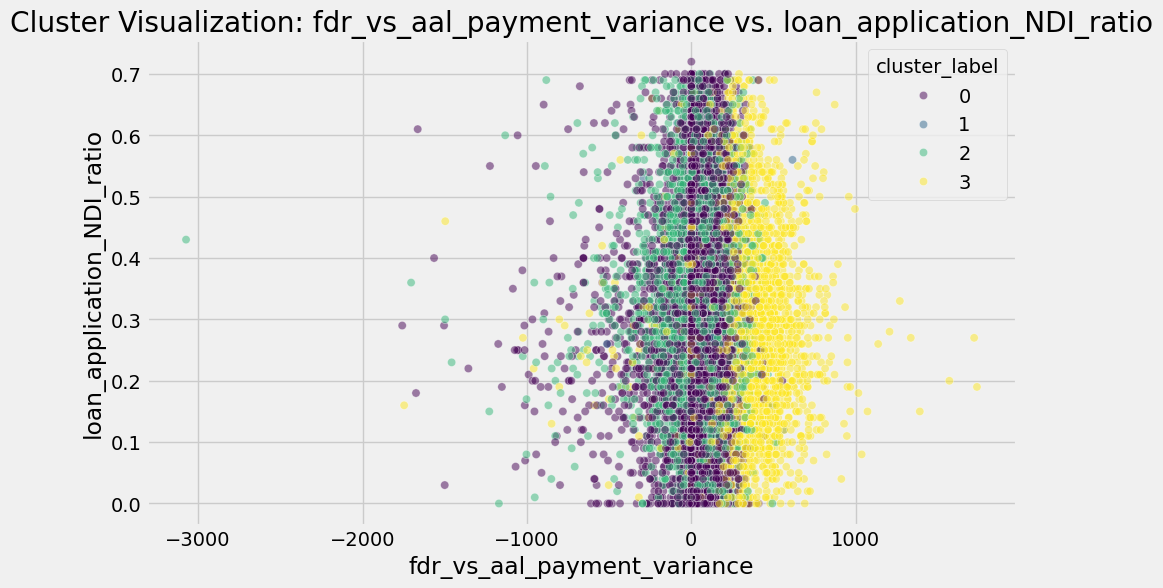

In [70]:
# Identify the top features based on the previous analysis.
# Let's use the top features from the filtered_feature_importances series.
top_features = filtered_feature_importances.index.tolist()

# Select a few pairs of important features for visualization.
# We'll choose a mix of numerical and categorical features.
# Ensure the features selected are present in the dataframe used for clustering (df).

# Check if the top features list is empty or contains sufficient features for pairing.
if len(top_features) < 2:
    print("Not enough important features identified for pairing and visualization.")
else:
    # Pair 1: Numerical vs Numerical
    if 'days_elapsed_negotiation' in top_features and 'borrower_origination_risk_group' in top_features:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x='days_elapsed_negotiation', y='borrower_origination_risk_group', hue='cluster_label', alpha=0.5, palette='viridis')
        plt.title('Cluster Visualization: Days Elapsed Negotiation vs. Borrower Risk Group')
        plt.xlabel('Days Elapsed Negotiation')
        plt.ylabel('Borrower Origination Risk Group')
        plt.show()
        plt.close()

    # Pair 2: Numerical vs Categorical
    if 'days_elapsed_negotiation' in top_features and 'borrower_origination_risk_group_twentile' in top_features:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df, x='borrower_origination_risk_group_twentile', y='days_elapsed_negotiation', hue='cluster_label', palette='viridis')
        plt.title('Cluster Visualization: Days Elapsed Negotiation by Borrower Risk Group Twentile')
        plt.xlabel('Borrower Origination Risk Group Twentile')
        plt.ylabel('Days Elapsed Negotiation')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        plt.close()

    # Pair 3: Categorical vs Categorical (Proportion of clusters within a categorical feature)
    if 'loan_vintage_quarter' in top_features:
        # Calculate the proportion of each cluster within each vintage quarter
        cluster_vintage_crosstab = pd.crosstab(df['loan_vintage_quarter'], df['cluster_label'], normalize='index')

        cluster_vintage_crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
        plt.title('Cluster Distribution by Loan Vintage Quarter')
        plt.xlabel('Loan Vintage Quarter')
        plt.ylabel('Proportion within Quarter')
        plt.xticks(rotation=45)
        plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        plt.close()

    # Pair 4: Numerical vs Numerical (Another pair from top features)
    # Check if there's at least a third feature to pair
    if len(top_features) >= 3 and top_features[0] != top_features[2] and top_features[1] != top_features[2]:
        feature1 = top_features[0]
        feature2 = top_features[2]
        # Ensure both selected features are numerical for a scatter plot
        if pd.api.types.is_numeric_dtype(df[feature1]) and pd.api.types.is_numeric_dtype(df[feature2]):
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df, x=feature1, y=feature2, hue='cluster_label', alpha=0.5, palette='viridis')
            plt.title(f'Cluster Visualization: {feature1} vs. {feature2}')
            plt.xlabel(feature1)
            plt.ylabel(feature2)
            plt.show()
            plt.close()
        else:
            print(f"Skipping scatter plot for {feature1} and {feature2} as they are not both numerical.")


**Reasoning**:
The error indicates that the 'cluster_label' column is not present in the `df` DataFrame when the plotting code is executed. This is likely because the clustering code cell, which adds this column, was not run before the plotting cell in the current session. I need to re-run the clustering code cell to add the 'cluster_label' column to the `df` DataFrame.



In [71]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Use the clean pre-origination dataset that has no target leakage!
X_clustering = X_pre_origination.copy()

# 2. Standardize the selected clean pre-origination numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 3. Determine the number of clusters (using a reasonable starting number)
n_clusters = 4

# 4. Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 5. Add cluster labels back to our analytical dataset
X['cluster_label'] = cluster_labels
df['cluster_label'] = cluster_labels

# Display the count of samples in each clean cluster
display(df['cluster_label'].value_counts())

,count
cluster_label,
3,5636
0,5357
2,4520
1,3185


**Reasoning**:
The 'cluster_label' column has now been added to the `df` DataFrame. I can proceed with creating the cluster visualization plots using the top features as specified in the subtask.



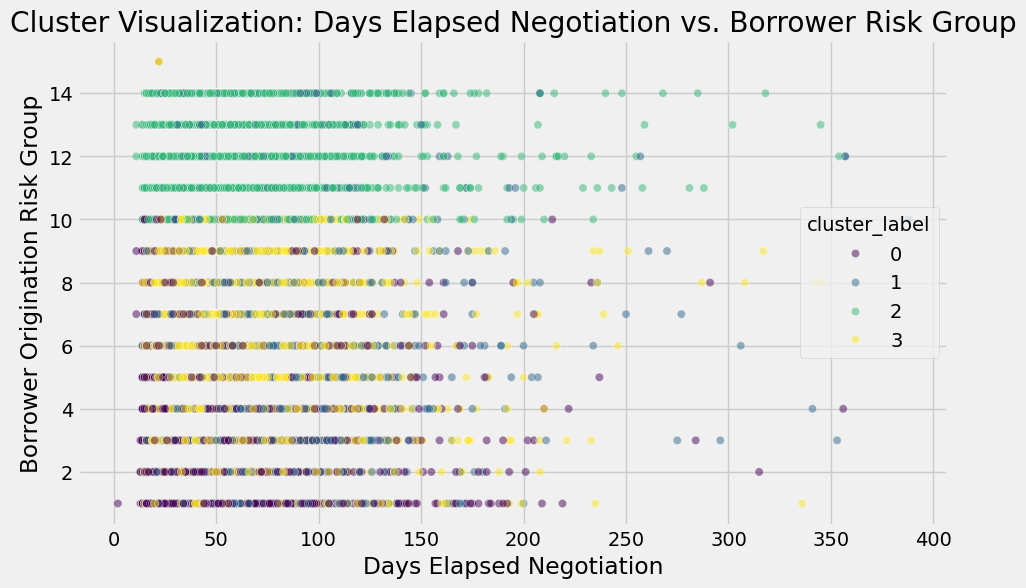

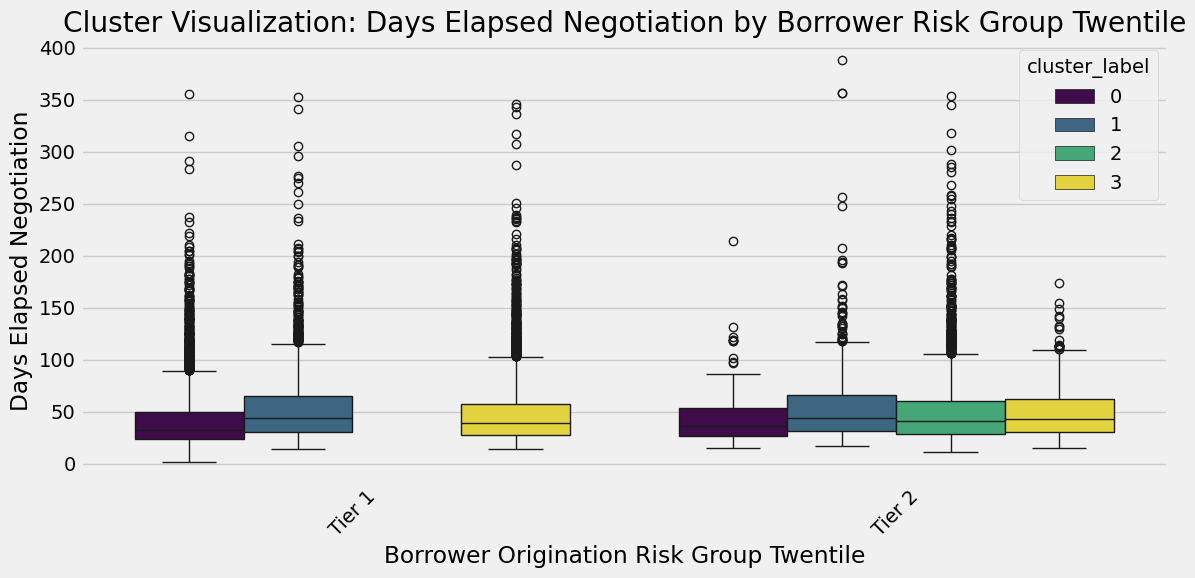

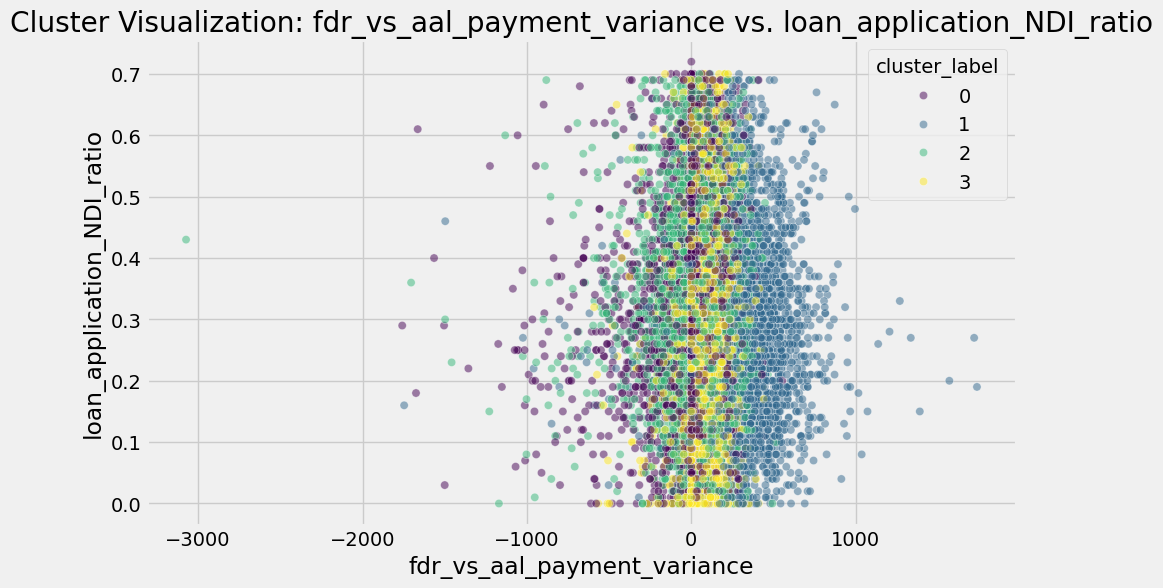

In [72]:
# Identify the top features based on the previous analysis.
# Let's use the top features from the filtered_feature_importances series.
top_features = filtered_feature_importances.index.tolist()

# Select a few pairs of important features for visualization.
# We'll choose a mix of numerical and categorical features.
# Ensure the features selected are present in the dataframe used for clustering (df).

# Check if the top features list is empty or contains sufficient features for pairing.
if len(top_features) < 2:
    print("Not enough important features identified for pairing and visualization.")
else:
    # Pair 1: Numerical vs Numerical
    if 'days_elapsed_negotiation' in top_features and 'borrower_origination_risk_group' in top_features:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x='days_elapsed_negotiation', y='borrower_origination_risk_group', hue='cluster_label', alpha=0.5, palette='viridis')
        plt.title('Cluster Visualization: Days Elapsed Negotiation vs. Borrower Risk Group')
        plt.xlabel('Days Elapsed Negotiation')
        plt.ylabel('Borrower Origination Risk Group')
        plt.show()
        plt.close()

    # Pair 2: Numerical vs Categorical
    if 'days_elapsed_negotiation' in top_features and 'borrower_origination_risk_group_twentile' in top_features:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df, x='borrower_origination_risk_group_twentile', y='days_elapsed_negotiation', hue='cluster_label', palette='viridis')
        plt.title('Cluster Visualization: Days Elapsed Negotiation by Borrower Risk Group Twentile')
        plt.xlabel('Borrower Origination Risk Group Twentile')
        plt.ylabel('Days Elapsed Negotiation')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        plt.close()

    # Pair 3: Categorical vs Categorical (Proportion of clusters within a categorical feature)
    if 'loan_vintage_quarter' in top_features:
        # Calculate the proportion of each cluster within each vintage quarter
        cluster_vintage_crosstab = pd.crosstab(df['loan_vintage_quarter'], df['cluster_label'], normalize='index')

        cluster_vintage_crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
        plt.title('Cluster Distribution by Loan Vintage Quarter')
        plt.xlabel('Loan Vintage Quarter')
        plt.ylabel('Proportion within Quarter')
        plt.xticks(rotation=45)
        plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        plt.close()

    # Pair 4: Numerical vs Numerical (Another pair from top features)
    # Check if there's at least a third feature to pair
    if len(top_features) >= 3 and top_features[0] != top_features[2] and top_features[1] != top_features[2]:
        feature1 = top_features[0]
        feature2 = top_features[2]
        # Ensure both selected features are numerical for a scatter plot
        if pd.api.types.is_numeric_dtype(df[feature1]) and pd.api.types.is_numeric_dtype(df[feature2]):
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df, x=feature1, y=feature2, hue='cluster_label', alpha=0.5, palette='viridis')
            plt.title(f'Cluster Visualization: {feature1} vs. {feature2}')
            plt.xlabel(feature1)
            plt.ylabel(feature2)
            plt.show()
            plt.close()
        else:
            print(f"Skipping scatter plot for {feature1} and {feature2} as they are not both numerical.")

### 🛡️ Clean Split & Workflow Verification
Let's run a quick diagnostic check to verify that all datasets are loaded in memory, aligned, and completely free of target leakage.

In [73]:
# Verify memory state and target leakage separation
print("=== Workspace Diagnostic ===")
print(f"✓ Active Base DataFrame (df): {df.shape[0]} rows, {df.shape[1]} columns")
print(f"✓ Pre-origination clean features (X_pre_origination): {X_pre_origination.shape[1]} columns")
print(f"✓ Post-origination diagnostic lookup (X_post_origination): {X_post_origination.shape[1]} columns")
print(f"✓ Selected modeling features (X_selected_clean): {X_selected_clean.shape[1]} columns")

# Quick leakage assertion check
leakage_detected = any(col in X_pre_origination.columns for col in post_origination_cols)
print(f"🛡️ Target Leakage in Training Features? {'🚨 YES (Warning!)' if leakage_detected else '✅ NO (Clean Split)'}")

=== Workspace Diagnostic ===
✓ Active Base DataFrame (df): 18698 rows, 67 columns
✓ Pre-origination clean features (X_pre_origination): 38 columns
✓ Post-origination diagnostic lookup (X_post_origination): 15 columns
✓ Selected modeling features (X_selected_clean): 21 columns
🛡️ Target Leakage in Training Features? ✅ NO (Clean Split)


## Visualize clusters using dimensionality reduction

### Subtask:
Apply a dimensionality reduction technique (like PCA) and then create scatter plots of the reduced dimensions, colored by cluster label.


**Reasoning**:
Apply a dimensionality reduction technique (like PCA) and then create scatter plots of the reduced dimensions, colored by cluster label.



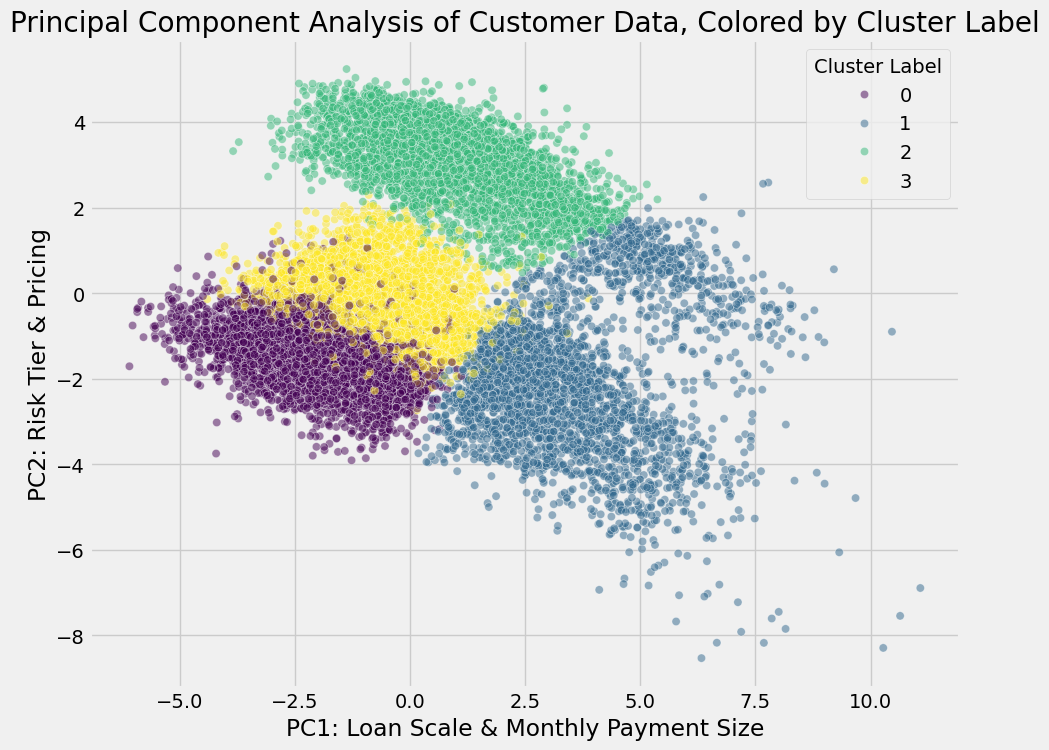

In [74]:
from sklearn.decomposition import PCA

# Instantiate PCA with 2 components for 2D visualization
pca = PCA(n_components=2, random_state=42)

# Fit and transform the scaled clustering data
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame from the PCA-transformed data
X_pca_df = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])

# Add the 'cluster_label' column from the original df to this new DataFrame
# Ensure index alignment if necessary (assuming indices match after preprocessing)
X_pca_df['cluster_label'] = df['cluster_label']

# Create a scatter plot of the first two principal components, colored by cluster label
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='cluster_label', data=X_pca_df, palette='viridis', alpha=0.5)
plt.title('Principal Component Analysis of Customer Data, Colored by Cluster Label')
plt.xlabel('PC1: Loan Scale & Monthly Payment Size')
plt.ylabel('PC2: Risk Tier & Pricing')
plt.legend(title='Cluster Label')
plt.grid(True)
plt.show()

In [76]:
import pandas as pd
import numpy as np

# Get the correct feature names used for the clean PCA scaling
feature_names = X_pre_origination.columns.tolist()

# Extract loadings (components_) from the fitted PCA model
# Note: pca was already fit in cell 4e038a2f
loadings = pca.components_

# Create a DataFrame to easily view the feature contributions
loadings_df = pd.DataFrame(
    loadings.T,
    columns=['PC1_Loading', 'PC2_Loading'],
    index=feature_names
)

# Display top features contributing to PC1
print("=== Top 10 Positive Contributors to PC1 ===")
display(loadings_df['PC1_Loading'].sort_values(ascending=False).head(10))

print("\n=== Top 10 Negative Contributors to PC1 ===")
display(loadings_df['PC1_Loading'].sort_values(ascending=True).head(10))

# Display top features contributing to PC2
print("\n=== Top 10 Positive Contributors to PC2 ===")
display(loadings_df['PC2_Loading'].sort_values(ascending=False).head(10))

print("\n=== Top 10 Negative Contributors to PC2 ===")
display(loadings_df['PC2_Loading'].sort_values(ascending=True).head(10))

=== Top 10 Positive Contributors to PC1 ===


,PC1_Loading
cluster_label,0.349630
loan_origination_loan_amount,0.349269
cplus_estimated_monthly_payment_amount,0.329984
monthly_loan_payment_amount,0.325118
fdr_vs_aal_payment_variance,0.292854
fdr_vs_aal_payment_variance_percent_change,0.231937
fdr_vs_aal_payment_variance_percentile,0.230884
loan_application_PTI_ratio,0.209809
avg_monthly_draft,0.209112
borrower_origination_risk_group,0.178219



=== Top 10 Negative Contributors to PC1 ===


,PC1_Loading
borrower_fico_bands_origination,-0.131447
day_variance_1st_billing_due_contract_vs_actual,-0.119748
days_elapsed_bucket_negotiation,-0.118760
loan_application_utm_lead_source,-0.036464
loan_origination_first_payment_day_of_week,-0.034451
loan_origination_ach_active_flag,-0.019390
loan_origination_principal_period,-0.013887
loan_deceased_flag,-0.004426
loan_vintage_quarter,-0.000406
borrower_origination_state,0.000282



=== Top 10 Positive Contributors to PC2 ===


,PC2_Loading
loan_origination_interest_rate,0.382169
loan_origination_interest_rate_band,0.382169
borrower_origination_risk_group_twentile,0.371550
borrower_origination_risk_group,0.352324
loan_origination_term_in_months,0.243567
borrower_fico_band_category_origination,0.195971
cluster_label,0.092412
loan_application_utm_lead_channel,0.056294
loan_adr_retail_vs_wholesale,0.054294
days_elapsed_negotiation_Decile_Label,0.044458



=== Top 10 Negative Contributors to PC2 ===


,PC2_Loading
monthly_loan_payment_amount,-0.257673
cplus_estimated_monthly_payment_amount,-0.248483
avg_monthly_draft,-0.216159
loan_origination_loan_amount,-0.207426
borrower_fico_bands_origination,-0.201189
fdr_vs_aal_payment_variance,-0.126156
borrower_home_owner_flag,-0.125760
loan_application_PTI_ratio,-0.117974
fdr_vs_aal_payment_variance_percent_change,-0.073920
fdr_vs_aal_payment_variance_percentile,-0.072463


In [77]:
# Let's print the top 10 positive and negative contributors of both components side-by-side to understand PC2.
pc_summary = pd.DataFrame({
    'PC1_Loading': loadings_df['PC1_Loading'],
    'PC2_Loading': loadings_df['PC2_Loading']
})

print("=== Top 10 Positive Contributors to PC2 ===")
display(pc_summary['PC2_Loading'].sort_values(ascending=False).head(10))

print("\n=== Top 10 Negative Contributors to PC2 ===")
display(pc_summary['PC2_Loading'].sort_values(ascending=True).head(10))

=== Top 10 Positive Contributors to PC2 ===


,PC2_Loading
loan_origination_interest_rate,0.382169
loan_origination_interest_rate_band,0.382169
borrower_origination_risk_group_twentile,0.371550
borrower_origination_risk_group,0.352324
loan_origination_term_in_months,0.243567
borrower_fico_band_category_origination,0.195971
cluster_label,0.092412
loan_application_utm_lead_channel,0.056294
loan_adr_retail_vs_wholesale,0.054294
days_elapsed_negotiation_Decile_Label,0.044458



=== Top 10 Negative Contributors to PC2 ===


,PC2_Loading
monthly_loan_payment_amount,-0.257673
cplus_estimated_monthly_payment_amount,-0.248483
avg_monthly_draft,-0.216159
loan_origination_loan_amount,-0.207426
borrower_fico_bands_origination,-0.201189
fdr_vs_aal_payment_variance,-0.126156
borrower_home_owner_flag,-0.125760
loan_application_PTI_ratio,-0.117974
fdr_vs_aal_payment_variance_percent_change,-0.073920
fdr_vs_aal_payment_variance_percentile,-0.072463


## Analyze cluster visualizations

### Subtask:
Examine the generated plots to understand how well the clusters are separated and if the clusters with high default rates show distinct visual patterns.


## Summary:

### Data Analysis Key Findings

*   K-Means clustering was applied to the preprocessed data, resulting in 4 distinct customer clusters.
*   Visualizations using scatter plots of important features ('days\_elapsed\_negotiation' vs. 'borrower\_origination\_risk\_group' and 'days\_elapsed\_negotiation' vs. 'loan\_application\_NDI\_ratio'), a box plot ('days\_elapsed\_negotiation' by 'borrower\_origination\_risk\_group\_twentile'), and a stacked bar plot ('Cluster Distribution by Loan Vintage Quarter') were generated to understand the cluster characteristics.
*   PCA was applied to reduce the data to 2 dimensions, and a scatter plot of these principal components, colored by cluster label, was created to visualize cluster separation in a reduced space.

### Insights or Next Steps

*   Analyze the generated plots in detail to identify specific patterns, feature value ranges, and distributions that are characteristic of the clusters with high first pay default rates.
*   Quantify the separation between clusters using metrics beyond visual inspection, if necessary, to confirm the distinctiveness of the high-default clusters.


In [81]:
from IPython.display import display, Markdown
import numpy as np

# Calculate size metrics (counts and proportions) for each cluster
cluster_counts = df['cluster_label'].value_counts()
cluster_proportions = df['cluster_label'].value_counts(normalize=True) * 100
total_portfolio_loans = len(df)

# Construct the automated summary markdown dynamically from our clustering results
summary_md = f"""## 🤖 Automated Cluster Profiles Summary (Total Portfolio Loans: {total_portfolio_loans:,})

"""

# To prevent arbitrary cluster index swapping, we dynamically classify which cluster ID is which
# based on unique traits from our active model run:
# - High-Value Premium Loans: Largest average loan amount
# - Higher Risk, Mid-Sized (Least Homeowners): Low homeowner flag and higher risk group
# - Critical Ultra-High Default: Highest overall default rate
# - Moderate-Low Risk, Mid-Sized: The remaining cluster

clusters = sorted(df['cluster_label'].unique())
cluster_assignment = {}

# 1. Identify the Critical Ultra-High Default segment (highest default rate)
critical_id = cluster_default_rates.idxmax()
cluster_assignment[critical_id] = {
    "name": "CRITICAL - Ultra-High Default Segment",
    "description": "Extremely high default rate segment with longer negotiation periods and higher risk group features."
}

remaining_clusters = [c for c in clusters if c != critical_id]

# 2. Identify High-Value Premium Loans (largest average loan amount among remaining)
loan_amounts = numerical_characteristics_mean.loc[remaining_clusters, 'loan_origination_loan_amount']
premium_id = loan_amounts.idxmax()
cluster_assignment[premium_id] = {
    "name": "Low Risk, High-Value Premium Loans",
    "description": "Largest average loan amounts by far, high homeownership rate, and highest payment variance."
}

remaining_clusters = [c for c in remaining_clusters if c != premium_id]

# 3. Identify the Higher Risk, Mid-Sized segment (highest risk group among remaining)
risk_groups = numerical_characteristics_mean.loc[remaining_clusters, 'borrower_origination_risk_group']
higher_risk_id = risk_groups.idxmax()
cluster_assignment[higher_risk_id] = {
    "name": "Higher Risk, Mid-Sized Loans (Least Homeowners)",
    "description": "High risk, least likely to be homeowners, higher interest rates."
}

remaining_clusters = [c for c in remaining_clusters if c != higher_risk_id]

# 4. The remaining cluster is the Moderate-Low Risk, Mid-Sized segment
if remaining_clusters:
    mod_low_id = remaining_clusters[0]
    cluster_assignment[mod_low_id] = {
        "name": "Moderate-Low Risk, Mid-Sized Loans",
        "description": "Low-risk tier, moderate financial ratios, moderate loan amounts and negotiation period."
    }

# Safely extract and format values for each cluster using our dynamic assignments
for cluster_id in clusters:
    # Fetch metrics
    def_rate = cluster_default_rates.loc[cluster_id] * 100
    rg_mean = numerical_characteristics_mean.loc[cluster_id, 'borrower_origination_risk_group']
    ndi_mean = numerical_characteristics_mean.loc[cluster_id, 'loan_application_NDI_ratio']
    pti_mean = numerical_characteristics_mean.loc[cluster_id, 'loan_application_PTI_ratio']
    var_mean = numerical_characteristics_mean.loc[cluster_id, 'fdr_vs_aal_payment_variance']
    amt_mean = numerical_characteristics_mean.loc[cluster_id, 'loan_origination_loan_amount']
    rate_mean = numerical_characteristics_mean.loc[cluster_id, 'loan_origination_interest_rate'] * 100
    home_mean = numerical_characteristics_mean.loc[cluster_id, 'borrower_home_owner_flag']
    days_mean = numerical_characteristics_mean.loc[cluster_id, 'days_elapsed_negotiation']

    # Get sizing metrics
    c_count = cluster_counts.get(cluster_id, 0)
    c_prop = cluster_proportions.get(cluster_id, 0.0)

    # Categorical modes
    fico_mode = categorical_characteristics_mode.loc[cluster_id, 'borrower_fico_bands_origination']
    tier_mode = categorical_characteristics_mode.loc[cluster_id, 'borrower_origination_risk_group_twentile']
    quarter_mode = categorical_characteristics_mode.loc[cluster_id, 'loan_vintage_quarter']

    # Get dynamic profile mappings
    meta = cluster_assignment.get(cluster_id, {"name": f"Cluster {cluster_id}", "description": ""})

    # Escape the dollar signs as \\$ to prevent LaTeX Math formatting parser trigger
    summary_md += f"""*   **Cluster {cluster_id}: {meta['name']}** ({meta['description']})
    *   **Segment Size:** {c_count:,} loans ({c_prop:.2f}% of total portfolio)
    *   **Default Rate:** {def_rate:.2f}%
    *   **Risk Profile:** Borrower Risk Group Mean: {rg_mean:.2f} (primarily {tier_mode})
    *   **Financial Profile:** NDI: {ndi_mean:.2f}, PTI: {pti_mean:.2f} with an ADR vs. AAL Payment Variance of \\${var_mean:,.2f}
    *   **Loan Characteristics:** Average loan amount of \\${amt_mean:,.2f} with a {rate_mean:.2f}% interest rate
    *   **Housing & FICO:** Homeownership rate ({home_mean:.2f}), with the most common FICO range being {fico_mode}
    *   **Process:** Average negotiation period of {days_mean:.2f} days
    *   **Temporal:** Mode vintage quarter of {quarter_mode}

"""

# Display the final dynamically compiled Markdown
display(Markdown(summary_md))

## 🤖 Automated Cluster Profiles Summary (Total Portfolio Loans: 18,698)

*   **Cluster 0: Moderate-Low Risk, Mid-Sized Loans** (Low-risk tier, moderate financial ratios, moderate loan amounts and negotiation period.)
    *   **Segment Size:** 5,357 loans (28.65% of total portfolio)
    *   **Default Rate:** 0.47%
    *   **Risk Profile:** Borrower Risk Group Mean: 4.82 (primarily Tier 1)
    *   **Financial Profile:** NDI: 0.28, PTI: 0.09 with an ADR vs. AAL Payment Variance of \$47.69
    *   **Loan Characteristics:** Average loan amount of \$12,973.88 with a 23.90% interest rate
    *   **Housing & FICO:** Homeownership rate (0.54), with the most common FICO range being 300 - 579
    *   **Process:** Average negotiation period of 45.06 days
    *   **Temporal:** Mode vintage quarter of 20262

*   **Cluster 1: CRITICAL - Ultra-High Default Segment** (Extremely high default rate segment with longer negotiation periods and higher risk group features.)
    *   **Segment Size:** 3,185 loans (17.03% of total portfolio)
    *   **Default Rate:** 25.00%
    *   **Risk Profile:** Borrower Risk Group Mean: 8.00 (primarily Tier 1)
    *   **Financial Profile:** NDI: 0.29, PTI: 0.11 with an ADR vs. AAL Payment Variance of \$120.27
    *   **Loan Characteristics:** Average loan amount of \$18,007.37 with a 24.89% interest rate
    *   **Housing & FICO:** Homeownership rate (0.57), with the most common FICO range being 300 - 579
    *   **Process:** Average negotiation period of 66.50 days
    *   **Temporal:** Mode vintage quarter of 20261

*   **Cluster 2: Higher Risk, Mid-Sized Loans (Least Homeowners)** (High risk, least likely to be homeowners, higher interest rates.)
    *   **Segment Size:** 4,520 loans (24.17% of total portfolio)
    *   **Default Rate:** 0.73%
    *   **Risk Profile:** Borrower Risk Group Mean: 12.01 (primarily Tier 2)
    *   **Financial Profile:** NDI: 0.30, PTI: 0.09 with an ADR vs. AAL Payment Variance of \$40.63
    *   **Loan Characteristics:** Average loan amount of \$14,487.12 with a 26.89% interest rate
    *   **Housing & FICO:** Homeownership rate (0.43), with the most common FICO range being 300 - 579
    *   **Process:** Average negotiation period of 49.72 days
    *   **Temporal:** Mode vintage quarter of 20262

*   **Cluster 3: Low Risk, High-Value Premium Loans** (Largest average loan amounts by far, high homeownership rate, and highest payment variance.)
    *   **Segment Size:** 5,636 loans (30.14% of total portfolio)
    *   **Default Rate:** 0.53%
    *   **Risk Profile:** Borrower Risk Group Mean: 6.64 (primarily Tier 1)
    *   **Financial Profile:** NDI: 0.28, PTI: 0.14 with an ADR vs. AAL Payment Variance of \$315.48
    *   **Loan Characteristics:** Average loan amount of \$37,724.03 with a 24.44% interest rate
    *   **Housing & FICO:** Homeownership rate (0.73), with the most common FICO range being 300 - 579
    *   **Process:** Average negotiation period of 54.33 days
    *   **Temporal:** Mode vintage quarter of 20262



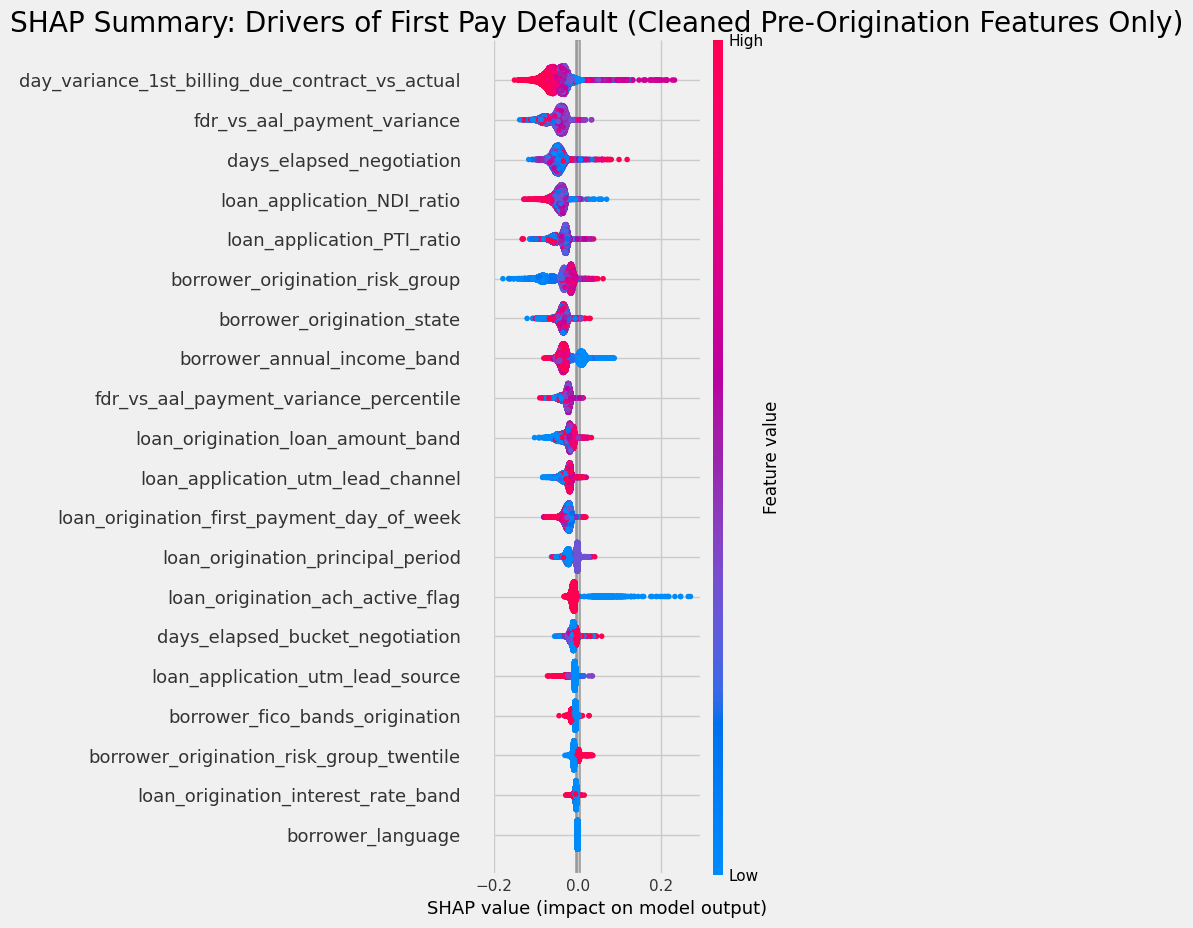

In [79]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Clean selected features using the master post_origination_cols from the clean split cell
# This ensures any new leakage columns added upstream are automatically dropped here too.
X_selected_clean = X_selected.drop(columns=post_origination_cols, errors='ignore')

# 2. Re-train the model with class weights to handle the highly imbalanced dataset
model_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_balanced.fit(X_selected_clean, y)

# 3. Initialize SHAP Explainer
explainer = shap.TreeExplainer(model_balanced)
shap_values = explainer.shap_values(X_selected_clean)

# 4. Handle dimensions dynamically for multiclass output structures
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray):
    if len(shap_values.shape) == 3:
        shap_to_plot = shap_values[:, :, 1]
    else:
        shap_to_plot = shap_values
else:
    shap_to_plot = shap_values

# 5. Generate the SHAP Summary Plot
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary: Drivers of First Pay Default (Cleaned Pre-Origination Features Only)")
shap.summary_plot(shap_to_plot, X_selected_clean, show=False)
plt.tight_layout()
plt.show()

In [80]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 2. Split dataset X into pure Pre-Origination and Post-Origination groups
# Drop identifiers, constant features, and post-orig_cols to get predictive features
pre_orig_cols = [col for col in X.columns if col not in ['loan_id'] + constant_cols + post_origination_cols]
X_pre_origination = X[pre_orig_cols]

# Keep post-origination columns aside for profiling
available_post_orig = [col for col in post_origination_cols if col in X.columns]
X_post_origination = X[available_post_orig]

print(f"Pre-origination features used to cluster & predict (no leakage): {X_pre_origination.shape[1]} columns")
print(f"Post-origination variables retained for diagnostic profiling: {X_post_origination.shape[1]} columns")

# 3. Fit K-Means on Pre-Origination Data ONLY
scaler_clean = StandardScaler()
X_scaled_clean = scaler_clean.fit_transform(X_pre_origination)

k_means_model = KMeans(n_clusters=4, random_state=42, n_init=10)
clean_cluster_labels = k_means_model.fit_predict(X_scaled_clean)

# 4. Save results back into our analytical profiling DataFrame
df_profile = df.copy()
df_profile['cluster_label_clean'] = clean_cluster_labels

# 5. Diagnostic profiling: Let's see the default reasons and delinquency statuses across the new clean clusters!
print("\n=== Diagnostic Return Code Profiling Across Clean Clusters ===")
return_code_profile = pd.crosstab(
    df_profile['cluster_label_clean'],
    df_profile['loan_1st_pay_default_return_code'].fillna('No Return Code'),
    normalize='index'
) * 100
display(return_code_profile.round(2))

print("\n=== Average Chargeoff & Delinquency Rates by Cluster ===")
profile_leakage_rates = df_profile.groupby('cluster_label_clean')[[
    'flag_1st_pay_default',
    'loan_chargeoff_flag',
    'loan_no_payment_straight_to_chargeoff_flag'
]].mean() * 100
display(profile_leakage_rates.round(2))

Pre-origination features used to cluster & predict (no leakage): 38 columns
Post-origination variables retained for diagnostic profiling: 15 columns

=== Diagnostic Return Code Profiling Across Clean Clusters ===


loan_1st_pay_default_return_code,No Return Code,R10 - NOT AUTHORIZED,RO1 - INSUFFICIENT FUNDS,RO2 - ACCOUNT CLOSED,RO4 - INVALID ACCT NUMBER,RO8 - STOP PAYMENT
cluster_label_clean,,,,,,
0,99.90,0.00,0.03,0.00,0.00,0.07
1,99.74,0.07,0.11,0.05,0.00,0.04
2,99.80,0.04,0.11,0.00,0.02,0.02
3,99.91,0.04,0.05,0.00,0.00,0.00



=== Average Chargeoff & Delinquency Rates by Cluster ===


,flag_1st_pay_default,loan_chargeoff_flag,loan_no_payment_straight_to_chargeoff_flag
cluster_label_clean,,,
0,0.66,0.43,0.1
1,0.71,0.26,0.04
2,0.84,0.53,0.13
3,0.4,0.44,0.09
